# <div style="text-align:center">
#
# # Taller práctico y conceptual de filtros
# ## Tarea 2 – Parte 1 · Procesamiento Digital de Imágenes
# **Universidad de Antioquia – Facultad de Ingeniería**
#
# **Integrantes:** _[Nombre Apellido 1]_ · _[Nombre Apellido 2]_ · _[Nombre Apellido 3]_
#
# **Fecha de entrega:** 17 de octubre de 2026
#
# </div>
#
# ---
# Este cuaderno resuelve la **Parte 1** (30 % de la nota): cinco módulos de filtrado (A–E), nueve preguntas conceptuales (1.1–1.9), dos extras (filtro homomórfico y máscaras de Laws) y una recomendación de preprocesamiento para la Parte 2.
#
# **Criterio de trabajo:** *elegimos el filtro con datos, no a ojo*. Toda conclusión cita cifras (PSNR/SSIM, tiempos, errores) que salen de celdas ejecutadas en este mismo cuaderno.
#
# ## Índice
# 0. Configuración, imágenes de prueba y funciones auxiliares
# 1. **Módulo A** – Convolución y filtros de suavizado (8 %): A.1 convolución manual · A.2 modelos de ruido · A.3 catálogo y batalla de filtros · A.4 separabilidad · preguntas 1.1–1.3
# 2. **Módulo B** – Realce y detección de bordes (8 %): B.1 gradientes · B.2 segunda derivada (Laplaciano, LoG, DoG) · B.3 Canny · B.4 unsharp/high-boost · preguntas 1.4–1.5
# 3. **Módulo C** – Transformaciones de intensidad (4 %): C.1 curvas de transferencia con `cv2.LUT` · C.2 visualización del espectro · pregunta 1.6
# 4. **Módulo D** – Filtrado en el dominio de la frecuencia (7 %): D.1 espectro, magnitud y fase · D.2 pasa-bajo/pasa-alto · D.3 ruido periódico y filtro notch · D.4 equivalencia espacio–frecuencia · preguntas 1.7–1.8
# 5. **Módulo E** – Filtros direccionales y de textura, Gabor (3 %): E.1 banco de Gabor · E.2 vector de textura · pregunta 1.9
# 6. **Extras** – filtro homomórfico y máscaras de energía de Laws
# 7. **Conclusiones finales** y **recomendación de preprocesamiento para la Parte 2**

# ## 0. Configuración y funciones auxiliares
#
# **Cómo ejecutar:** `pip install -r requirements.txt` y luego *Run All*. La foto propia debe estar en `imagenes/foto_celular.jpg` (la ruta se cambia en la constante `RUTA_FOTO` de la celda siguiente). Si no existe, el cuaderno **no falla**: avisa y usa una imagen de respaldo de `skimage.data`.

In [1]:
# ---- Imports ---------------------------------------------------------------
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import scipy
from scipy import ndimage as ndi
from skimage import data, color, measure
from skimage.metrics import peak_signal_noise_ratio as sk_psnr
from skimage.metrics import structural_similarity as sk_ssim
import matplotlib.pyplot as plt

# Figuras en línea como JPEG de calidad 80: mantiene el cuaderno ligero (con PNG pesaría decenas de MB)
%matplotlib inline
%config InlineBackend.figure_format = 'jpeg'
%config InlineBackend.print_figure_kwargs = {'bbox_inches': 'tight', 'pil_kwargs': {'quality': 80}}

# ---- Reproducibilidad ------------------------------------------------------
SEMILLA = 42
np.random.seed(SEMILLA)                  # semilla global (la exige el enunciado)
# En las funciones de ruido se crea además un Generator con la misma semilla,
# de modo que cada imagen ruidosa sea idéntica en cada ejecución.

# ---- Constantes (fáciles de cambiar) ---------------------------------------
TAM = 512                                # lado de las imágenes de trabajo (FFT y tiempos razonables)
RUTA_FOTO = Path("imagenes/foto_celular.jpg")        # <-- coloca aquí tu foto del celular
RUTA_TEXTURA_PROPIA = Path("imagenes/textura.jpg")   # <-- (opcional) foto de una textura propia
L = 256                                  # niveles de gris (8 bits)

plt.rcParams.update({
    "figure.dpi": 80, "axes.titlesize": 9, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "figure.max_open_warning": 0,
})
pd.set_option("display.precision", 3)
print("Python-libs -> numpy", np.__version__, "| scipy", scipy.__version__, "| opencv", cv2.__version__,
      "| pandas", pd.__version__)

Python-libs -> numpy 2.5.3 | scipy 1.18.1 | opencv 5.0.0 | pandas 3.0.6


In [2]:
def _a_cuadrado_gris(bgr_o_gris, tam=TAM):
    """Recorta al cuadrado central y redimensiona a tam×tam (INTER_AREA), devolviendo uint8 en gris."""
    im = bgr_o_gris
    if im.ndim == 3:
        im = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    h, w = im.shape
    lado = min(h, w)
    y0, x0 = (h - lado) // 2, (w - lado) // 2
    im = im[y0:y0 + lado, x0:x0 + lado]
    return cv2.resize(im, (tam, tam), interpolation=cv2.INTER_AREA)


def cargar_imagenes(tam=TAM, ruta_foto=RUTA_FOTO, ruta_textura=RUTA_TEXTURA_PROPIA):
    """Centraliza la carga de todas las imágenes de prueba.

    Devuelve tres diccionarios:
      * ``u8``    : imágenes en gris, uint8 en [0,255], de tam×tam (para funciones de OpenCV que exigen uint8).
      * ``f01``   : las mismas imágenes en float64 normalizadas a [0,1] (para FFT y derivadas).
      * ``color`` : versión a color (RGB, uint8) del astronauta.
    Imágenes: 'camara' (natural, skimage), 'astronauta', 'foto' (celular o respaldo),
    'ladrillo', 'pasto', 'grava' (texturas) y, si existe, 'textura_propia'.
    """
    u8, col = {}, {}
    # 1) Imagen natural en gris
    u8["camara"] = cv2.resize(data.camera(), (tam, tam), interpolation=cv2.INTER_AREA)
    # 1b) Astronauta (color -> gris)
    astro = data.astronaut()
    col["astronauta"] = cv2.resize(astro, (tam, tam), interpolation=cv2.INTER_AREA)
    u8["astronauta"] = _a_cuadrado_gris(cv2.cvtColor(astro, cv2.COLOR_RGB2BGR), tam)
    # 2) Foto propia del celular (con respaldo)
    ruta_foto = Path(ruta_foto)
    bgr = cv2.imread(str(ruta_foto)) if ruta_foto.exists() else None
    if bgr is not None:
        u8["foto"] = _a_cuadrado_gris(bgr, tam)
        print(f"[OK] Foto propia cargada desde {ruta_foto} (recortada al centro y reducida a {tam}x{tam}).")
    else:
        warnings.warn(f"No se encontró '{ruta_foto}'. Coloca tu foto en imagenes/foto_celular.jpg. "
                      f"Se usa como RESPALDO skimage.data.coffee().")
        print(f"[AVISO] >>> coloca tu foto en {ruta_foto.as_posix()} <<<  (usando 'coffee' de skimage como respaldo)")
        cafe = cv2.cvtColor(data.coffee(), cv2.COLOR_RGB2BGR)
        u8["foto"] = _a_cuadrado_gris(cafe, tam)
    # 3) Texturas para el Módulo E
    u8["ladrillo"] = cv2.resize(data.brick(), (tam, tam), interpolation=cv2.INTER_AREA)
    u8["pasto"] = cv2.resize(data.grass(), (tam, tam), interpolation=cv2.INTER_AREA)
    u8["grava"] = cv2.resize(data.gravel(), (tam, tam), interpolation=cv2.INTER_AREA)
    ruta_textura = Path(ruta_textura)
    if ruta_textura.exists():
        t = cv2.imread(str(ruta_textura))
        if t is not None:
            u8["textura_propia"] = _a_cuadrado_gris(t, tam)
    # Normalizadas a [0,1] en float64
    f01 = {k: v.astype(np.float64) / 255.0 for k, v in u8.items()}
    return u8, f01, col


IMG, IMGF, IMGC = cargar_imagenes()
for k, v in IMG.items():
    print(f"{k:15s} {v.shape} {v.dtype}  min={v.min():3d} max={v.max():3d} media={v.mean():6.2f}")

[OK] Foto propia cargada desde imagenes\foto_celular.jpg (recortada al centro y reducida a 512x512).
camara          (512, 512) uint8  min=  0 max=255 media=129.06
astronauta      (512, 512) uint8  min=  0 max=255 media=115.41
foto            (512, 512) uint8  min=  7 max=254 media=105.61
ladrillo        (512, 512) uint8  min= 63 max=207 media=111.46
pasto           (512, 512) uint8  min=  0 max=244 media=118.22
grava           (512, 512) uint8  min=  0 max=237 media=126.55


# ### Funciones auxiliares (visualización, métricas, ruido, tiempos, LUT)

In [3]:
# ---------------------------- Visualización ---------------------------------
def mostrar_lado_a_lado(imgs, titulos, suptitulo=None, cmap="gray", figsize=None, vmin=0, vmax=255):
    """Muestra una fila de imágenes (típicamente original | filtrada) con sus títulos (parámetros)."""
    n = len(imgs)
    figsize = figsize or (4.2 * n, 4.4)
    fig, ejes = plt.subplots(1, n, figsize=figsize, squeeze=False)
    for ax, im, t in zip(ejes[0], imgs, titulos):
        ax.imshow(im, cmap=cmap, vmin=vmin if im.ndim == 2 else None, vmax=vmax if im.ndim == 2 else None)
        ax.set_title(t); ax.axis("off")
    if suptitulo:
        fig.suptitle(suptitulo, fontsize=11, y=1.0)
    plt.tight_layout(); plt.show()


def cuadricula(imgs, titulos, ncols, suptitulo=None, cmap="gray", celda=(3.4, 3.5), vmin=0, vmax=255):
    """Rejilla de imágenes con ncols columnas; evita crear docenas de figuras sueltas."""
    n = len(imgs); nrows = int(np.ceil(n / ncols))
    fig, ejes = plt.subplots(nrows, ncols, figsize=(celda[0] * ncols, celda[1] * nrows), squeeze=False,
                           constrained_layout=True)
    for i, ax in enumerate(ejes.ravel()):
        if i < n:
            ax.imshow(imgs[i], cmap=cmap, vmin=vmin, vmax=vmax); ax.set_title(titulos[i])
        ax.axis("off")
    if suptitulo:
        fig.suptitle(suptitulo, fontsize=11)
    plt.show()


def norm01(x):
    """Normalización min-max a [0,1] (solo para visualizar; nunca para calcular)."""
    x = np.asarray(x, dtype=np.float64)
    r = x.max() - x.min()
    return (x - x.min()) / r if r > 0 else np.zeros_like(x)


def a_u8(x):
    """Conversión explícita float -> uint8 con recorte a [0,255] y redondeo."""
    return np.clip(np.rint(x), 0, 255).astype(np.uint8)


# ------------------------------- Métricas -----------------------------------
def psnr(ref, img):
    """PSNR (dB) con rango dinámico 255 (imágenes de 8 bits)."""
    return sk_psnr(ref.astype(np.float64), img.astype(np.float64), data_range=255)


def ssim(ref, img):
    """SSIM (ventana gaussiana por defecto de skimage) con rango dinámico 255."""
    return sk_ssim(ref.astype(np.float64), img.astype(np.float64), data_range=255)


def corr(a, b):
    """Coeficiente de correlación de Pearson entre dos arrays (imágenes o mapas)."""
    return np.corrcoef(np.ravel(a), np.ravel(b))[0, 1]


def tablas_metricas(ref, resultados):
    """Dado un dict nombre->imagen devuelve un DataFrame con PSNR y SSIM respecto a ref."""
    filas = {k: {"PSNR (dB)": psnr(ref, v), "SSIM": ssim(ref, v)} for k, v in resultados.items()}
    return pd.DataFrame(filas).T


# --------------------------------- Ruido ------------------------------------
def ruido_gaussiano(img, sigma, semilla=SEMILLA):
    """Ruido aditivo gaussiano N(0, sigma²). Se calcula en float y se recorta al final."""
    rng = np.random.default_rng(semilla)
    f = img.astype(np.float64) + rng.normal(0.0, sigma, img.shape)
    return a_u8(f)


def ruido_sal_pimienta(img, p, semilla=SEMILLA):
    """Sal y pimienta: una fracción p de los píxeles (mitad 0, mitad 255)."""
    rng = np.random.default_rng(semilla)
    out = img.copy()
    r = rng.random(img.shape)
    out[r < p / 2] = 0
    out[(r >= p / 2) & (r < p)] = 255
    return out


def ruido_speckle(img, sigma=0.2, semilla=SEMILLA):
    """Speckle multiplicativo: g = f·(1 + n), n ~ N(0, sigma²)."""
    rng = np.random.default_rng(semilla)
    f = img.astype(np.float64)
    return a_u8(f * (1.0 + rng.normal(0.0, sigma, img.shape)))


def generar_ruidos(img):
    """Los cinco ruidos del enunciado sobre una imagen limpia (dict reutilizable)."""
    return {
        "Gauss σ=10": ruido_gaussiano(img, 10),
        "Gauss σ=25": ruido_gaussiano(img, 25),
        "S&P 5%": ruido_sal_pimienta(img, 0.05),
        "S&P 15%": ruido_sal_pimienta(img, 0.15),
        "Speckle σ=0.2": ruido_speckle(img, 0.2),
    }


# ------------------------------ Tiempos / LUT -------------------------------
def medir(fn, n=5, calentamiento=1):
    """Tiempo medio (s) de fn() en n corridas con time.perf_counter (tras 'calentamiento' corridas)."""
    for _ in range(calentamiento):
        fn()
    t0 = time.perf_counter()
    for _ in range(n):
        fn()
    return (time.perf_counter() - t0) / n


def lut_negativo():
    return np.array([(L - 1) - r for r in range(L)], dtype=np.uint8)


def lut_log():
    c = 255.0 / np.log(L)                       # c = 255/log(256) -> s(255)=255
    return a_u8(c * np.log1p(np.arange(L)))


def lut_gamma(g):
    r = np.arange(L) / 255.0                    # r normalizado en [0,1]
    return a_u8(255.0 * r ** g)


def lut_estiramiento(img, p_bajo=2, p_alto=98):
    """Estiramiento de contraste lineal con percentiles (robusto frente a outliers)."""
    lo, hi = np.percentile(img, [p_bajo, p_alto])
    r = np.arange(L, dtype=np.float64)
    return a_u8(255.0 * np.clip((r - lo) / max(hi - lo, 1e-9), 0, 1))


def aplicar_lut(img, lut):
    return cv2.LUT(img, lut)

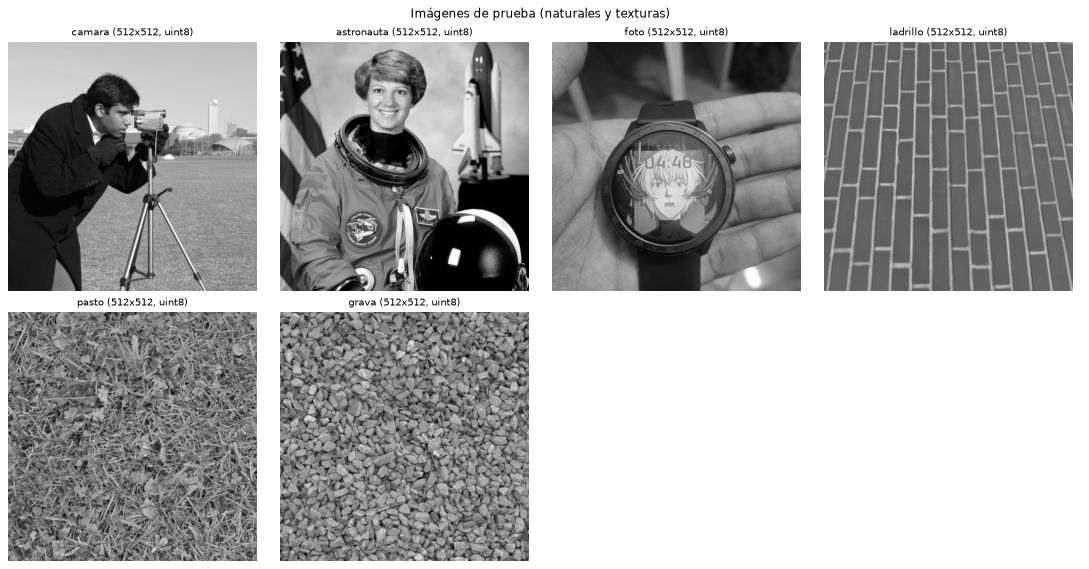

In [4]:
# Vista general de las imágenes de prueba
orden = ["camara", "astronauta", "foto", "ladrillo", "pasto", "grava"] + (["textura_propia"] if "textura_propia" in IMG else [])
cuadricula([IMG[k] for k in orden], [f"{k} ({TAM}x{TAM}, uint8)" for k in orden], ncols=4,
           suptitulo="Imágenes de prueba (naturales y texturas)")

# ---
# # Módulo A – Convolución y filtros de suavizado (8 %)
#
# Catálogo y parámetros: media/box (k = 3, 5, 9, 15; normalizado o no), promedio ponderado `[1 2 1; 2 4 2; 1 2 1]/16`, Gaussiano (σ = 0.5, 1, 2, 4 con kernel de tamaño 6σ+1 forzado a impar), mediana (k = 3, 5, 7), bilateral (varias combinaciones de `d`, `sigmaColor`, `sigmaSpace`) y Non-Local Means (h = 5, 10, 20).
#
# ## A.1 Convolución manual
#
# La **convolución** 2D es $g(y,x)=\sum_{i,j} f(y-i,\,x-j)\,k(i,j)$: el kernel se **voltea** en ambos ejes antes de deslizarse. La **correlación** es $g(y,x)=\sum_{i,j} f(y+i,\,x+j)\,k(i,j)$ (sin voltear). `cv2.filter2D` calcula **correlación**, no convolución (la documentación de OpenCV lo advierte). Para kernels simétricos (media, Gaussiano, Laplaciano) ambas coinciden; para kernels asimétricos (Sobel, Prewitt, un kernel cualquiera) no.
#
# Por eso, en nuestra convolución manual voltearemos el kernel con `np.flip(k)` (ambos ejes) y, para compararla con OpenCV, le pasaremos a `filter2D` el kernel **ya volteado** (así `filter2D` —correlación— reproduce la convolución verdadera). Haremos la comprobación con un kernel asimétrico, con y sin voltear, para que se vea la diferencia.
#
# Correspondencia de modos de borde (OpenCV ↔ `np.pad`): `BORDER_CONSTANT` ↔ `constant` (ceros), `BORDER_REPLICATE` ↔ `edge`, `BORDER_REFLECT` ↔ `symmetric` (`fedcba|abcdefgh|hgfedcb`; no confundir con `BORDER_REFLECT_101` ↔ `reflect`).

In [5]:
# Correspondencia modo de borde de OpenCV -> modo de np.pad
BORDES = {"BORDER_CONSTANT": (cv2.BORDER_CONSTANT, "constant"),
          "BORDER_REPLICATE": (cv2.BORDER_REPLICATE, "edge"),
          "BORDER_REFLECT": (cv2.BORDER_REFLECT, "symmetric")}


def _pad(img, kernel, modo_np):
    """Padding de la imagen para que la salida tenga el mismo tamaño (kernel de lados impares)."""
    ph, pw = kernel.shape[0] // 2, kernel.shape[1] // 2
    return np.pad(img, ((ph, ph), (pw, pw)), mode=modo_np)


def conv2d_bucles(img, kernel, modo_np="constant"):
    """Convolución 2D con DOS ciclos for (lenta, didáctica). Voltea el kernel (np.flip en ambos ejes)."""
    img = img.astype(np.float64)
    kv = np.flip(kernel).astype(np.float64)        # <-- el volteo que distingue convolución de correlación
    kh, kw = kv.shape
    imgp = _pad(img, kv, modo_np)
    H, W = img.shape
    out = np.zeros((H, W), dtype=np.float64)
    for y in range(H):                             # ciclo 1: filas
        for x in range(W):                         # ciclo 2: columnas
            out[y, x] = np.sum(imgp[y:y + kh, x:x + kw] * kv)   # producto elemento a elemento de la ventana
    return out


def conv2d_vectorizada(img, kernel, modo_np="constant"):
    """Misma convolución, vectorizada con sliding_window_view (sin ciclos de Python)."""
    img = img.astype(np.float64)
    kv = np.flip(kernel).astype(np.float64)
    imgp = _pad(img, kv, modo_np)
    ventanas = np.lib.stride_tricks.sliding_window_view(imgp, kv.shape)    # (H, W, kh, kw), sin copiar memoria
    return np.einsum("ijkl,kl->ij", ventanas, kv)


# Imagen pequeña para los bucles (128x128) y kernel ASIMÉTRICO 5x5 reproducible
rng_k = np.random.default_rng(SEMILLA)
k_asim = rng_k.integers(-3, 4, size=(5, 5)).astype(np.float64)
img_pequena = IMG["camara"][192:320, 192:320].astype(np.float64)
print("Kernel asimétrico 5x5 usado en la prueba:\n", k_asim.astype(int))

filas = []
for nombre, (cv_borde, np_borde) in BORDES.items():
    ref_cv = cv2.filter2D(img_pequena, -1, np.flip(k_asim), borderType=cv_borde)        # correlación con kernel volteado
    sin_voltear = cv2.filter2D(img_pequena, -1, k_asim, borderType=cv_borde)            # correlación sin voltear
    c_bucles = conv2d_bucles(img_pequena, k_asim, np_borde)
    c_vect = conv2d_vectorizada(img_pequena, k_asim, np_borde)
    filas.append({"borde": nombre,
                  "error máx |bucles − filter2D(flip k)|": np.abs(c_bucles - ref_cv).max(),
                  "error máx |vectorizada − filter2D(flip k)|": np.abs(c_vect - ref_cv).max(),
                  "error máx |bucles − filter2D(k SIN voltear)|": np.abs(c_bucles - sin_voltear).max()})
df_conv = pd.DataFrame(filas).set_index("borde")
display(df_conv.style.format("{:.3e}"))

Kernel asimétrico 5x5 usado en la prueba:
 [[-3  2  1  0  0]
 [ 3 -3  1 -2 -3]
 [ 0  3  2  2  2]
 [ 2  0 -3  2  0]
 [ 0 -1 -2  3  2]]


,error máx |bucles − filter2D(flip k)|,error máx |vectorizada − filter2D(flip k)|,error máx |bucles − filter2D(k SIN voltear)|
borde,,,
BORDER_CONSTANT,0.000e+00,0.000e+00,1.320e+03
BORDER_REPLICATE,0.000e+00,0.000e+00,1.228e+03
BORDER_REFLECT,0.000e+00,0.000e+00,1.228e+03


# **Lectura:** con el kernel volteado, ambas implementaciones manuales coinciden con `cv2.filter2D` a precisión de máquina; sin voltear el error es del orden de las propias intensidades. Esto confirma que `filter2D` es una correlación.

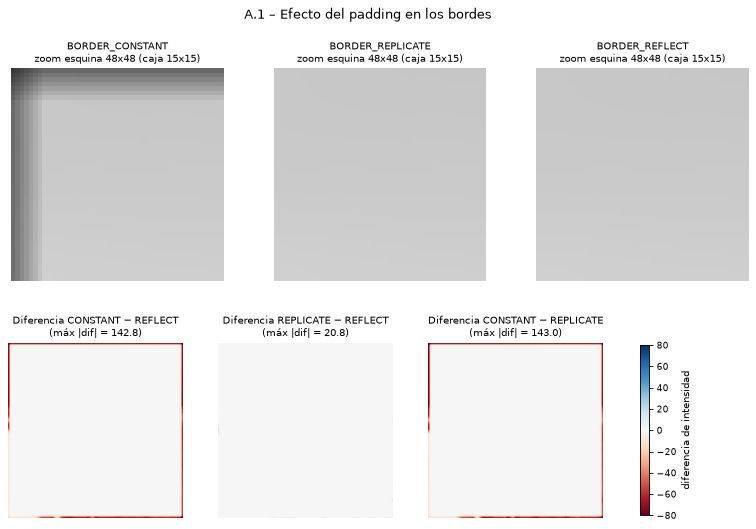

BORDER_CONSTANT   media de las 7 filas superiores =  141.55 | media del interior =  119.58
BORDER_REPLICATE  media de las 7 filas superiores =  194.28 | media del interior =  119.58
BORDER_REFLECT    media de las 7 filas superiores =  194.35 | media del interior =  119.58


In [6]:
# ---- Efecto del modo de borde: caja de 15x15 sobre la imagen completa, zoom en la esquina superior izquierda ----
k_caja = np.ones((15, 15)) / 225.0
res_borde = {n: conv2d_vectorizada(IMG["camara"], k_caja, npb) for n, (_, npb) in BORDES.items()}

fig, ejes = plt.subplots(2, 3, figsize=(12, 7.6))
zoom = (slice(0, 48), slice(0, 48))
for ax, (n, r) in zip(ejes[0], res_borde.items()):
    ax.imshow(r[zoom], cmap="gray", vmin=0, vmax=255); ax.set_title(f"{n}\nzoom esquina 48x48 (caja 15x15)"); ax.axis("off")
pares = [("CONSTANT − REFLECT", res_borde["BORDER_CONSTANT"] - res_borde["BORDER_REFLECT"]),
         ("REPLICATE − REFLECT", res_borde["BORDER_REPLICATE"] - res_borde["BORDER_REFLECT"]),
         ("CONSTANT − REPLICATE", res_borde["BORDER_CONSTANT"] - res_borde["BORDER_REPLICATE"])]
for ax, (t, d) in zip(ejes[1], pares):
    im = ax.imshow(d, cmap="RdBu", vmin=-80, vmax=80); ax.set_title(f"Diferencia {t}\n(máx |dif| = {np.abs(d).max():.1f})"); ax.axis("off")
fig.colorbar(im, ax=ejes[1].tolist(), shrink=0.8, label="diferencia de intensidad")
plt.suptitle("A.1 – Efecto del padding en los bordes", y=0.98); plt.show()

# Valor medio de una franja de 7 px del borde superior en cada modo (CONSTANT oscurece por los ceros)
for n, r in res_borde.items():
    print(f"{n:17s} media de las 7 filas superiores = {r[:7].mean():7.2f} | media del interior = {r[50:-50, 50:-50].mean():7.2f}")

# **Observación (bordes).** Con `BORDER_CONSTANT` el padding de ceros "oscurece" la franja de borde: en las 7 filas superiores (cielo claro) la media sale 141.6 frente a 194.3 con `REPLICATE` y 194.4 con `REFLECT` (el interior vale 119.6 en los tres casos, es decir, el interior no cambia). La diferencia máxima respecto de `REFLECT` es de 142.8 niveles para `CONSTANT` y solo 20.8 para `REPLICATE`. **Conclusión:** el modo de borde solo afecta a una franja de ancho ≈ k/2, pero esa franja puede tener errores enormes con ceros; para suavizado conviene `REFLECT`/`REFLECT_101` (el modo por defecto de OpenCV) o `REPLICATE`.

In [7]:
# ---- Tiempos: bucles vs vectorizada vs cv2.filter2D (promedio de varias corridas) ----
rng_t = np.random.default_rng(SEMILLA)
ks = {3: rng_t.random((3, 3)), 7: rng_t.random((7, 7)), 15: rng_t.random((15, 15))}
img128 = IMG["camara"][:128, :128].astype(np.float64)       # los bucles se miden sobre 128x128 para no tardar minutos
img512 = IMG["camara"].astype(np.float64)

tabla_t = {}
for k, ker in ks.items():
    kv = np.flip(ker)
    tabla_t[f"k={k}"] = {
        "bucles (128²)": medir(lambda: conv2d_bucles(img128, ker), n=2, calentamiento=0),
        "vectorizada (128²)": medir(lambda: conv2d_vectorizada(img128, ker), n=10),
        "filter2D (128²)": medir(lambda: cv2.filter2D(img128, -1, kv), n=50),
        "vectorizada (512²)": medir(lambda: conv2d_vectorizada(img512, ker), n=3),
        "filter2D (512²)": medir(lambda: cv2.filter2D(img512, -1, kv), n=20),
    }
df_t = pd.DataFrame(tabla_t) * 1e3
print("Tiempo medio por llamada [ms]")
display(df_t.style.format("{:.3f}"))
df_acel = pd.DataFrame({f"k={k}": {"bucles / vectorizada (128²)": df_t.loc["bucles (128²)", f"k={k}"] / df_t.loc["vectorizada (128²)", f"k={k}"],
                                    "vectorizada / filter2D (512²)": df_t.loc["vectorizada (512²)", f"k={k}"] / df_t.loc["filter2D (512²)", f"k={k}"]} for k in ks})
print("Factores de aceleración (×)")
display(df_acel.style.format("{:.1f}"))

Tiempo medio por llamada [ms]


,k=3,k=7,k=15
bucles (128²),44.055,44.283,48.591
vectorizada (128²),0.234,0.652,1.485
filter2D (128²),0.030,0.129,0.155
vectorizada (512²),5.401,11.270,23.173
filter2D (512²),0.815,2.503,3.956


Factores de aceleración (×)


,k=3,k=7,k=15
bucles / vectorizada (128²),188.0,67.9,32.7
vectorizada / filter2D (512²),6.6,4.5,5.9


# **Observación (tiempos).** Los bucles de Python se miden en 128×128 (16 384 píxeles) y tardan ≈ 44 ms **casi independientemente de k** (3, 7 o 15): el coste lo domina el intérprete (una llamada a NumPy por píxel), no la aritmética. La versión vectorizada con `sliding_window_view` es entre ≈ 30× y ≈ 170× más rápida (la ventaja disminuye al crecer k: ≈ 180×, 70× y 30× para k = 3, 7, 15 en la ejecución entregada), y `cv2.filter2D` (C++ optimizado) todavía es ≈ 5–6× más rápida que la vectorizada en 512×512. Los tiempos exactos varían con la máquina; lo estable es el orden de magnitud. **Decisión de rendimiento:** la convolución manual se valida en 128×128 y no se usa en el resto del taller; ahí se emplea siempre OpenCV/SciPy.

# ## A.2 Modelos de ruido
#
# Se generan en `float64` (o con aritmética flotante) y se recorta a $[0,255]$ → `uint8` solo al final (función `a_u8`):
# * **Gaussiano aditivo**: $g=f+n$, $n\sim\mathcal N(0,\sigma^2)$, con σ = 10 y 25.
# * **Sal y pimienta**: una fracción *p* de píxeles (5 % y 15 %) se fuerza a 0 o 255 (mitad y mitad). Es ruido impulsivo.
# * **Speckle multiplicativo**: $g=f\,(1+n)$, $n\sim\mathcal N(0,0.2^2)$; el ruido crece con la intensidad.
#
# Se guardan en el diccionario `ruidos_camara` (reutilizable en A.3 y en el resto del cuaderno).

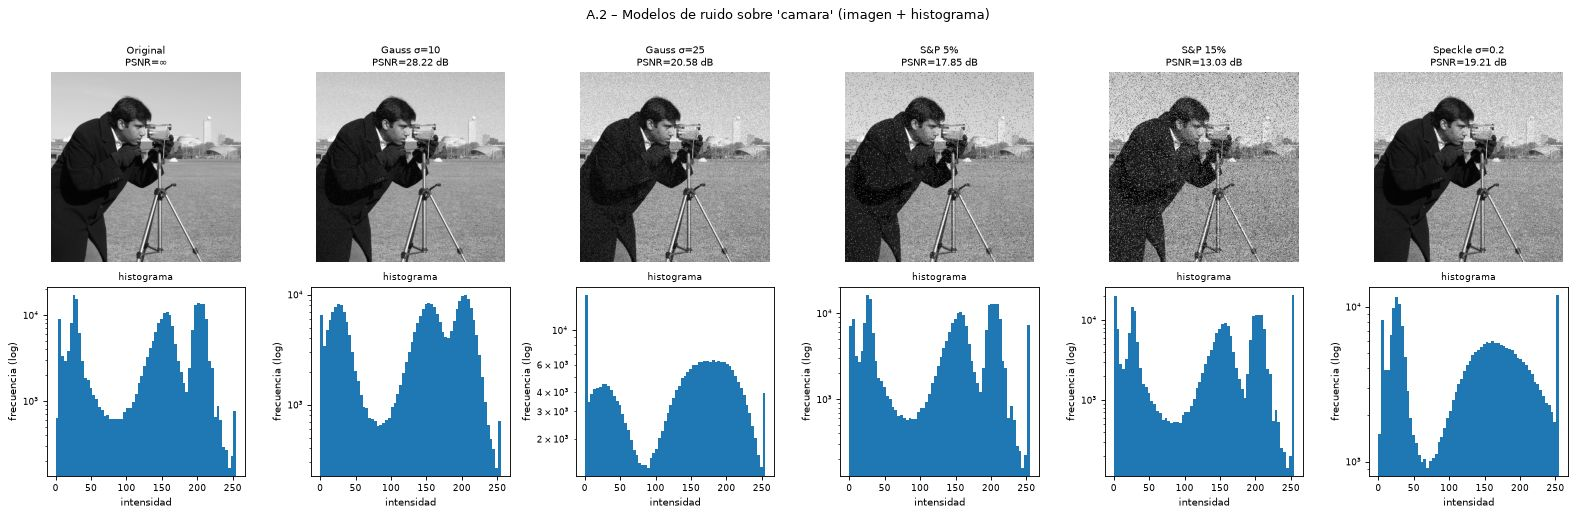

,media del error,desv. est. del error,% píxeles en 0,% píxeles en 255
Original,0.00,0.00,0.00,0.10
Gauss σ=10,0.08,9.89,1.73,0.20
Gauss σ=25,0.65,23.85,5.51,1.23
S&P 5%,-0.04,32.67,2.48,2.59
S&P 15%,-0.05,56.86,7.43,7.63
Speckle σ=0.2,-0.89,27.90,0.00,4.03


In [8]:
ruidos_camara = generar_ruidos(IMG["camara"])

nombres = ["Original"] + list(ruidos_camara)
imagenes_r = [IMG["camara"]] + list(ruidos_camara.values())
fig, ejes = plt.subplots(2, len(imagenes_r), figsize=(3.3 * len(imagenes_r), 6.4))
for j, (n, im) in enumerate(zip(nombres, imagenes_r)):
    ejes[0, j].imshow(im, cmap="gray", vmin=0, vmax=255); ejes[0, j].axis("off")
    txt_psnr = "∞" if j == 0 else "%.2f dB" % psnr(IMG["camara"], im)
    ejes[0, j].set_title(f"{n}\nPSNR={txt_psnr}")
    ejes[1, j].hist(im.ravel(), bins=64, range=(0, 255), color="tab:blue")
    ejes[1, j].set_yscale("log"); ejes[1, j].set_xlabel("intensidad"); ejes[1, j].set_ylabel("frecuencia (log)")
    ejes[1, j].set_title("histograma", fontsize=8)
plt.suptitle("A.2 – Modelos de ruido sobre 'camara' (imagen + histograma)", y=1.0); plt.tight_layout(); plt.show()

# Estadísticas del ruido (error = ruidosa − original) para describir cada modelo
est = {n: {"media del error": (im.astype(float) - IMG["camara"]).mean(),
           "desv. est. del error": (im.astype(float) - IMG["camara"]).std(),
           "% píxeles en 0": 100 * (im == 0).mean(), "% píxeles en 255": 100 * (im == 255).mean()}
       for n, im in ruidos_camara.items()}
est["Original"] = {"media del error": 0.0, "desv. est. del error": 0.0,
                   "% píxeles en 0": 100 * (IMG["camara"] == 0).mean(), "% píxeles en 255": 100 * (IMG["camara"] == 255).mean()}
display(pd.DataFrame(est).T.loc[nombres].style.format("{:.2f}"))

# **Observación (ruido).** Los histogramas muestran la "firma" de cada modelo: el gaussiano rellena los extremos del histograma y simula una campana alrededor de cada nivel (σ del error 9.9 y 23.9, casi iguales a los σ nominales 10 y 25); la sal y pimienta crea picos aislados en 0 y 255 (con p=5 % hay 2.5 % de píxeles en 0 y 2.6 % en 255) y su error tiene una desviación enorme (32.7 con 5 %, 56.9 con 15 %) porque cada píxel corrupto se equivoca por muchos niveles; el speckle (σ del error 27.9) es multiplicativo, así que el error crece con la intensidad y se acumula en 255 (4 % de píxeles saturados). Por PSNR, la peor imagen es S&P 15 % (13.0 dB) y la más leve Gauss σ=10 (28.2 dB).

# ## A.3 Catálogo de filtros de suavizado y "batalla" de filtros
#
# **Catálogo (parámetros pedidos).** Se aplica cada familia sobre la imagen `camara` con ruido gaussiano σ=25, de modo que se vea simultáneamente el *suavizado del ruido* y el *daño a los detalles*. El kernel gaussiano usa tamaño $6\sigma+1$ redondeado hacia arriba y forzado a impar.

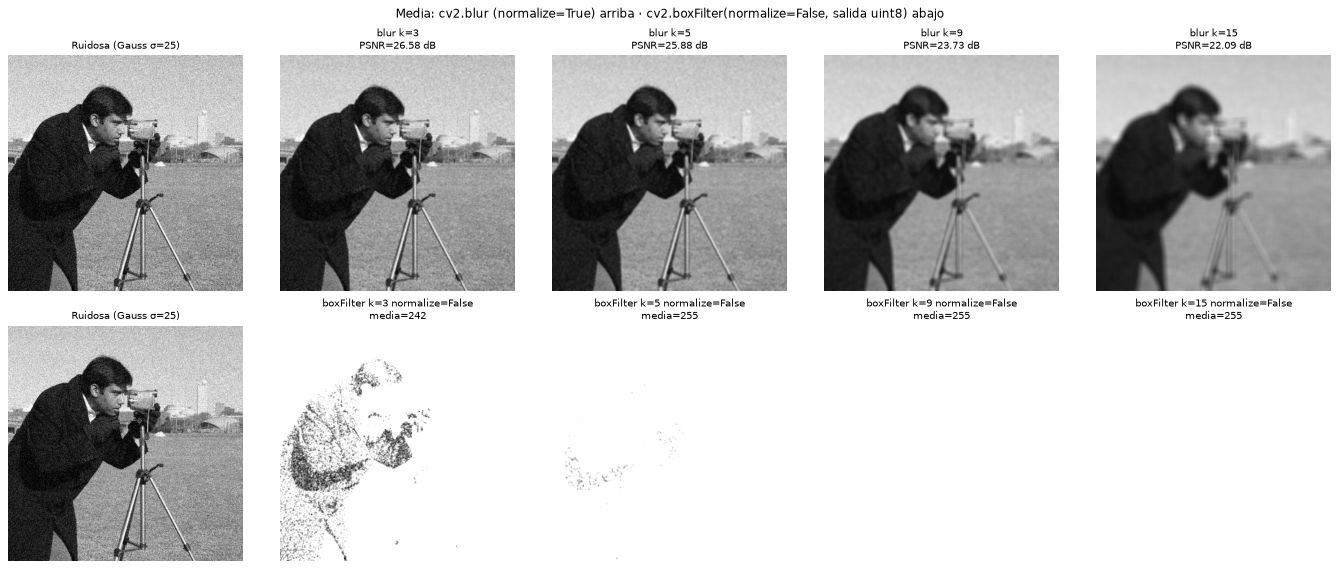

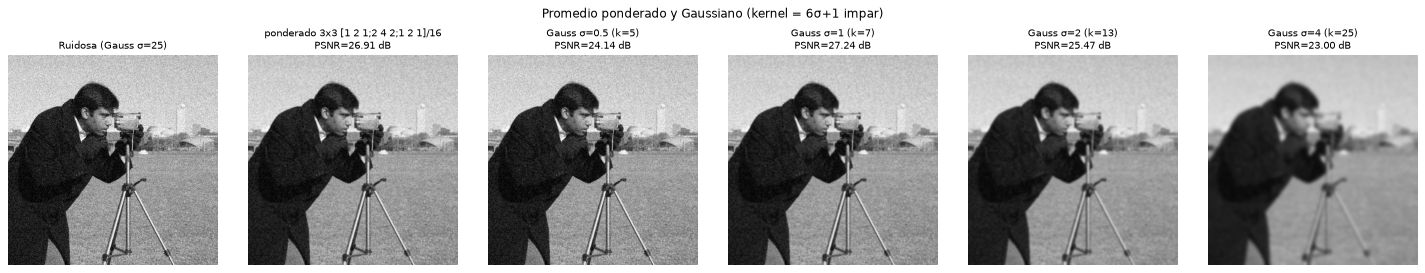

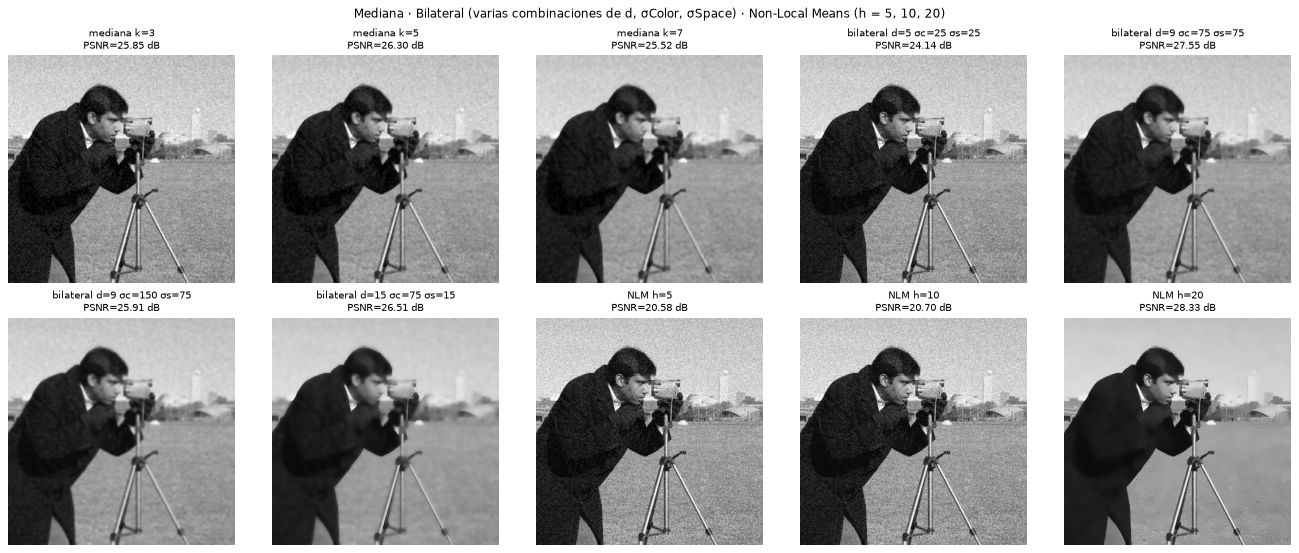

Catálogo sobre 'camara' + ruido gaussiano σ=25 (referencia: imagen limpia)


,PSNR (dB),SSIM
NLM h=20,28.335,0.755
bilateral d=9 σc=75 σs=75,27.554,0.713
Gauss σ=1 (k=7),27.239,0.644
ponderado 3x3 [1 2 1;2 4 2;1 2 1]/16,26.907,0.576
blur k=3,26.581,0.578
bilateral d=15 σc=75 σs=15,26.511,0.708
mediana k=5,26.304,0.610
bilateral d=9 σc=150 σs=75,25.907,0.688
blur k=5,25.883,0.652
mediana k=3,25.855,0.503


In [9]:
def tam_kernel_gauss(sigma):
    """Tamaño de kernel 6σ+1, redondeado hacia arriba y forzado a impar."""
    k = int(np.ceil(6 * sigma + 1))
    return k if k % 2 == 1 else k + 1


ref = IMG["camara"]
ruidosa = ruidos_camara["Gauss σ=25"]
catalogo = {}      # nombre -> imagen (para tabla de métricas)

# ---- Media / box: normalize=True y False ----
for k in (3, 5, 9, 15):
    catalogo[f"blur k={k}"] = cv2.blur(ruidosa, (k, k))
for k in (3, 5, 9, 15):
    catalogo[f"boxFilter k={k} normalize=False"] = cv2.boxFilter(ruidosa, -1, (k, k), normalize=False)   # satura (suma de k² valores)
cuadricula([ruidosa] + [catalogo[n] for n in catalogo if n.startswith("blur")] + [ruidosa] + [catalogo[n] for n in catalogo if n.startswith("box")],
           ["Ruidosa (Gauss σ=25)"] + [f"{n}\nPSNR={psnr(ref, catalogo[n]):.2f} dB" for n in catalogo if n.startswith("blur")]
           + ["Ruidosa (Gauss σ=25)"] + [f"{n}\nmedia={catalogo[n].mean():.0f}" for n in catalogo if n.startswith("box")],
           ncols=5, suptitulo="Media: cv2.blur (normalize=True) arriba · cv2.boxFilter(normalize=False, salida uint8) abajo")

# ---- Promedio ponderado 3x3 y Gaussiano ----
k_pond = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]], dtype=np.float64) / 16.0
catalogo["ponderado 3x3 [1 2 1;2 4 2;1 2 1]/16"] = cv2.filter2D(ruidosa, -1, k_pond)
for s in (0.5, 1, 2, 4):
    k = tam_kernel_gauss(s)
    catalogo[f"Gauss σ={s} (k={k})"] = cv2.GaussianBlur(ruidosa, (k, k), s)
nombres_g = [n for n in catalogo if n.startswith("ponderado") or n.startswith("Gauss")]
cuadricula([ruidosa] + [catalogo[n] for n in nombres_g], ["Ruidosa (Gauss σ=25)"] + [f"{n}\nPSNR={psnr(ref, catalogo[n]):.2f} dB" for n in nombres_g],
           ncols=6, celda=(3.0, 3.3), suptitulo="Promedio ponderado y Gaussiano (kernel = 6σ+1 impar)")

# ---- Mediana, bilateral y NLM ----
for k in (3, 5, 7):
    catalogo[f"mediana k={k}"] = cv2.medianBlur(ruidosa, k)
combos_bilat = [(5, 25, 25), (9, 75, 75), (9, 150, 75), (15, 75, 15)]       # (d, sigmaColor, sigmaSpace)
for d, sc, ss in combos_bilat:
    catalogo[f"bilateral d={d} σc={sc} σs={ss}"] = cv2.bilateralFilter(ruidosa, d, sc, ss)
for h in (5, 10, 20):
    catalogo[f"NLM h={h}"] = cv2.fastNlMeansDenoising(ruidosa, None, h, 7, 21)
nombres_m = [n for n in catalogo if n.startswith(("mediana", "bilateral", "NLM"))]
cuadricula([catalogo[n] for n in nombres_m], [f"{n}\nPSNR={psnr(ref, catalogo[n]):.2f} dB" for n in nombres_m],
           ncols=5, celda=(3.3, 3.4), suptitulo="Mediana · Bilateral (varias combinaciones de d, σColor, σSpace) · Non-Local Means (h = 5, 10, 20)")

df_cat = tablas_metricas(ref, {n: v for n, v in catalogo.items() if "normalize=False" not in n})
df_cat.loc["(sin filtrar)"] = [psnr(ref, ruidosa), ssim(ref, ruidosa)]
print("Catálogo sobre 'camara' + ruido gaussiano σ=25 (referencia: imagen limpia)")
display(df_cat.sort_values("PSNR (dB)", ascending=False).style.format("{:.3f}").highlight_max(color="#b7e4c7").highlight_min(color="#f4c7c3"))

# **Observaciones del catálogo (imagen `camara`, ruido gaussiano σ=25, 20.58 dB sin filtrar).**
# * **Compromiso ruido/detalle:** el PSNR del Gaussiano sube hasta σ=1 (27.24 dB) y luego cae: σ=2 → 25.47 dB y σ=4 → 23.00 dB. Con σ grande se elimina el ruido pero se emborronan los bordes (sesgo); con σ pequeña (0.5 → 24.14 dB) queda ruido. Lo mismo ocurre con la media: k=3 → 26.58 dB, k=9 → 23.73 dB, k=15 → 22.09 dB.
# * **Mediana:** k=5 es la mejor (26.30 dB); k=7 pierde detalle (25.52 dB). Con ruido gaussiano **no** supera al Gaussiano ni al bilateral.
# * **Bilateral:** depende mucho de los parámetros: (9,75,75) da 27.55 dB y SSIM 0.713 (el SSIM más alto entre los filtros "locales"), mientras que (5,25,25) apenas mejora (24.14 dB) por tener un `sigmaColor` menor que el ruido, y con `sigmaColor`=150 (25.91 dB) empieza a comportarse como un Gaussiano que borra bordes.
# * **NLM:** el parámetro `h` debe ser del orden de σ del ruido. Con h=5 y h=10 (≪ σ=25) el resultado es prácticamente idéntico a la imagen ruidosa (20.58 y 20.70 dB), porque ninguna ventana se parece lo suficiente a otra para promediarse; con h=20 es el mejor del catálogo (28.34 dB, SSIM 0.755).
# * **Promedio ponderado 3×3** `[1 2 1;2 4 2;1 2 1]/16` (26.91 dB) es el producto externo del binomial [1 2 1]/4 (varianza 1/2 por eje, es decir un Gaussiano de σ≈0.71) y queda entre la media 3×3 (26.58 dB) y el Gaussiano σ=1 (27.24 dB), como cabe esperar.
# * `boxFilter(normalize=False)` produce imágenes casi blancas (en uint8 satura): ver pregunta 1.2.

# **Batalla de filtros.** Se aplican seis filtros (más NLM como extra) a cada tipo de ruido y se mide **PSNR y SSIM** contra la imagen limpia. Parámetros fijos y razonables: media 5×5, Gaussiano σ=1 (7×7), mediana 5×5, mínimo 3×3, máximo 3×3, bilateral (d=9, σColor=75, σSpace=75) y NLM h=10. Se hace completa en **dos imágenes** (`camara` y `foto`).

In [10]:
FILTROS = {
    "Media 5×5": lambda im: cv2.blur(im, (5, 5)),
    "Gaussiano σ=1": lambda im: cv2.GaussianBlur(im, (tam_kernel_gauss(1),) * 2, 1),
    "Mediana 5×5": lambda im: cv2.medianBlur(im, 5),
    "Mínimo 3×3": lambda im: ndi.minimum_filter(im, size=3),
    "Máximo 3×3": lambda im: ndi.maximum_filter(im, size=3),
    "Bilateral (9,75,75)": lambda im: cv2.bilateralFilter(im, 9, 75, 75),
    "NLM h=10 (extra)": lambda im: cv2.fastNlMeansDenoising(im, None, 10, 7, 21),
}


def batalla(limpia, ruidos, filtros=FILTROS):
    """Aplica cada filtro a cada imagen ruidosa. Devuelve (DataFrame PSNR, DataFrame SSIM, dict de resultados)."""
    psnr_d, ssim_d, salidas = {}, {}, {}
    for rn, rim in ruidos.items():
        psnr_d[rn] = {"(sin filtrar)": psnr(limpia, rim)}
        ssim_d[rn] = {"(sin filtrar)": ssim(limpia, rim)}
        for fn, f in filtros.items():
            out = f(rim)
            salidas[(rn, fn)] = out
            psnr_d[rn][fn] = psnr(limpia, out)
            ssim_d[rn][fn] = ssim(limpia, out)
    return pd.DataFrame(psnr_d), pd.DataFrame(ssim_d), salidas


def ganadores(df):
    """Mejor filtro (excluyendo la fila '(sin filtrar)') para cada tipo de ruido."""
    d = df.drop(index="(sin filtrar)")
    return pd.DataFrame({"ganador": d.idxmax(), "valor": d.max()})


def mostrar_batalla(nombre, p_df, s_df):
    print(f"===== {nombre}: PSNR (dB) – verde = mejor filtro por tipo de ruido (columna) =====")
    display(p_df.style.format("{:.2f}").highlight_max(axis=0, color="#b7e4c7", subset=pd.IndexSlice[p_df.index[1:], :]))
    print(f"===== {nombre}: SSIM =====")
    display(s_df.style.format("{:.4f}").highlight_max(axis=0, color="#b7e4c7", subset=pd.IndexSlice[s_df.index[1:], :]))


RES = {}                                    # resultados por imagen: {'camara': (psnr_df, ssim_df, salidas, ruidos)}
for nombre_img in ("camara", "foto"):
    rs = ruidos_camara if nombre_img == "camara" else generar_ruidos(IMG[nombre_img])
    p_df, s_df, sal = batalla(IMG[nombre_img], rs)
    RES[nombre_img] = (p_df, s_df, sal, rs)
    mostrar_batalla(nombre_img, p_df, s_df)
    print("Ganador por PSNR:"); display(ganadores(p_df).style.format({"valor": "{:.2f}"}))
    print("Ganador por SSIM:"); display(ganadores(s_df).style.format({"valor": "{:.4f}"}))

===== camara: PSNR (dB) – verde = mejor filtro por tipo de ruido (columna) =====


,Gauss σ=10,Gauss σ=25,S&P 5%,S&P 15%,Speckle σ=0.2
(sin filtrar),28.22,20.58,17.85,13.03,19.21
Media 5×5,26.58,25.88,25.18,22.15,25.64
Gaussiano σ=1,29.11,27.24,25.75,21.58,26.64
Mediana 5×5,27.66,26.30,27.87,27.41,25.77
Mínimo 3×3,19.69,15.65,11.36,7.65,13.96
Máximo 3×3,19.48,15.12,11.45,7.71,14.89
"Bilateral (9,75,75)",28.25,27.55,21.10,15.46,26.68
NLM h=10 (extra),32.81,20.70,17.90,13.04,19.24


===== camara: SSIM =====


,Gauss σ=10,Gauss σ=25,S&P 5%,S&P 15%,Speckle σ=0.2
(sin filtrar),0.6102,0.3018,0.3621,0.1309,0.4230
Media 5×5,0.7484,0.6517,0.5873,0.4109,0.6466
Gaussiano σ=1,0.8129,0.6437,0.5707,0.3560,0.6494
Mediana 5×5,0.7514,0.6099,0.7962,0.7909,0.6074
Mínimo 3×3,0.5392,0.2731,0.2617,0.1114,0.3850
Máximo 3×3,0.5775,0.3339,0.2101,0.0776,0.5060
"Bilateral (9,75,75)",0.7713,0.7132,0.4240,0.1799,0.6407
NLM h=10 (extra),0.8900,0.3143,0.3796,0.1314,0.4582


Ganador por PSNR:


...

,Gauss σ=10,Gauss σ=25,S&P 5%,S&P 15%,Speckle σ=0.2
(sin filtrar),0.5799,0.2527,0.3046,0.0973,0.3820
Media 5×5,0.8646,0.7632,0.7100,0.5147,0.7876
Gaussiano σ=1,0.8885,0.7030,0.6433,0.4025,0.7533
Mediana 5×5,0.8658,0.7086,0.9142,0.9077,0.7549
Mínimo 3×3,0.6543,0.3189,0.2416,0.0789,0.4480
Máximo 3×3,0.6769,0.3635,0.1792,0.0409,0.4984
"Bilateral (9,75,75)",0.8661,0.7903,0.5716,0.2250,0.7867
NLM h=10 (extra),0.9280,0.2557,0.3244,0.0974,0.4828


Ganador por PSNR:


,ganador,valor
Gauss σ=10,NLM h=10 (extra),35.65
Gauss σ=25,"Bilateral (9,75,75)",29.60
S&P 5%,Mediana 5×5,31.87
S&P 15%,Mediana 5×5,31.30
Speckle σ=0.2,Gaussiano σ=1,29.53


Ganador por SSIM:


,ganador,valor
Gauss σ=10,NLM h=10 (extra),0.9280
Gauss σ=25,"Bilateral (9,75,75)",0.7903
S&P 5%,Mediana 5×5,0.9142
S&P 15%,Mediana 5×5,0.9077
Speckle σ=0.2,Media 5×5,0.7876


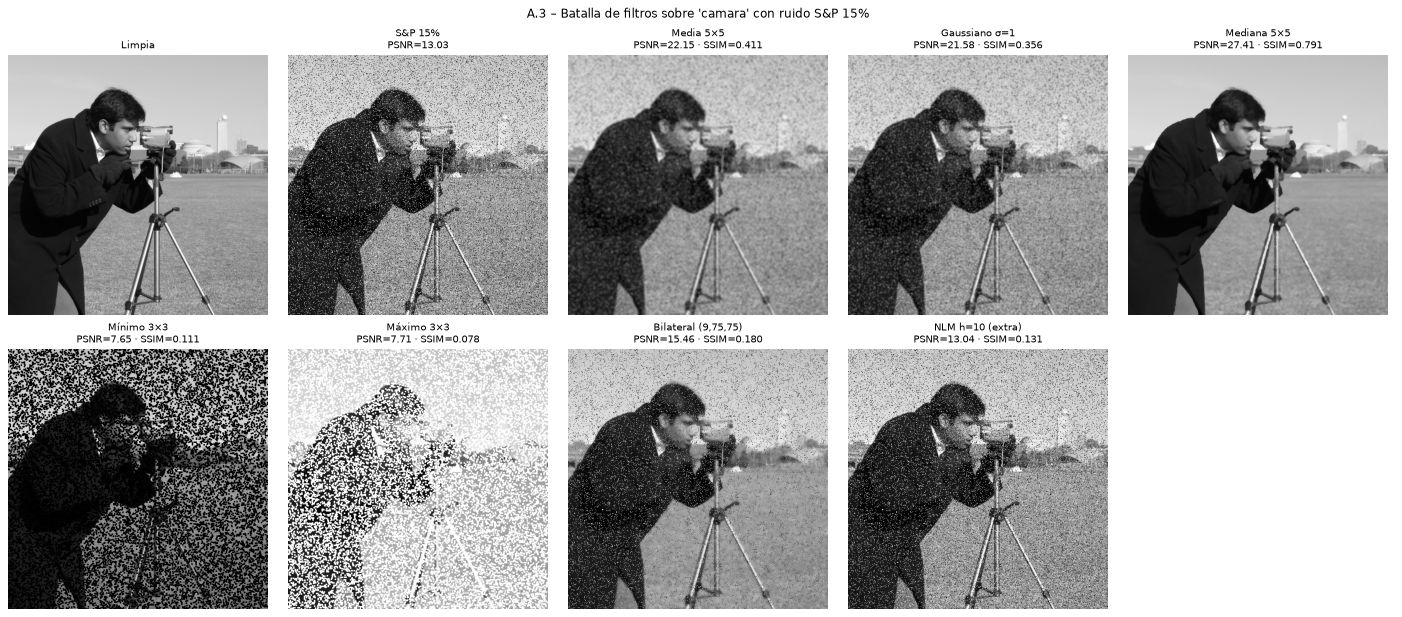

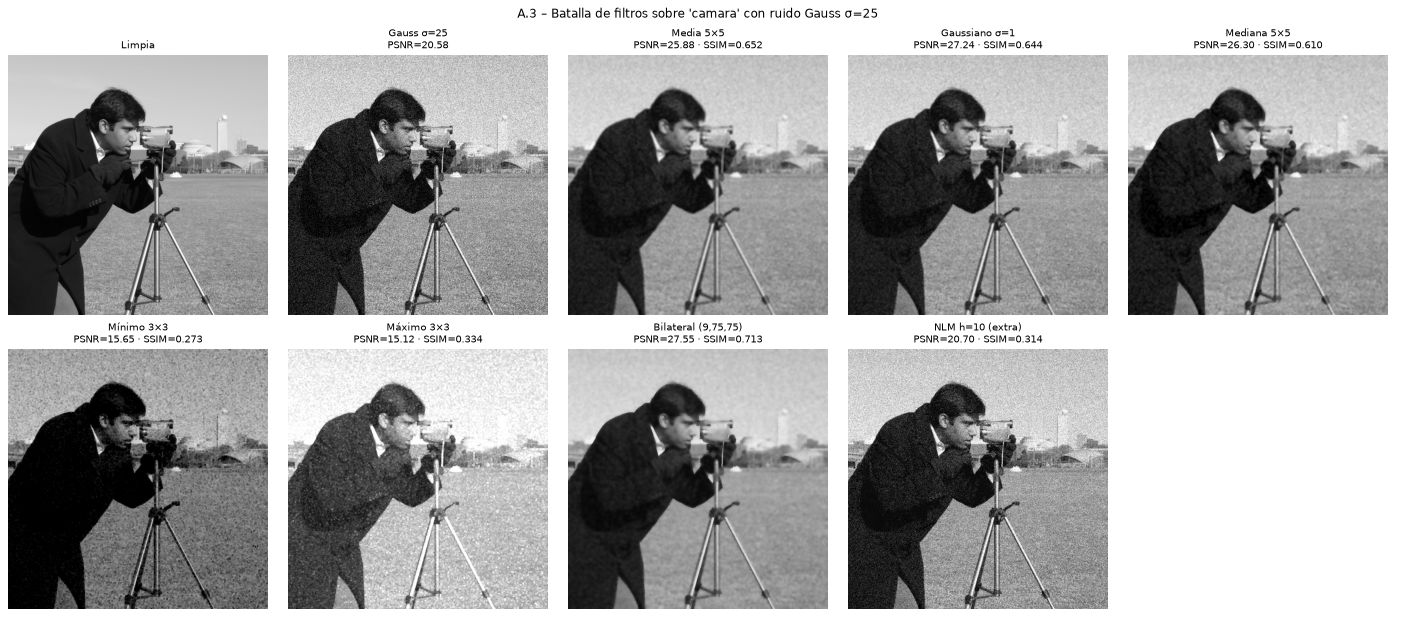

In [11]:
# ---- Visualización de la batalla (camara): dos ruidos representativos, todos los filtros ----
p_df, s_df, sal, rs = RES["camara"]
for rn in ("S&P 15%", "Gauss σ=25"):
    imgs = [IMG["camara"], rs[rn]] + [sal[(rn, f)] for f in FILTROS]
    tit = ["Limpia", f"{rn}\nPSNR={psnr(IMG['camara'], rs[rn]):.2f}"] + [f"{f}\nPSNR={p_df.loc[f, rn]:.2f} · SSIM={s_df.loc[f, rn]:.3f}" for f in FILTROS]
    cuadricula(imgs, tit, ncols=5, celda=(3.5, 3.8), suptitulo=f"A.3 – Batalla de filtros sobre 'camara' con ruido {rn}")

# **Resultados de la batalla (imagen `camara`, parámetros fijos).**
#
# | Ruido | Mejor por PSNR | Mejor por SSIM | Comentario basado en las tablas |
# |---|---|---|---|
# | Gauss σ=10 | NLM h=10 (32.81 dB) | NLM (0.890) | Entre los filtros clásicos: Gaussiano σ=1 (29.11 dB, SSIM 0.813). Con ruido tan leve, media 5×5 (26.58 dB) y mediana 5×5 (27.66 dB) quedan **por debajo de no filtrar** (28.22 dB): suavizan más de lo necesario. |
# | Gauss σ=25 | Bilateral (9,75,75): 27.55 dB | Bilateral (0.713) | Gaussiano σ=1: 27.24 dB / 0.644; mediana: 26.30 dB / 0.610. NLM h=10 no actúa (20.70 dB) porque h ≪ σ. |
# | S&P 5 % | Mediana 5×5: 27.87 dB | Mediana (0.796) | Media 25.18 dB, Gaussiano 25.75 dB, bilateral 21.10 dB. |
# | S&P 15 % | Mediana 5×5: 27.41 dB | Mediana (0.791) | Media 22.15 dB, Gaussiano 21.58 dB, **bilateral 15.46 dB** (casi no mejora los 13.03 dB de la ruidosa). |
# | Speckle σ=0.2 | Bilateral: 26.68 dB (Gaussiano σ=1: 26.64 dB, empate técnico) | Gaussiano (0.649) | Mediana 25.77 dB / 0.607 es la peor de las tres. |
#
# * **Mínimo y máximo** (erosión/dilatación en escala de grises) **empeoran** la imagen en todos los casos (p. ej. 19.69 y 19.48 dB frente a 28.22 dB sin filtrar con Gauss σ=10): son filtros de rango que sesgan el brillo (el mínimo oscurece, el máximo aclara). Solo tienen sentido para eliminar un tipo de impulso concreto (sal con el mínimo, pimienta con el máximo) y aun así amplifican el otro; con S&P 15 % bajan a 7.65 y 7.71 dB.
# * **Bilateral vs ruido impulsivo:** un píxel de 255 en un entorno de 100 tiene una diferencia de intensidad enorme con todos sus vecinos, así que el término de rango le da peso casi nulo a los vecinos: el píxel se conserva a sí mismo ("lo trata como un borde"). Por eso el bilateral falla con sal y pimienta (15.46 dB con 15 %).
# * **Segunda imagen (`foto`, la foto cargada en esta ejecución):** la estructura se repite: NLM h=10 gana con Gauss σ=10 (35.65 dB), bilateral con Gauss σ=25 (29.60 dB, SSIM 0.790), mediana con S&P (31.87 dB con 5 % y 31.30 dB con 15 %, SSIM > 0.90) y, en speckle, Gaussiano σ=1 (29.53 dB) gana por PSNR y la media 5×5 por SSIM (0.788 frente a 0.787 del bilateral): empate técnico. **Los ganadores por tipo de ruido son estables entre imágenes**, salvo el empate del speckle. (Si reemplazas la foto, las cifras de `foto` cambian; las de `camara` no.)
# * Aclaración metodológica: PSNR y SSIM no siempre coinciden (el SSIM premia conservar la estructura local); por eso se reportan ambos.

# **Barrido de parámetros (justicia en la comparación).** El resultado de la batalla depende de los parámetros elegidos. Para la recomendación final se barren las tres familias candidatas a preprocesamiento (Gaussiano, mediana y bilateral) y se toma, por cada ruido, la **mejor configuración de cada familia** según PSNR (y se informa su SSIM).

In [12]:
BARRIDO = {
    "Gaussiano": {f"σ={s}": (lambda im, s=s: cv2.GaussianBlur(im, (tam_kernel_gauss(s),) * 2, s)) for s in (0.5, 0.8, 1, 1.5, 2, 3)},
    "Mediana": {f"k={k}": (lambda im, k=k: cv2.medianBlur(im, k)) for k in (3, 5, 7, 9)},
    "Bilateral": {f"d=9 σc={sc} σs={ss}": (lambda im, sc=sc, ss=ss: cv2.bilateralFilter(im, 9, sc, ss))
                  for sc in (25, 50, 75, 100) for ss in (5, 25, 75)},
}


def barrido_mejor(limpia, ruidos):
    """Para cada ruido y familia devuelve la config. con mayor PSNR (con su SSIM)."""
    filas = []
    for rn, rim in ruidos.items():
        for fam, configs in BARRIDO.items():
            mejor = max(((psnr(limpia, f(rim)), cfg, f) for cfg, f in configs.items()), key=lambda t: t[0])
            filas.append({"ruido": rn, "familia": fam, "mejor config": mejor[1],
                          "PSNR (dB)": mejor[0], "SSIM": ssim(limpia, mejor[2](rim))})
    return pd.DataFrame(filas)


BARR = {n: barrido_mejor(IMG[n], RES[n][3]) for n in ("camara", "foto")}
for n, df in BARR.items():
    print(f"===== Barrido de parámetros – imagen '{n}': mejor configuración de cada familia por tipo de ruido =====")
    pv = df.pivot(index="ruido", columns="familia", values="PSNR (dB)")[list(BARRIDO)]
    cf = df.pivot(index="ruido", columns="familia", values="mejor config")[list(BARRIDO)]
    sv = df.pivot(index="ruido", columns="familia", values="SSIM")[list(BARRIDO)]
    out = pd.concat({"PSNR (dB)": pv, "SSIM": sv, "config": cf}, axis=1).loc[list(RES[n][3])]
    display(out.style.format({c: "{:.2f}" for c in out.columns if c[0] == "PSNR (dB)"} | {c: "{:.4f}" for c in out.columns if c[0] == "SSIM"}))

===== Barrido de parámetros – imagen 'camara': mejor configuración de cada familia por tipo de ruido =====


===== Barrido de parámetros – imagen 'foto': mejor configuración de cada familia por tipo de ruido =====


# **Resultados del barrido (`camara`).** Mejor configuración de cada familia por ruido (PSNR, SSIM entre paréntesis):
#
# | Ruido | Gaussiano | Mediana | Bilateral |
# |---|---|---|---|
# | Gauss σ=10 | 31.00 dB (0.742) con σ=0.5 | 29.27 dB (0.753) con k=3 | **32.14 dB (0.867)** con σc=25, σs=5 |
# | Gauss σ=25 | 27.24 dB (0.644) con σ=1 | 26.30 dB (0.610) con k=5 | **27.89 dB (0.673)** con σc=50, σs=5 |
# | S&P 5 % | 25.75 dB (0.571) con σ=1 | **30.14 dB (0.864)** con k=3 | 24.70 dB (0.538) |
# | S&P 15 % | 22.49 dB (0.528) con σ=2 | **28.62 dB (0.845)** con k=3 | 18.97 dB (0.265) |
# | Speckle σ=0.2 | 26.64 dB (**0.649**) con σ=1 | 25.77 dB (0.607) con k=5 | **26.75 dB** (0.643) |
#
# * Afinar los parámetros **cambia la conclusión de la batalla en un punto**: con Gauss σ=10 el bilateral bien ajustado (32.14 dB) supera con holgura al Gaussiano (31.00 dB) y, con S&P, la mediana de 3×3 (30.14 y 28.62 dB) supera a la de 5×5 de la batalla (27.87 y 27.41 dB): con ruido impulsivo conviene la ventana mínima que aún elimine los impulsos.
# * Para el bilateral el óptimo usa `sigmaSpace` **pequeño** (5) y un `sigmaColor` de 2 a 2.5 veces la σ del ruido (25 para σ=10; 50 para σ=25). Lo comprobamos en la pregunta 1.3.
# * La mejor σ del Gaussiano para σ=10 es la menor de la rejilla (0.5): el óptimo está en el borde, y es indicio de que el ruido es leve respecto a los detalles de `camara`.
# * Los ganadores por ruido en `foto` coinciden (ver tabla de arriba), salvo el speckle, donde Gaussiano y bilateral están a 0.11 dB (29.56 contra 29.45 dB).

# ## A.4 Separabilidad del kernel gaussiano
#
# El kernel gaussiano 2D es el **producto externo** de dos gaussianas 1D: $G(x,y)=g(x)\,g(y)$. Aplicar un kernel $K\times K$ cuesta $K^2$ multiplicaciones por píxel; dos pasadas 1D cuestan $2K$. Se comprueba (i) la igualdad numérica del kernel y (ii) la aceleración.

In [13]:
sigma_s, K = 5.0, 31
g1 = cv2.getGaussianKernel(K, sigma_s, ktype=cv2.CV_64F)               # (K,1), suma 1
g2_sep = np.outer(g1, g1)                                              # kernel 2D como producto externo
x = np.arange(K) - K // 2
X, Y = np.meshgrid(x, x)
g2_dir = np.exp(-(X ** 2 + Y ** 2) / (2 * sigma_s ** 2)); g2_dir /= g2_dir.sum()   # kernel 2D construido directamente
print(f"Error máximo |outer(g1,g1) − G2D directo| = {np.abs(g2_sep - g2_dir).max():.3e}   (suma g2_sep = {g2_sep.sum():.15f})")

img_f32 = IMG["camara"].astype(np.float32)
sal_2d = cv2.filter2D(img_f32, -1, g2_sep.astype(np.float32))
sal_sep = cv2.sepFilter2D(img_f32, -1, g1.astype(np.float32), g1.astype(np.float32))
sal_dos = cv2.filter2D(cv2.filter2D(img_f32, -1, g1.astype(np.float32).T), -1, g1.astype(np.float32))
print(f"Diferencia máx 2D vs sepFilter2D = {np.abs(sal_2d - sal_sep).max():.3e} | 2D vs dos filter2D 1D = {np.abs(sal_2d - sal_dos).max():.3e}  (niveles de gris)")

t_2d = medir(lambda: cv2.filter2D(img_f32, -1, g2_sep.astype(np.float32)), n=20)
t_sep = medir(lambda: cv2.sepFilter2D(img_f32, -1, g1.astype(np.float32), g1.astype(np.float32)), n=20)
t_dos = medir(lambda: cv2.filter2D(cv2.filter2D(img_f32, -1, g1.astype(np.float32).T), -1, g1.astype(np.float32)), n=20)
print(f"Tiempo kernel 2D {K}x{K} (filter2D):  {t_2d*1e3:7.3f} ms")
print(f"Tiempo cv2.sepFilter2D:                {t_sep*1e3:7.3f} ms   -> aceleración ×{t_2d/t_sep:.1f}")
print(f"Tiempo dos filter2D 1D:                {t_dos*1e3:7.3f} ms   -> aceleración ×{t_2d/t_dos:.1f}")
print(f"Operaciones por píxel: 2D = {K*K}, separable = {2*K} -> cociente teórico ×{K*K/(2*K):.1f}")

# Tendencia con el tamaño del kernel
filas = []
for Kx in (5, 11, 21, 31, 51, 71):
    g = cv2.getGaussianKernel(Kx, Kx / 6, ktype=cv2.CV_32F)
    g2 = np.outer(g, g)
    a = medir(lambda: cv2.filter2D(img_f32, -1, g2), n=10)
    b = medir(lambda: cv2.sepFilter2D(img_f32, -1, g, g), n=10)
    filas.append({"K": Kx, "2D [ms]": a * 1e3, "separable [ms]": b * 1e3, "aceleración ×": a / b, "teórica K/2 ×": Kx / 2})
display(pd.DataFrame(filas).set_index("K").style.format("{:.2f}"))

Error máximo |outer(g1,g1) − G2D directo| = 3.469e-18   (suma g2_sep = 1.000000000000000)
Diferencia máx 2D vs sepFilter2D = 7.629e-05 | 2D vs dos filter2D 1D = 9.155e-05  (niveles de gris)
Tiempo kernel 2D 31x31 (filter2D):    3.531 ms
Tiempo cv2.sepFilter2D:                  0.787 ms   -> aceleración ×4.5
Tiempo dos filter2D 1D:                  0.880 ms   -> aceleración ×4.0
Operaciones por píxel: 2D = 961, separable = 62 -> cociente teórico ×15.5


,2D [ms],separable [ms],aceleración ×,teórica K/2 ×
K,,,,
5,0.36,0.33,1.10,2.50
11,1.03,0.39,2.63,5.50
21,3.74,0.58,6.48,10.50
31,3.56,0.75,4.75,15.50
51,4.78,1.37,3.48,25.50
71,5.42,2.02,2.68,35.50


# **Observación (separabilidad).** El kernel 2D construido como `np.outer(g1, g1)` coincide con el 2D calculado directamente con un error máximo de 3.5·10⁻¹⁸ (precisión de máquina; el enunciado anticipa ≈10⁻¹⁶) y suma exactamente 1. Sobre la imagen, las tres rutas (2D, `sepFilter2D`, dos `filter2D` 1D) difieren a lo sumo 9·10⁻⁵ niveles de gris (solo redondeo de `float32`).
#
# **Aceleración.** Para K=31 el coste teórico por píxel baja de K² = 961 a 2K = 62 multiplicaciones (×15.5), pero lo **medido** es menor: `sepFilter2D` fue ≈ 4–5× más rápido que `filter2D` 2D (≈ 3.7 ms → ≈ 0.8 ms) y dos pasadas 1D ≈ 4×. La razón es que `cv2.filter2D` no hace la convolución directa con kernels grandes: OpenCV conmuta internamente a un algoritmo basado en DFT cuando el kernel es grande (por eso el tiempo 2D se aplana: ≈ 3.6 ms con K=21, ≈ 5.5 ms con K=71), y las pasadas 1D tienen además un coste de acceso a memoria que no es despreciable. En la tabla, la aceleración medida es máxima en K=21 (≈ 6–7×) y baja después (≈ 3× con K=71) porque el camino 2D por DFT se vuelve relativamente más eficiente. **Conclusión:** separar es siempre correcto y casi siempre más rápido (kernel 2D directo en implementaciones propias: ×K/2); la ganancia real depende de la implementación.

# ## Preguntas del Módulo A
#
# Cada respuesta usa evidencia de este cuaderno; las demostraciones nuevas se calculan en las celdas de código previas a cada respuesta.

In [14]:
# ---- Evidencia para 1.1: media vs mediana con outliers en una ventana 5x5 (punto de ruptura) ----
rng = np.random.default_rng(SEMILLA)
base = np.clip(100 + rng.normal(0, 3, 25), 0, 255)             # ventana 5x5 de una zona plana (≈100) con ruido leve
filas = []
for m in range(0, 14):                                          # m = nº de píxeles corrompidos con "sal" (255)
    v = base.copy(); v[:m] = 255
    filas.append({"outliers (de 25)": m, "% corrupto": 100 * m / 25, "media": v.mean(), "mediana": np.median(v),
                  "error media": v.mean() - 100, "error mediana": np.median(v) - 100})
df_ruptura = pd.DataFrame(filas).set_index("outliers (de 25)")
display(df_ruptura.style.format("{:.2f}"))

,% corrupto,media,mediana,error media,error mediana
outliers (de 25),,,,,
0,0.00,99.89,99.95,-0.11,-0.05
1,4.00,106.06,99.95,6.06,-0.05
2,8.00,112.38,100.20,12.38,0.20
3,12.00,118.49,100.20,18.49,0.20
4,16.00,124.58,100.20,24.58,0.20
5,20.00,131.01,100.38,31.01,0.38
6,24.00,137.37,101.11,37.37,1.11
7,28.00,143.55,101.40,43.55,1.40
8,32.00,149.79,102.33,49.79,2.33


# ### Pregunta 1.1 – Mediana vs media ante ruido sal y pimienta
#
# **Definiciones.** La **media** de una ventana es $\bar x=\frac1n\sum x_i$: es un operador *lineal* que da a cada muestra el mismo peso $1/n$. La **mediana** es el valor central de las muestras ordenadas: es un estadístico de *orden*, no lineal, que solo depende de la posición relativa de los valores y no de su magnitud.
#
# **Por qué la media falla con outliers.** Un único píxel de sal (255) en una zona de intensidad 100 desplaza la media de una ventana 5×5 en $(255-100)/25\approx 6.2$ niveles; en la tabla de arriba la media pasa de 99.89 a 106.06 con **un** outlier, a 131.0 con 5 y a 174.5 con 12, es decir, **crece sin cota** con la magnitud del outlier (punto de ruptura 0 %: basta una muestra arbitrariamente mala). Además, el filtro de media reparte cada impulso entre los 25 píxeles de su ventana: en la figura de la batalla, S&P 15 % + media 5×5 deja manchas grises en lugar de eliminar los puntos.
#
# **Por qué la mediana resiste.** Mientras menos de la mitad de las muestras estén corrompidas, el valor central sigue siendo uno "bueno": su **punto de ruptura es 50 %**. La tabla lo confirma: con 1 a 12 outliers (hasta 48 % de la ventana) la mediana se desvía como máximo 3.67 niveles (error 0.05 con 1 outlier), y con **13 de 25 (52 %)** se rompe y devuelve 255 (error 155).
#
# **Evidencia en imágenes (`camara`).** Con S&P 15 % la mediana 5×5 obtiene 27.41 dB / SSIM 0.791 frente a 22.15 dB / 0.411 de la media 5×5 y 21.58 dB / 0.356 del Gaussiano; con S&P 5 %, 27.87 dB frente a 25.18 y 25.75 dB. El barrido refina esto: la mediana 3×3 alcanza 30.14 dB (5 %) y 28.62 dB (15 %).
#
# **Matiz:** con ruido *gaussiano* la mediana pierde (σ=10: 27.66 dB frente a 29.11 dB del Gaussiano σ=1), pues la media aprovecha mejor las muestras cuando no hay outliers, y la mediana redondea esquinas y elimina estructuras finas.

Media de la imagen original                    :   129.06
Media con boxFilter(normalize=True)  (Σk = 1)  :   129.06
Media con normalize=False en float64 (Σk = 9)  :  1161.55  -> cociente = 9.00 (≈ Σk)
Media con normalize=False en uint8 (satura)    :   239.38  | % píxeles saturados en 255 = 81.4 %


,media antes,media después (float),cociente,% saturado en 255 tras recorte
suma del kernel,,,,
0.500000,129.061,64.531,0.500,0.000
1.000000,129.061,129.062,1.000,0.002
1.500000,129.061,193.592,1.500,31.958
2.000000,129.061,258.123,2.000,65.450


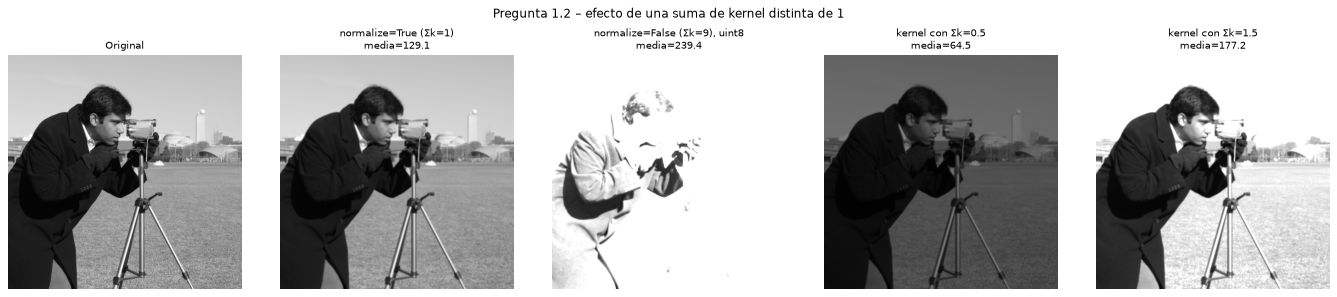

In [15]:
# ---- Evidencia para 1.2: ¿qué pasa si el kernel no suma 1? ----
img = IMG["camara"]
k = 3
caja_norm = cv2.boxFilter(img, -1, (k, k), normalize=True)                      # suma del kernel = 1
caja_sin_norm_u8 = cv2.boxFilter(img, -1, (k, k), normalize=False)              # suma = k² = 9, salida uint8 (satura)
caja_sin_norm_f64 = cv2.boxFilter(img.astype(np.float64), -1, (k, k), normalize=False)   # suma = 9 sin saturar
print(f"Media de la imagen original                    : {img.mean():8.2f}")
print(f"Media con boxFilter(normalize=True)  (Σk = 1)  : {caja_norm.mean():8.2f}")
print(f"Media con normalize=False en float64 (Σk = {k*k})  : {caja_sin_norm_f64.mean():8.2f}  -> cociente = {caja_sin_norm_f64.mean()/img.mean():.2f} (≈ Σk)")
print(f"Media con normalize=False en uint8 (satura)    : {caja_sin_norm_u8.mean():8.2f}  | % píxeles saturados en 255 = {100*(caja_sin_norm_u8==255).mean():.1f} %")

# Kernels con suma distinta de 1 (caja 3x3 reescalada)
filas = []
sal = {}
for s in (0.5, 1.0, 1.5, 2.0):
    ker = np.ones((3, 3)) / 9.0 * s
    out = cv2.filter2D(img.astype(np.float64), -1, ker)
    sal[s] = a_u8(out)
    filas.append({"suma del kernel": s, "media antes": img.mean(), "media después (float)": out.mean(),
                  "cociente": out.mean() / img.mean(), "% saturado en 255 tras recorte": 100 * (out >= 255).mean()})
display(pd.DataFrame(filas).set_index("suma del kernel").style.format("{:.3f}"))
cuadricula([img, caja_norm, caja_sin_norm_u8] + [sal[s] for s in (0.5, 1.5)],
           ["Original", f"normalize=True (Σk=1)\nmedia={caja_norm.mean():.1f}", f"normalize=False (Σk={k*k}), uint8\nmedia={caja_sin_norm_u8.mean():.1f}",
            f"kernel con Σk=0.5\nmedia={sal[0.5].mean():.1f}", f"kernel con Σk=1.5\nmedia={sal[1.5].mean():.1f}"], ncols=5, celda=(3.4, 3.6),
           suptitulo="Pregunta 1.2 – efecto de una suma de kernel distinta de 1")

# ### Pregunta 1.2 – ¿Qué pasa con el brillo medio si el kernel no suma 1?
#
# Un filtro lineal e invariante tiene ganancia a frecuencia cero $H(0)=\sum k_{ij}$, y por tanto $\text{media}(g)\approx(\sum k)\cdot\text{media}(f)$ (salvo en los bordes). Si el kernel no está normalizado, **escala el brillo medio por la suma del kernel**.
#
# **Evidencia numérica** (celda anterior, imagen `camara`, media original 129.06):
# * `boxFilter(normalize=True)` (Σk=1): media 129.06, brillo conservado.
# * `boxFilter(normalize=False)` con k=3 (Σk=9), en `float64`: media 1161.55, es decir **exactamente ×9.00**. En `uint8` el resultado se **satura**: media 239.38 y 81.4 % de los píxeles clavados en 255 (imagen casi blanca, sin información).
# * Kernel de caja con Σk=0.5: media 64.53 (×0.500, imagen más oscura, 0 % saturado). Con Σk=1.5: media 193.59 y 32.0 % de píxeles saturados; con Σk=2: 65.5 % saturados.
#
# **Conclusión:** para suavizar (que no debe cambiar el brillo) el kernel debe sumar 1. Si Σk>1 se aclara y se satura (pérdida irreversible de información); si Σk<1 se oscurece. Los kernels de derivada suman 0 a propósito (eliminan el nivel medio y dejan solo los cambios), y por eso su salida se interpreta con otra escala (ver Módulo B).

,σ ruido en zona plana,ancho del borde 10–90 % [px],pendiente máx. [niveles/px],PSNR vs limpia [dB]
ruidosa (sin filtrar),11.95,0.00,121.30,26.52
Gaussiano σ=3,1.03,8.00,15.77,31.26
Bilat d=15 σc=10 σs=10 (σc < ruido),7.16,0.00,120.27,30.81
Bilat d=15 σc=40 σs=10,1.34,0.00,115.20,40.95
Bilat d=15 σc=300 σs=10 (σc ≫ escalón),0.89,10.00,17.30,30.57
Bilat d=15 σc=40 σs=2,2.01,0.00,116.27,40.16
Bilat d=15 σc=40 σs=100,1.33,0.00,115.11,40.89


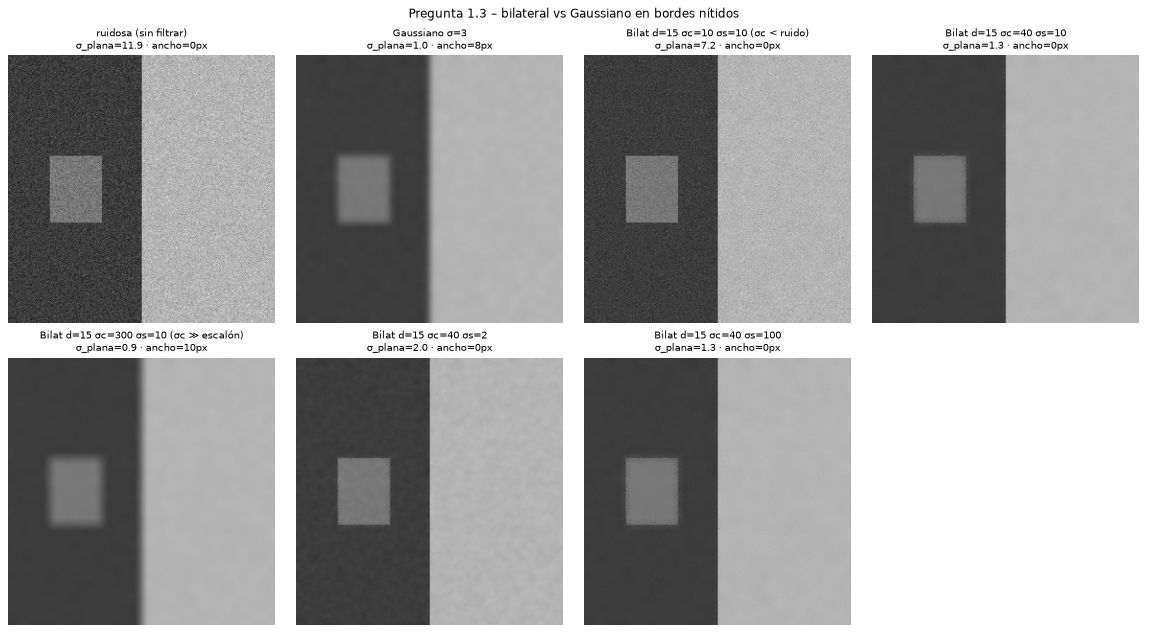

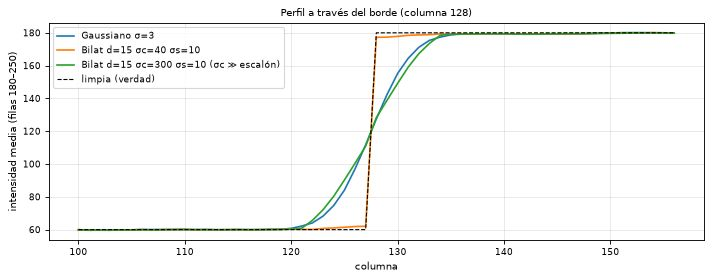

In [16]:
# ---- Evidencia para 1.3: bilateral vs Gaussiano en una imagen con borde nítido ----
M = 256
sint = np.full((M, M), 60.0); sint[:, M // 2:] = 180.0              # escalón de 120 niveles en la columna 128
sint[96:160, 40:90] = 120.0                                         # un rectángulo más (otro borde)
sint_ruidosa = a_u8(sint + np.random.default_rng(SEMILLA).normal(0, 12, sint.shape))

def metricas_borde(im):
    """σ del ruido en una zona plana, y ancho 10-90% del escalón (px) y pendiente máxima en el borde vertical (col. 128)."""
    plana = im[10:50, 150:240].astype(float)
    perfil = im[180:250, :].astype(float).mean(axis=0)               # perfil medio (se promedia el ruido por filas)
    lo, hi = perfil[110:120].mean(), perfil[137:147].mean()
    frac = (perfil[100:157] - lo) / (hi - lo)
    ancho = np.sum((frac > 0.1) & (frac < 0.9))
    return plana.std(), ancho, np.abs(np.diff(perfil[100:157])).max()

variantes = {
    "ruidosa (sin filtrar)": sint_ruidosa,
    "Gaussiano σ=3": cv2.GaussianBlur(sint_ruidosa, (19, 19), 3),
    "Bilat d=15 σc=10 σs=10 (σc < ruido)": cv2.bilateralFilter(sint_ruidosa, 15, 10, 10),
    "Bilat d=15 σc=40 σs=10": cv2.bilateralFilter(sint_ruidosa, 15, 40, 10),
    "Bilat d=15 σc=300 σs=10 (σc ≫ escalón)": cv2.bilateralFilter(sint_ruidosa, 15, 300, 10),
    "Bilat d=15 σc=40 σs=2": cv2.bilateralFilter(sint_ruidosa, 15, 40, 2),
    "Bilat d=15 σc=40 σs=100": cv2.bilateralFilter(sint_ruidosa, 15, 40, 100),
}
filas = {n: dict(zip(["σ ruido en zona plana", "ancho del borde 10–90 % [px]", "pendiente máx. [niveles/px]"], metricas_borde(v))) for n, v in variantes.items()}
df_bil = pd.DataFrame(filas).T
df_bil["PSNR vs limpia [dB]"] = [psnr(a_u8(sint), v) for v in variantes.values()]
display(df_bil.style.format("{:.2f}"))
cuadricula(list(variantes.values()), [f"{n}\nσ_plana={df_bil.loc[n].iloc[0]:.1f} · ancho={df_bil.loc[n].iloc[1]:.0f}px" for n in variantes], ncols=4,
           celda=(3.6, 3.9), suptitulo="Pregunta 1.3 – bilateral vs Gaussiano en bordes nítidos")

# Perfil horizontal medio: se ve el escalón preservado o suavizado
plt.figure(figsize=(9, 3.6))
for n in ("Gaussiano σ=3", "Bilat d=15 σc=40 σs=10", "Bilat d=15 σc=300 σs=10 (σc ≫ escalón)"):
    plt.plot(np.arange(100, 157), variantes[n][180:250, 100:157].astype(float).mean(axis=0), label=n)
plt.plot(np.arange(100, 157), sint[200, 100:157], "k--", lw=1, label="limpia (verdad)")
plt.xlabel("columna"); plt.ylabel("intensidad media (filas 180–250)"); plt.title("Perfil a través del borde (columna 128)"); plt.legend(fontsize=8); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

# ### Pregunta 1.3 – ¿Cómo preserva bordes el filtro bilateral? Papel de σColor y σSpace
#
# **Mecanismo.** El filtro bilateral calcula, para cada píxel $p$, un promedio ponderado de sus vecinos $q$ con peso
# $w(p,q)=\exp\!\big(-\|p-q\|^2/2\sigma_s^2\big)\cdot\exp\!\big(-(I_p-I_q)^2/2\sigma_c^2\big)$ (normalizado). El primer factor es un Gaussiano **espacial** (como en el filtro gaussiano); el segundo es un Gaussiano **de rango** (diferencia de intensidad). Un vecino al otro lado de un borde tiene una intensidad muy distinta, su peso de rango es casi 0 y **no contribuye al promedio**: el borde no se mezcla.
#
# **Cuentas para la imagen de prueba** (escalón de 120 niveles con ruido σ=12; diferencia típica entre dos píxeles de la misma zona ≈ 12·√2 ≈ 17):
# * σc=40: peso de rango del otro lado del borde $e^{-120^2/(2\cdot 40^2)}=e^{-4.5}\approx 0.011$ (despreciable); peso entre vecinos de la misma zona $e^{-17^2/(2\cdot 40^2)}\approx 0.91$ (se promedian). **Suaviza lo plano y respeta el borde.**
# * σc=300 (≫ escalón): peso del otro lado $e^{-0.08}\approx 0.92$: el término de rango deja de discriminar y el filtro se comporta como un Gaussiano.
#
# **Evidencia medida** (tabla de la celda anterior):
# * Sin filtrar: σ del ruido en zona plana 11.95. **Gaussiano σ=3:** baja a 1.03 pero el borde pasa a medir **8 px** (de 10 % a 90 %) y su pendiente cae de ≈121 a 15.8 niveles/px; PSNR 31.26 dB.
# * **Bilateral σc=40, σs=10:** ruido 1.34, borde de **≈ 0 px** de ancho (pendiente 115.2, casi intacta) y **PSNR 40.95 dB**, casi 10 dB mejor que el Gaussiano.
# * **σc=300:** ruido 0.89, pero el borde mide 10 px y la pendiente baja a 17.3; PSNR 30.57 dB: equivale al Gaussiano (confirma el papel de σc).
# * **σc=10 (menor que el ruido):** solo baja el ruido a 7.16 (PSNR 30.81 dB): casi todo el ruido es "diferente" y se trata como borde; σc debe ser mayor que la amplitud del ruido pero menor que el contraste del borde a preservar.
# * **σs** controla el *tamaño* del vecindario: con σs=2 (ventana efectiva pequeña) el ruido solo baja a 2.01 (PSNR 40.16 dB); con σs=10 y σs=100 el resultado es casi idéntico (1.34 y 1.33) porque `d=15` ya limita la ventana a radio 7 (σs más grande no amplía nada).
#
# **Limitación:** el bilateral no ayuda con ruido impulsivo (en la batalla, 15.46 dB con S&P 15 %), pues un píxel de sal no se parece a ningún vecino y se conserva a sí mismo.

# ---
# # Módulo B – Realce y detección de bordes (8 %)
#
# Los bordes son cambios locales de intensidad, así que se detectan con **derivadas**:
# * **Primera derivada** (gradiente): $\nabla f=(G_x,G_y)$, magnitud $|\nabla f|=\sqrt{G_x^2+G_y^2}$ y dirección $\theta=\operatorname{atan2}(G_y,G_x)$. Operadores: Roberts, Prewitt, Sobel y Scharr.
# * **Segunda derivada**: Laplaciano $\nabla^2 f$ (cruces por cero en los bordes), LoG y DoG.
# * **Canny**: suavizado + gradiente + supresión de no-máximos + histéresis.
# * **Realce**: *unsharp masking* / *high-boost*.
#
# **Regla de dtypes del módulo:** todas las derivadas se calculan en `float64` (`cv2.CV_64F`), porque tienen signo y rango mayor que [0,255]; solo se pasa a `uint8` para Canny (que lo exige) o para mostrar.
#
# ## B.1 Gradientes: Roberts, Prewitt, Sobel y Scharr

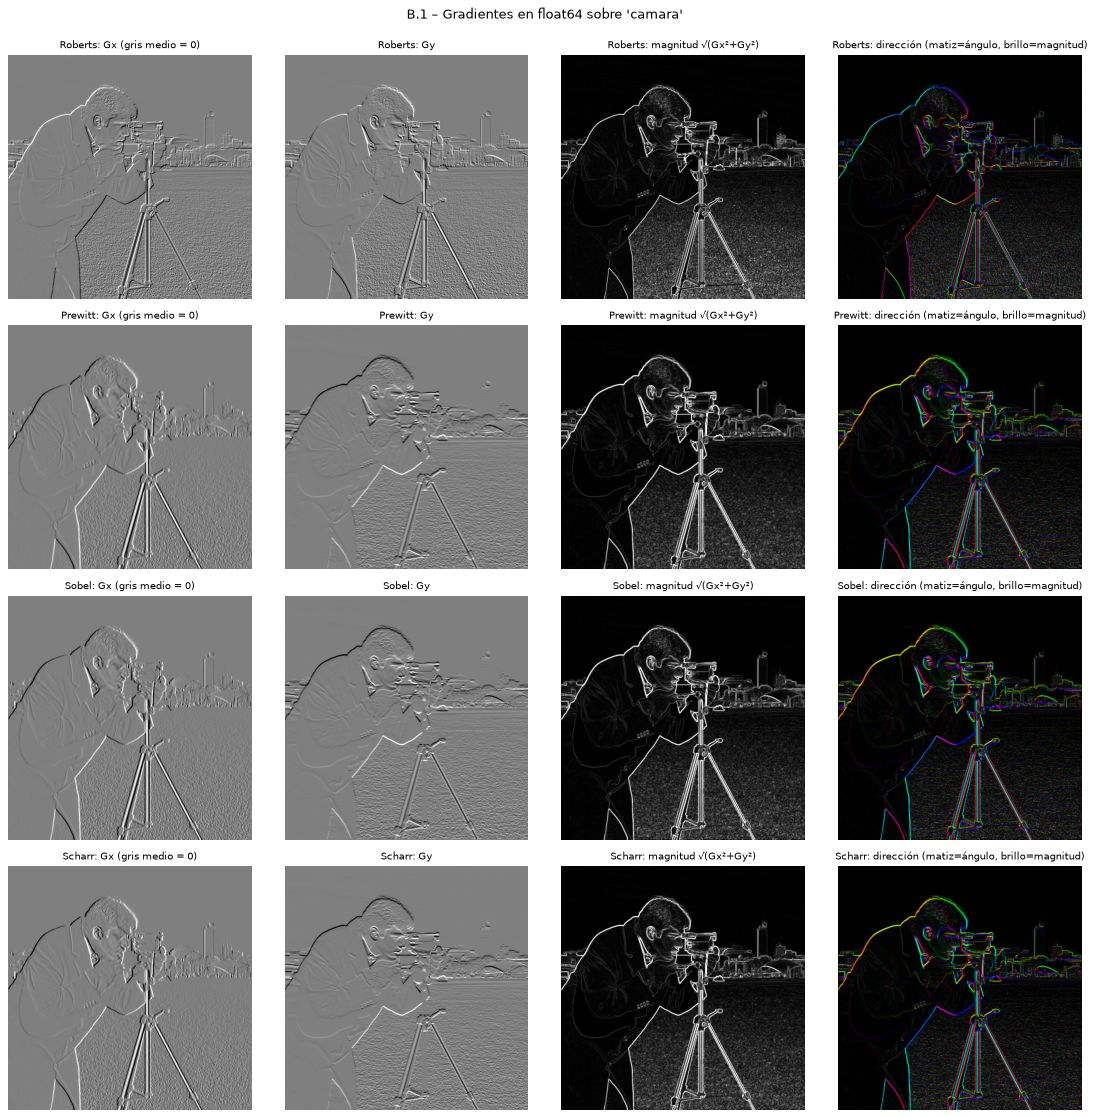

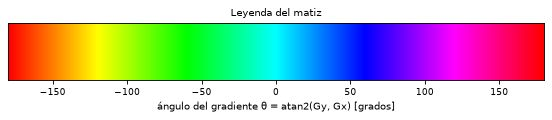

In [17]:
from skimage.color import hsv2rgb

KERNELS_1ra = {
    # Roberts 2x2 (diagonales). En filter2D con kernel par el ancla queda desplazada medio píxel; no afecta a la forma del resultado.
    "Roberts": (np.array([[1, 0], [0, -1]], float), np.array([[0, 1], [-1, 0]], float)),
    "Prewitt": (np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], float), np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], float)),
}


def gradientes(img, operador, ksize=3):
    """Devuelve (Gx, Gy, magnitud, dirección en rad) en float64 para Roberts/Prewitt/Sobel/Scharr."""
    f = img.astype(np.float64)
    if operador in KERNELS_1ra:
        kx, ky = KERNELS_1ra[operador]
        gx = cv2.filter2D(f, cv2.CV_64F, kx)
        gy = cv2.filter2D(f, cv2.CV_64F, ky)
    elif operador == "Sobel":
        gx = cv2.Sobel(f, cv2.CV_64F, 1, 0, ksize=ksize)
        gy = cv2.Sobel(f, cv2.CV_64F, 0, 1, ksize=ksize)
    elif operador == "Scharr":
        gx = cv2.Scharr(f, cv2.CV_64F, 1, 0)
        gy = cv2.Scharr(f, cv2.CV_64F, 0, 1)
    else:
        raise ValueError(operador)
    return gx, gy, np.hypot(gx, gy), np.arctan2(gy, gx)


def mapa_direccion_hsv(mag, ang, p_sat=99):
    """Mapa HSV: matiz = ángulo (−π..π -> 0..1), saturación = 1, brillo = magnitud normalizada. Devuelve RGB en [0,1]."""
    H = (ang + np.pi) / (2 * np.pi)
    V = np.clip(mag / np.percentile(mag, p_sat), 0, 1)
    hsv = np.stack([H, np.ones_like(H), V], axis=-1).astype(np.float32)
    return hsv2rgb(hsv)


img = IMG["camara"]
fig, ejes = plt.subplots(4, 4, figsize=(14, 14))
for i, op in enumerate(("Roberts", "Prewitt", "Sobel", "Scharr")):
    gx, gy, mag, ang = gradientes(img, op)
    lim = np.percentile(np.abs(gx), 99)
    ejes[i, 0].imshow(gx, cmap="gray", vmin=-lim, vmax=lim); ejes[i, 0].set_title(f"{op}: Gx (gris medio = 0)")
    ejes[i, 1].imshow(gy, cmap="gray", vmin=-lim, vmax=lim); ejes[i, 1].set_title(f"{op}: Gy")
    ejes[i, 2].imshow(mag, cmap="gray", vmax=np.percentile(mag, 99)); ejes[i, 2].set_title(f"{op}: magnitud √(Gx²+Gy²)")
    ejes[i, 3].imshow(mapa_direccion_hsv(mag, ang)); ejes[i, 3].set_title(f"{op}: dirección (matiz=ángulo, brillo=magnitud)")
    for ax in ejes[i]:
        ax.axis("off")
plt.suptitle("B.1 – Gradientes en float64 sobre 'camara'", y=0.995); plt.tight_layout(); plt.show()

# Rueda de color de referencia para interpretar el mapa de dirección
th = np.linspace(-np.pi, np.pi, 256); rr = np.linspace(0, 1, 100)
TH, RR = np.meshgrid(th, rr)
rueda = hsv2rgb(np.stack([(TH + np.pi) / (2 * np.pi), np.ones_like(TH), np.ones_like(TH)], -1))
plt.figure(figsize=(7, 1.6)); plt.imshow(rueda, extent=[-180, 180, 0, 1], aspect="auto"); plt.yticks([])
plt.xlabel("ángulo del gradiente θ = atan2(Gy, Gx) [grados]"); plt.title("Leyenda del matiz"); plt.tight_layout(); plt.show()

# **Observaciones (B.1).**
# * $G_x$ responde a bordes **verticales** y $G_y$ a bordes **horizontales**; en las imágenes de $G_x$/$G_y$ (gris medio = 0) los bordes claro→oscuro aparecen negros y los oscuro→claro blancos: el signo codifica el sentido de la transición. La magnitud los resume (siempre ≥ 0).
# * **Prewitt, Sobel y Scharr** dan mapas casi indistinguibles a simple vista: los tres son derivada en una dirección × promedio en la otra (pesos [1 1 1], [1 2 1] y [3 10 3]). Roberts (2×2, diagonales) es el más fino pero también el que más resalta la textura del césped, porque no promedia nada.
# * En el mapa HSV, el **matiz** da la orientación del gradiente (perpendicular al borde) y el brillo la fuerza: p. ej. el contorno superior de la cabeza/abrigo aparece de un color y el borde derecho del trípode de otro. Los fondos lisos quedan negros (magnitud ≈ 0), donde el ángulo no tiene sentido.

# **Por qué NO usar `cv2.CV_8U` para derivadas.** Un gradiente tiene **signo**: pasar de oscuro a claro da $G_x>0$ y de claro a oscuro $G_x<0$. Si la profundidad de salida es `CV_8U`, OpenCV *satura*: todo valor negativo se vuelve **0** (se pierde la mitad de los bordes, los de transición claro→oscuro) y todo valor $>255$ se vuelve 255 (se pierde la magnitud de los bordes fuertes). Con `CV_64F` se conservan signo y magnitud real; luego se toma $|G|$ o la magnitud.

Sobel dx: % de píxeles con Gx < 0 (se truncan a 0 en CV_8U) = 45.3 %
Sobel dx: % de píxeles con Gx > 255 (se saturan en 255)      = 1.32 %
Suma de |Gx| real vs suma de Gx en CV_8U -> se pierde el 54.1 % de la 'energía' de bordes en x
Correlación entre la magnitud correcta (CV_64F) y la obtenida desde CV_8U = 0.686


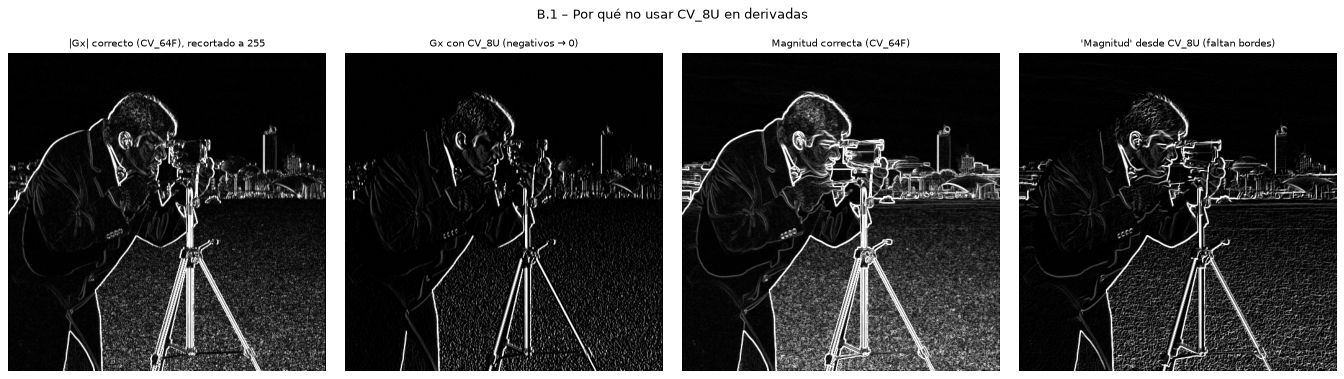

In [18]:
f = img.astype(np.float64)
gx64 = cv2.Sobel(f, cv2.CV_64F, 1, 0, ksize=3)
gx8 = cv2.Sobel(img, cv2.CV_8U, 1, 0, ksize=3)                         # CV_8U: se truncan negativos y se satura en 255
gy64 = cv2.Sobel(f, cv2.CV_64F, 0, 1, ksize=3)
gy8 = cv2.Sobel(img, cv2.CV_8U, 0, 1, ksize=3)
mag64 = np.hypot(gx64, gy64)
mag8 = np.hypot(gx8.astype(float), gy8.astype(float))                  # "magnitud" calculada a partir de la salida CV_8U (errónea)

neg = 100 * (gx64 < 0).mean(); sat = 100 * (gx64 > 255).mean()
perdida = 100 * (1 - gx8.astype(float).sum() / np.abs(gx64).sum())
print(f"Sobel dx: % de píxeles con Gx < 0 (se truncan a 0 en CV_8U) = {neg:.1f} %")
print(f"Sobel dx: % de píxeles con Gx > 255 (se saturan en 255)      = {sat:.2f} %")
print(f"Suma de |Gx| real vs suma de Gx en CV_8U -> se pierde el {perdida:.1f} % de la 'energía' de bordes en x")
print(f"Correlación entre la magnitud correcta (CV_64F) y la obtenida desde CV_8U = {np.corrcoef(mag64.ravel(), mag8.ravel())[0, 1]:.3f}")

fig, ejes = plt.subplots(1, 4, figsize=(17, 4.6))
ejes[0].imshow(np.abs(gx64), cmap="gray", vmin=0, vmax=255); ejes[0].set_title("|Gx| correcto (CV_64F), recortado a 255")
ejes[1].imshow(gx8, cmap="gray", vmin=0, vmax=255); ejes[1].set_title("Gx con CV_8U (negativos → 0)")
ejes[2].imshow(np.clip(mag64, 0, 255), cmap="gray"); ejes[2].set_title("Magnitud correcta (CV_64F)")
ejes[3].imshow(np.clip(mag8, 0, 255), cmap="gray"); ejes[3].set_title("'Magnitud' desde CV_8U (faltan bordes)")
for ax in ejes:
    ax.axis("off")
plt.suptitle("B.1 – Por qué no usar CV_8U en derivadas", y=1.02); plt.tight_layout(); plt.show()

# **Resultado (CV_8U vs CV_64F).** En Sobel dx de `camara`, **45.3 %** de los píxeles tienen $G_x<0$ (se truncan a 0 en `CV_8U`) y 1.32 % superan 255 (se saturan). Sumando, la salida `CV_8U` conserva solo ≈ 46 % de la "masa" de $|G_x|$ (se pierde el **54.1 %**), y la magnitud reconstruida a partir de `CV_8U` tiene una correlación de apenas 0.686 con la magnitud correcta: en la figura se ve que **desaparecen todos los bordes claro→oscuro** (por ejemplo, el lado izquierdo del abrigo y de las patas del trípode, según el sentido de la transición).

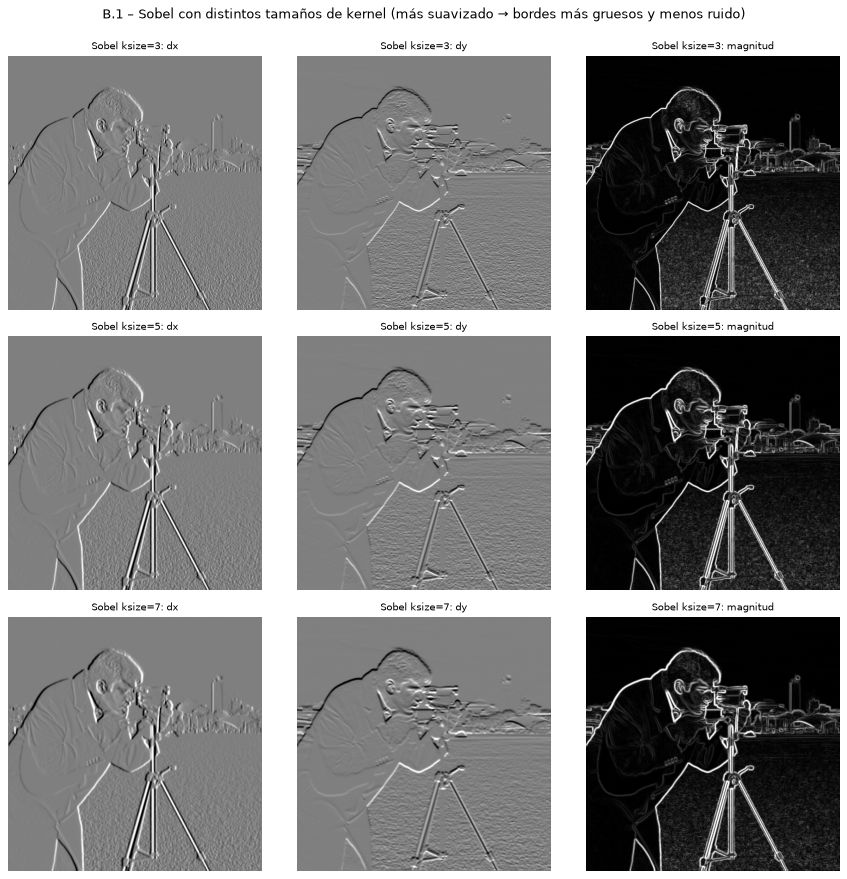

,correlación magnitud limpia vs ruidosa,‖ruido‖/‖señal‖ en magnitud
Roberts,0.839,0.667
Prewitt,0.942,0.380
Sobel (ksize=3),0.938,0.394
Sobel (ksize=5),0.976,0.239
Sobel (ksize=7),0.986,0.180
Scharr,0.928,0.428


In [19]:
# ---- Sobel con ksize = 3, 5, 7 (dx, dy, magnitud) ----
fig, ejes = plt.subplots(3, 3, figsize=(11, 11))
for i, ks in enumerate((3, 5, 7)):
    gx, gy, mag, _ = gradientes(img, "Sobel", ksize=ks)
    lim = np.percentile(np.abs(gx), 99)
    ejes[i, 0].imshow(gx, cmap="gray", vmin=-lim, vmax=lim); ejes[i, 0].set_title(f"Sobel ksize={ks}: dx")
    ejes[i, 1].imshow(gy, cmap="gray", vmin=-lim, vmax=lim); ejes[i, 1].set_title(f"Sobel ksize={ks}: dy")
    ejes[i, 2].imshow(mag, cmap="gray", vmax=np.percentile(mag, 99)); ejes[i, 2].set_title(f"Sobel ksize={ks}: magnitud")
    for ax in ejes[i]:
        ax.axis("off")
plt.suptitle("B.1 – Sobel con distintos tamaños de kernel (más suavizado → bordes más gruesos y menos ruido)", y=0.995)
plt.tight_layout(); plt.show()

# Sensibilidad al ruido de cada operador: relación error/señal de la magnitud ante ruido gaussiano σ=10
ruido10 = ruidos_camara["Gauss σ=10"]
filas = {}
for op, ks in (("Roberts", 3), ("Prewitt", 3), ("Sobel", 3), ("Sobel", 5), ("Sobel", 7), ("Scharr", 3)):
    m_lim = gradientes(IMG["camara"], op, ks)[2]; m_rui = gradientes(ruido10, op, ks)[2]
    filas[f"{op} (ksize={ks})" if op == "Sobel" else op] = {"correlación magnitud limpia vs ruidosa": np.corrcoef(m_lim.ravel(), m_rui.ravel())[0, 1],
                                                           "‖ruido‖/‖señal‖ en magnitud": np.linalg.norm(m_rui - m_lim) / np.linalg.norm(m_lim)}
display(pd.DataFrame(filas).T.style.format("{:.3f}"))

# **Observaciones (Sobel con varios `ksize` y sensibilidad al ruido).** Al crecer `ksize` el operador integra sobre más píxeles: los bordes se vuelven más gruesos y los detalles finos (césped) se atenúan. En la tabla (ruido gaussiano σ=10), la fracción ruido/señal de la magnitud baja de **0.394 (ksize=3)** a **0.239 (ksize=5)** y **0.180 (ksize=7)**, y la correlación entre magnitud limpia y ruidosa sube de 0.938 a 0.976 y 0.986. **Roberts** (2×2, sin promedio) es el más sensible (0.667), Prewitt y Sobel 3×3 quedan en 0.380–0.394, y **Scharr** (0.428) es algo más ruidoso porque sus pesos [3 10 3] son más grandes y estima mejor la dirección (más isótropo), no porque suavice menos. **Compromiso:** más suavizado = menos ruido pero peor localización.

# ## B.2 Segunda derivada: Laplaciano (4 y 8 vecinos), LoG y DoG
#
# * **Laplaciano de 4 vecinos:** `[0 1 0; 1 -4 1; 0 1 0]` — equivale a `cv2.Laplacian(..., ksize=1)`.
# * **Laplaciano de 8 vecinos:** `[1 1 1; 1 -8 1; 1 1 1]` (con `filter2D`; ojo: `cv2.Laplacian(ksize=3)` **no** es este kernel, es `[2 0 2; 0 -8 0; 2 0 2]`).
# * **LoG** = Laplaciano del Gaussiano: se suaviza con $G_\sigma$ y luego se deriva ($\nabla^2(G_\sigma * f)=(\nabla^2 G_\sigma)*f$).
# * **DoG** = $G_{\sigma_1}-G_{\sigma_2}$ con $\sigma_2=1.6\,\sigma_1$; aproxima al LoG **cambiado de signo**: $G_{\sigma}-G_{k\sigma}\approx-(k-1)\,\sigma^2\,\nabla^2 G_\sigma$ (el Laplaciano de un Gaussiano es negativo en el centro, mientras que la resta de Gaussianas es positiva).

cv2.Laplacian(ksize=1) vs filter2D(kernel 4 vecinos): error máx = 0.00e+00


,correlación con LoG (SciPy),error relativo tras ajustar escala
Laplaciano 4 (directo),0.2238,0.9746
LoG 4 vecinos (σ=2),0.9996,0.0289
LoG 8 vecinos (σ=2),0.9994,0.0366
"DoG (σ1=2, σ2=3.2) [vs −LoG]",0.9574,0.2888


DoG vs −(k−1)σ²·LoG(σ1) con k=1.6: error relativo = 0.3260


Mayor correlación DoG–(−LoG) = 0.9993 con σ_LoG = 2.5  (con σ_LoG = σ1 = 2.0: 0.9574)


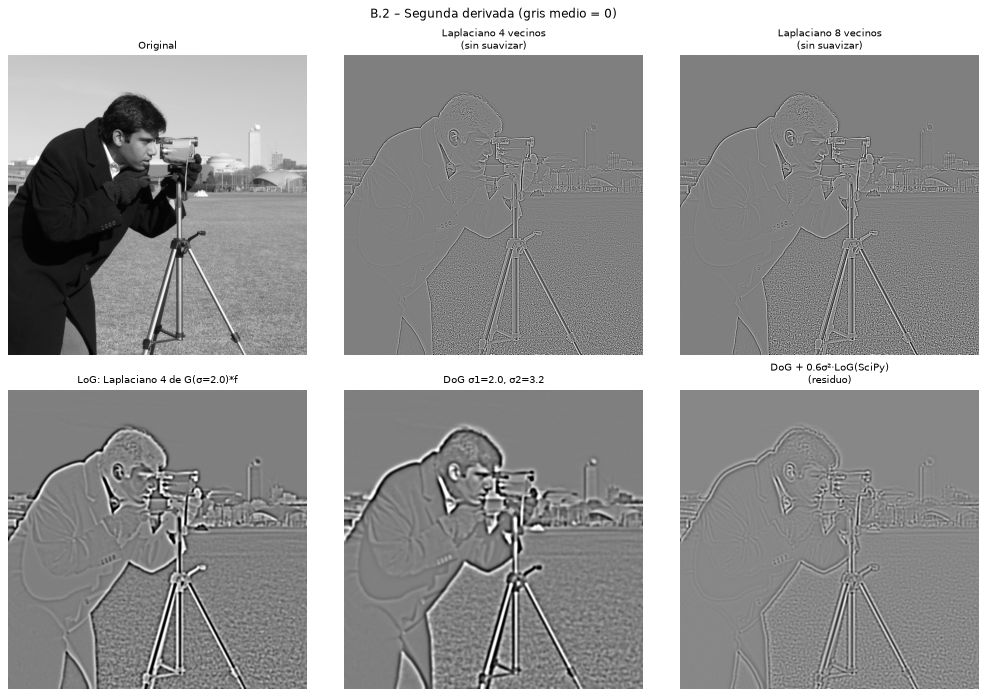

Cruces por cero: LoG = 2126 px, DoG = 1135 px
  coincidencia exacta píxel a píxel: 47.4 % de los del LoG están en el DoG
  con tolerancia ±2 px: 72.2 % de los del LoG tienen un cruce del DoG cerca; 99.9 % de los del DoG tienen uno del LoG cerca


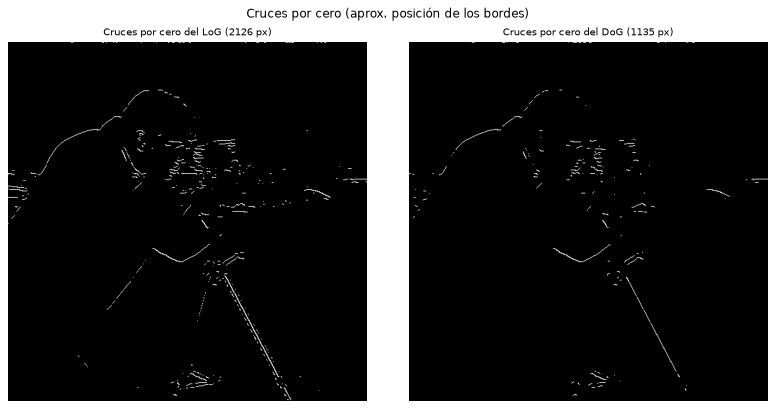

In [20]:
K_LAP4 = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], float)
K_LAP8 = np.array([[1, 1, 1], [1, -8, 1], [1, 1, 1]], float)
SIG = 2.0                                                       # σ1 del LoG/DoG
f = IMG["camara"].astype(np.float64)

lap4_cv = cv2.Laplacian(f, cv2.CV_64F, ksize=1)
lap4 = cv2.filter2D(f, cv2.CV_64F, K_LAP4)
lap8 = cv2.filter2D(f, cv2.CV_64F, K_LAP8)
print(f"cv2.Laplacian(ksize=1) vs filter2D(kernel 4 vecinos): error máx = {np.abs(lap4_cv - lap4).max():.2e}")

suav = cv2.GaussianBlur(f, (0, 0), SIG)                          # (0,0): OpenCV calcula el tamaño de kernel a partir de σ
log4 = cv2.filter2D(suav, cv2.CV_64F, K_LAP4)                    # LoG discreto: Laplaciano 4-vecinos del suavizado
log8 = cv2.filter2D(suav, cv2.CV_64F, K_LAP8)
log_ref = ndi.gaussian_laplace(f, SIG)                           # LoG "analítico" de SciPy (referencia)
dog = cv2.GaussianBlur(f, (0, 0), SIG) - cv2.GaussianBlur(f, (0, 0), 1.6 * SIG)    # σ2 = 1.6·σ1
dog_escalada = -0.6 * SIG ** 2 * log_ref                         # −(k−1)·σ²·LoG con k = 1.6 (signo opuesto por construcción)

df_cmp = pd.DataFrame({
    "correlación con LoG (SciPy)": {"Laplaciano 4 (directo)": corr(lap4, log_ref), "LoG 4 vecinos (σ=2)": corr(log4, log_ref),
                                    "LoG 8 vecinos (σ=2)": corr(log8, log_ref), "DoG (σ1=2, σ2=3.2) [vs −LoG]": corr(dog, -log_ref)},
})
def error_rel_ajustado(a, ref):
    """Error relativo ‖c·a − ref‖/‖ref‖ con la escala c de mínimos cuadrados (ignora diferencias de amplitud)."""
    c = np.vdot(ref, a) / np.vdot(a, a)
    return np.linalg.norm(c * a - ref) / np.linalg.norm(ref)


df_cmp["error relativo tras ajustar escala"] = [error_rel_ajustado(a, log_ref) for a in (lap4, log4, log8, dog)]
display(df_cmp.style.format("{:.4f}"))
print(f"DoG vs −(k−1)σ²·LoG(σ1) con k=1.6: error relativo = {np.linalg.norm(dog - dog_escalada) / np.linalg.norm(dog_escalada):.4f}")
# ¿Con qué σ del LoG se parece más el DoG(σ1=2, σ2=3.2)? (barrido numérico)
sigmas_log = np.round(np.arange(1.2, 3.01, 0.1), 2)
corrs = [corr(dog, -ndi.gaussian_laplace(f, s)) for s in sigmas_log]
mejor_sig = sigmas_log[int(np.argmax(corrs))]
print(f"Mayor correlación DoG–(−LoG) = {max(corrs):.4f} con σ_LoG = {mejor_sig}  (con σ_LoG = σ1 = {SIG}: {corr(dog, -log_ref):.4f})")

def vis_lap(x, p=99):
    lim = np.percentile(np.abs(x), p)
    return np.clip(x, -lim, lim)

cuadricula([img, vis_lap(lap4), vis_lap(lap8), vis_lap(log4), vis_lap(dog), vis_lap(dog - dog_escalada, 100)],
           ["Original", "Laplaciano 4 vecinos\n(sin suavizar)", "Laplaciano 8 vecinos\n(sin suavizar)", f"LoG: Laplaciano 4 de G(σ={SIG})*f",
            f"DoG σ1={SIG}, σ2={1.6*SIG}", "DoG + 0.6σ²·LoG(SciPy)\n(residuo)"], ncols=3, celda=(4.2, 4.3), cmap="gray",
           vmin=None, vmax=None, suptitulo="B.2 – Segunda derivada (gris medio = 0)")

# Cruces por cero: dónde el LoG cambia de signo (posición de los bordes)
def cruces_por_cero(x, umbral):
    s = x > 0
    c = (s != np.roll(s, 1, axis=0)) | (s != np.roll(s, 1, axis=1))
    return c & (np.abs(x - np.roll(x, 1, axis=0)) > umbral)

cz_log = cruces_por_cero(log4, np.percentile(np.abs(log4), 90))
cz_dog = cruces_por_cero(dog, np.percentile(np.abs(dog), 90))
caja5 = np.ones((5, 5), np.uint8)                                  # tolerancia de ±2 px
cerca_dog = cv2.dilate(cz_dog.astype(np.uint8), caja5) > 0
cerca_log = cv2.dilate(cz_log.astype(np.uint8), caja5) > 0
print(f"Cruces por cero: LoG = {cz_log.sum()} px, DoG = {cz_dog.sum()} px")
print(f"  coincidencia exacta píxel a píxel: {100*(cz_log & cz_dog).sum()/cz_log.sum():.1f} % de los del LoG están en el DoG")
print(f"  con tolerancia ±2 px: {100*(cz_log & cerca_dog).sum()/cz_log.sum():.1f} % de los del LoG tienen un cruce del DoG cerca; {100*(cz_dog & cerca_log).sum()/cz_dog.sum():.1f} % de los del DoG tienen uno del LoG cerca")
cuadricula([cz_log * 255.0, cz_dog * 255.0], [f"Cruces por cero del LoG ({cz_log.sum()} px)", f"Cruces por cero del DoG ({cz_dog.sum()} px)"], ncols=2,
           celda=(5, 5), suptitulo="Cruces por cero (aprox. posición de los bordes)")

# **Observaciones (B.2).**
# * `cv2.Laplacian(ksize=1)` y `filter2D` con `[0 1 0;1 -4 1;0 1 0]` son idénticos (error 0).
# * El Laplaciano directo es casi puro ruido/textura fina: su correlación con el LoG (σ=2, SciPy) es solo **0.224**, mientras que el Laplaciano del imagen suavizada (LoG) coincide con la referencia con correlación **0.9996** (4 vecinos) y **0.9994** (8 vecinos). Los dos kernels (4 y 8 vecinos) dan LoG casi iguales; el de 8 vecinos es más isótropo.
# * **DoG vs LoG.** El DoG(σ1=2, σ2=3.2) correlaciona **0.957** con el LoG de σ=2 (con el signo opuesto: DoG ≈ −(k−1)σ²·LoG), y la aproximación $-(k-1)\sigma_1^2\,\mathrm{LoG}$ tiene un error relativo de 0.326, porque $k=1.6$ no es cercano a 1. Barriendo σ del LoG, la mayor correlación es **0.9993 con σ_LoG = 2.5** (≈ 1.25·σ1): el DoG con razón 1.6 equivale a un LoG de escala intermedia entre σ1 y σ2. Con esa σ, las dos respuestas son casi idénticas (también visualmente, columna "residuo").
# * **Cruces por cero** (posición de los bordes): con el mismo percentil de umbral (90) el LoG marca 2126 px y el DoG 1135 px; solo el 47.4 % de los del LoG coinciden píxel a píxel con los del DoG, pero con tolerancia de ±2 px el **99.9 %** de los cruces del DoG tienen uno del LoG cerca (72.2 % en sentido inverso: el LoG, a σ menor, marca además detalles más finos). Es decir, ubican los mismos bordes con distinta finura. El DoG es una alternativa barata al LoG (dos suavizados separables, sin Laplaciano).

# ## B.3 Canny paso a paso
#
# Canny = (1) suavizado Gaussiano (σ), (2) gradiente (Sobel), (3) **supresión de no-máximos** (adelgaza a 1 píxel), (4) **umbral doble con histéresis** (`lower`, `upper`).
# Matriz 3×3: σ de suavizado previo ∈ {1, 2, 3} (filas) × pares de umbrales ∈ {50/150, 100/200, 20/60} (columnas).

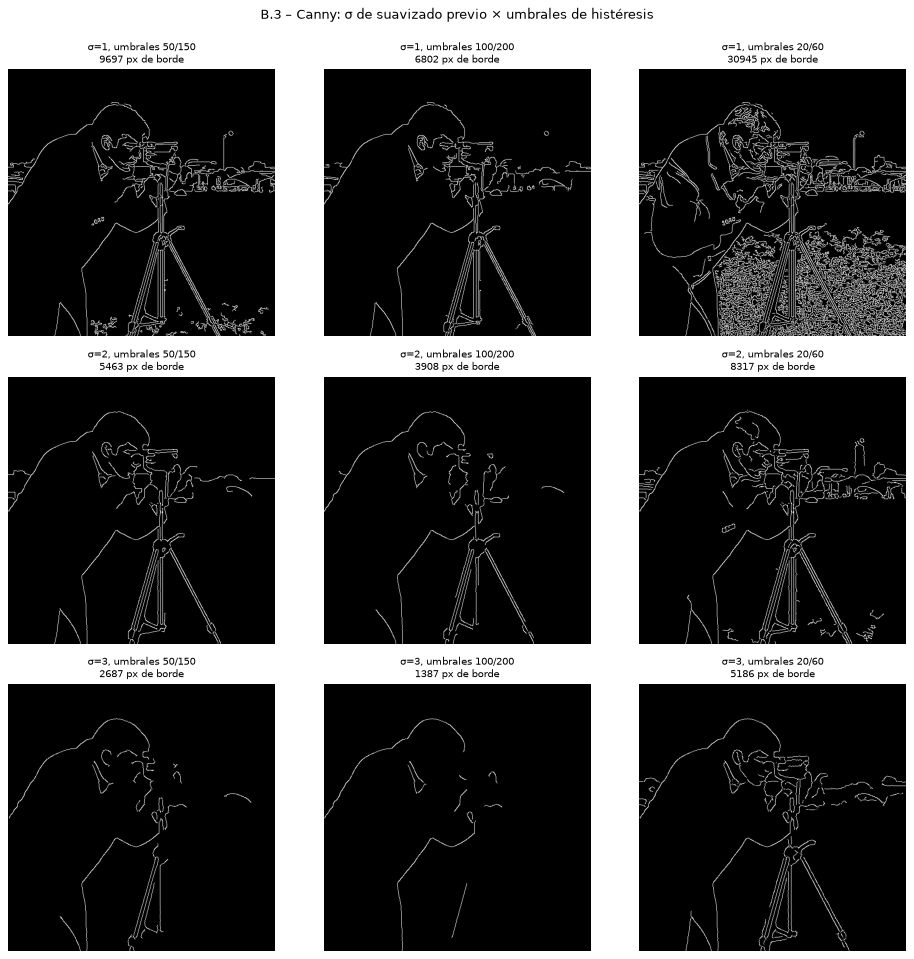

,50/150,100/200,20/60
σ=1,9697,6802,30945
σ=2,5463,3908,8317
σ=3,2687,1387,5186


In [21]:
def canny(img_u8, sigma, lo, hi):
    """Canny con suavizado gaussiano previo explícito (σ) y umbrales de histéresis (lo, hi)."""
    suav = cv2.GaussianBlur(img_u8, (0, 0), sigma)
    return cv2.Canny(suav, lo, hi)


PARES = [(50, 150), (100, 200), (20, 60)]
fig, ejes = plt.subplots(3, 3, figsize=(12, 12))
conteos = {}
for i, s in enumerate((1, 2, 3)):
    for j, (lo, hi) in enumerate(PARES):
        e = canny(img, s, lo, hi)
        conteos[(f"σ={s}", f"{lo}/{hi}")] = int((e > 0).sum())
        ejes[i, j].imshow(e, cmap="gray"); ejes[i, j].axis("off")
        ejes[i, j].set_title(f"σ={s}, umbrales {lo}/{hi}\n{(e > 0).sum()} px de borde")
plt.suptitle("B.3 – Canny: σ de suavizado previo × umbrales de histéresis", y=0.995); plt.tight_layout(); plt.show()
display(pd.Series(conteos).unstack()[[f"{lo}/{hi}" for lo, hi in PARES]].style.format("{:d}").set_caption("Número de píxeles de borde"))

# **Observaciones (matriz 3×3, número de píxeles de borde).**
#
# | | 50/150 | 100/200 | 20/60 |
# |---|---|---|---|
# | σ=1 | 9697 | 6802 | 30945 |
# | σ=2 | 5463 | 3908 | 8317 |
# | σ=3 | 2687 | 1387 | 5186 |
#
# * **σ de suavizado:** al pasar de σ=1 a σ=3 con 100/200 el número de píxeles de borde cae de 6802 a 1387 (−80 %): menos ruido y textura de césped, pero también se pierden bordes finos (trípode, edificios) y los contornos se desplazan.
# * **Umbrales:** con σ=1, los umbrales bajos 20/60 devuelven 30945 píxeles (4.5 veces más que 100/200), es decir, el césped se convierte en bordes; los altos 100/200 son más limpios pero rompen contornos de bajo contraste. 50/150 queda en medio.
# * Un punto razonable para esta imagen es **σ=2 con 50/150 o 100/200** (≈ 4000–5500 px), pero el valor "bueno" depende de la imagen, de ahí la regla automática.

# **Umbrales automáticos con la mediana.** Los umbrales fijos dependen de la exposición de la imagen. Regla propuesta: $\text{lower}=\max(0,(1-s)\,\tilde m)$, $\text{upper}=\min(255,(1+s)\,\tilde m)$, con $\tilde m$ la mediana de la imagen (ya suavizada) y $s\approx0.33$. Se compara con los pares fijos en la imagen original y en versiones sub y sobreexpuestas (generadas con gamma 2.0 y 0.5, ver C.1).

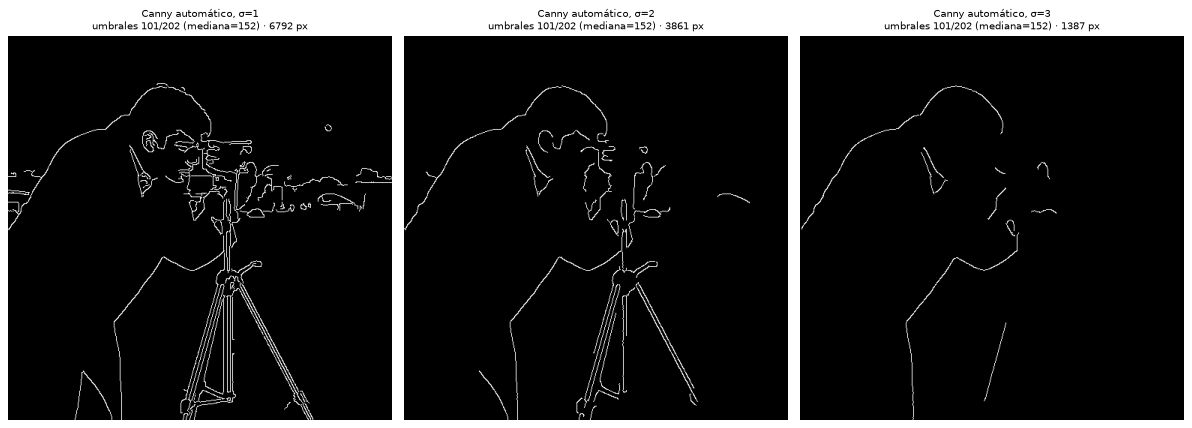

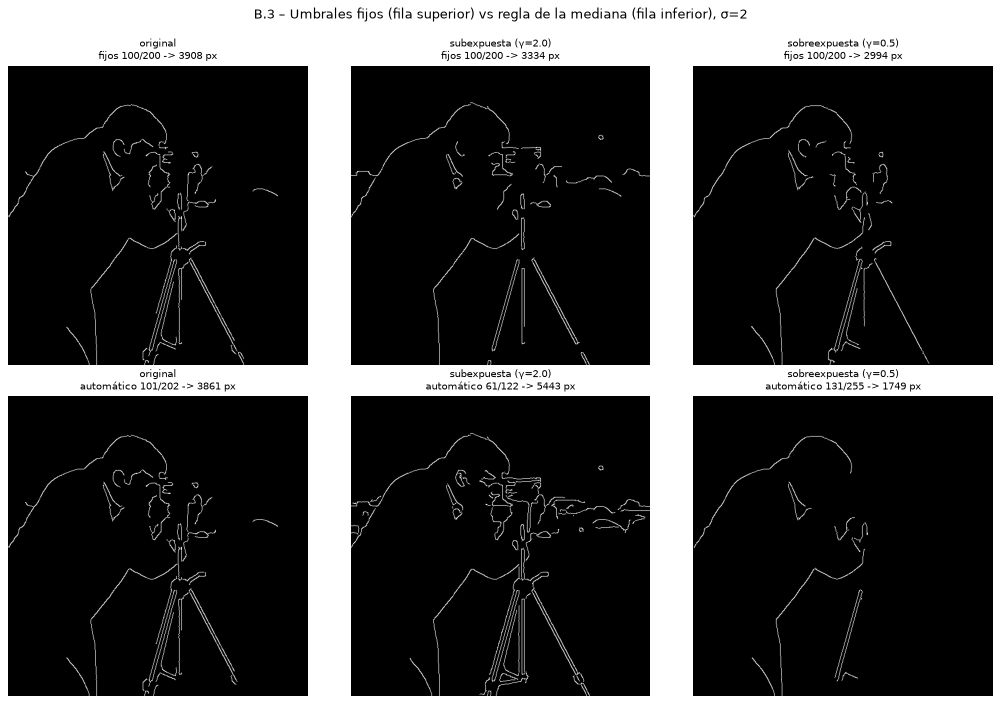

,mediana,umbrales auto,px bordes (100/200),px bordes (auto),F1 vs original (100/200),F1 vs original (auto)
variante,,,,,,
original,152,101/202,3908,3861,0.994,1.000
subexpuesta (γ=2.0),92,61/122,3334,5443,0.779,0.812
sobreexpuesta (γ=0.5),197,131/255,2994,1749,0.860,0.624


In [22]:
def umbrales_mediana(img_u8, s=0.33):
    """Regla automática de umbrales de Canny basada en la mediana."""
    m = np.median(img_u8)
    return int(max(0, (1 - s) * m)), int(min(255, (1 + s) * m))


def canny_auto(img_u8, sigma, s=0.33):
    suav = cv2.GaussianBlur(img_u8, (0, 0), sigma)
    lo, hi = umbrales_mediana(suav, s)
    return cv2.Canny(suav, lo, hi), (lo, hi)


# 1) Automático vs σ
fig, ejes = plt.subplots(1, 3, figsize=(15, 5.2))
for ax, s in zip(ejes, (1, 2, 3)):
    e, (lo, hi) = canny_auto(img, s)
    ax.imshow(e, cmap="gray"); ax.axis("off"); ax.set_title(f"Canny automático, σ={s}\numbrales {lo}/{hi} (mediana={np.median(cv2.GaussianBlur(img,(0,0),s)):.0f}) · {(e>0).sum()} px")
plt.tight_layout(); plt.show()

def concordancia(e, ref, tol=2):
    """Precisión, exhaustividad y F1 de un mapa de bordes e frente a otro ref, con tolerancia de tol píxeles."""
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * tol + 1, 2 * tol + 1))
    cerca_ref, cerca_e = cv2.dilate(ref, k) > 0, cv2.dilate(e, k) > 0
    p = (e > 0)[cerca_ref].sum() / max((e > 0).sum(), 1)
    r = (ref > 0)[cerca_e].sum() / max((ref > 0).sum(), 1)
    return p, r, 2 * p * r / max(p + r, 1e-9)


# 2) Robustez ante cambios de exposición (σ=2). Referencia: bordes de la imagen original con la regla automática.
ref_bordes, _ = canny_auto(img, 2)
variantes = {"original": img, "subexpuesta (γ=2.0)": aplicar_lut(img, lut_gamma(2.0)), "sobreexpuesta (γ=0.5)": aplicar_lut(img, lut_gamma(0.5))}
filas = []
fig, ejes = plt.subplots(2, 3, figsize=(13, 8.8))
for j, (n, im) in enumerate(variantes.items()):
    e_fijo = canny(im, 2, 100, 200)
    e_auto, (lo, hi) = canny_auto(im, 2)
    ejes[0, j].imshow(e_fijo, cmap="gray"); ejes[0, j].set_title(f"{n}\nfijos 100/200 -> {(e_fijo>0).sum()} px"); ejes[0, j].axis("off")
    ejes[1, j].imshow(e_auto, cmap="gray"); ejes[1, j].set_title(f"{n}\nautomático {lo}/{hi} -> {(e_auto>0).sum()} px"); ejes[1, j].axis("off")
    filas.append({"variante": n, "mediana": np.median(cv2.GaussianBlur(im, (0, 0), 2)), "umbrales auto": f"{lo}/{hi}",
                  "px bordes (100/200)": int((e_fijo > 0).sum()), "px bordes (auto)": int((e_auto > 0).sum()),
                  "F1 vs original (100/200)": concordancia(e_fijo, ref_bordes)[2], "F1 vs original (auto)": concordancia(e_auto, ref_bordes)[2]})
plt.suptitle("B.3 – Umbrales fijos (fila superior) vs regla de la mediana (fila inferior), σ=2", y=0.995); plt.tight_layout(); plt.show()
display(pd.DataFrame(filas).set_index("variante").style.format({"mediana": "{:.0f}", "F1 vs original (100/200)": "{:.3f}", "F1 vs original (auto)": "{:.3f}"}))

# **Observaciones (umbrales automáticos).** En la imagen original la regla de la mediana (mediana 152 tras el suavizado) da **101/202**, prácticamente el par fijo 100/200 (3861 vs 3908 píxeles; F1 entre ambos mapas 0.994–1.000), lo que valida que la regla "reproduce" un buen par fijo en una imagen de exposición media. Frente a cambios de exposición (F1 con tolerancia de 2 px respecto de los bordes de la imagen original):
#
# | Variante | Mediana | Umbrales auto | F1 (100/200) | F1 (auto) |
# |---|---|---|---|---|
# | Original | 152 | 101/202 | 0.994 | 1.000 |
# | Subexpuesta (γ=2.0) | 92 | 61/122 | 0.779 | **0.812** |
# | Sobreexpuesta (γ=0.5) | 197 | 131/255 | **0.860** | 0.624 |
#
# La regla adaptativa **mejora** el caso subexpuesto (los umbrales bajan con la mediana y se detectan más bordes: 5443 px frente a 3334), pero **empeora el sobreexpuesto**: la mediana alta (197) sube los umbrales (131/255, con `upper` recortado a 255) cuando en realidad la corrección gamma γ=0.5 *comprime* el contraste en las zonas claras y los gradientes son menores, así que se pierden bordes (1749 px frente a 2994). **Conclusión honesta:** la mediana mide *brillo*, no *contraste*; la regla funciona bien en exposición media y baja, y es débil en imágenes muy claras. Una alternativa sería basar los umbrales en percentiles de la magnitud del gradiente.

# ## B.4 Realce de nitidez: unsharp masking y high-boost
#
# $g=f+k\,(f-f_{\text{suav}})$: se suma al original el "detalle" (la diferencia con una versión suavizada). $k=1$ es *unsharp masking*; $k>1$ es *high-boost*. Equivale a `cv2.addWeighted(f, 1+k, f_suav, -k, 0)`. Se trabaja en `float64` y se recorta a [0,255] al final.

k=0.5: error máx |fórmula − addWeighted| = 5.68e-14 | % píxeles que se recortan (fuera de [0,255]) = 0.95 %
k=1: error máx |fórmula − addWeighted| = 0.00e+00 | % píxeles que se recortan (fuera de [0,255]) = 2.52 %
k=2: error máx |fórmula − addWeighted| = 0.00e+00 | % píxeles que se recortan (fuera de [0,255]) = 5.88 %


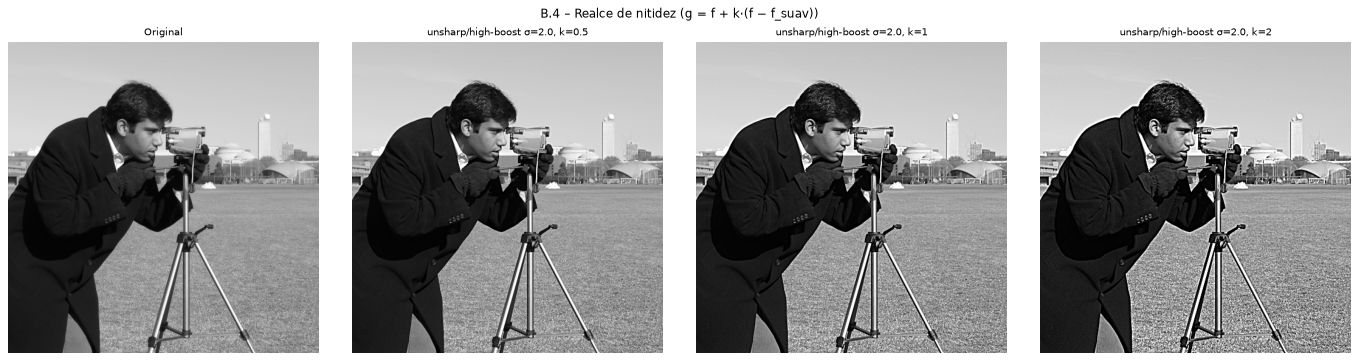

In [23]:
def unsharp_formula(f, sigma, k):
    """g = f + k (f − f_suav) con la fórmula directa (float64, SIN recortar)."""
    return f + k * (f - cv2.GaussianBlur(f, (0, 0), sigma))


def unsharp_addweighted(f, sigma, k):
    """Misma operación con cv2.addWeighted(f, 1+k, f_suav, −k, 0) (float64, SIN recortar)."""
    return cv2.addWeighted(f, 1 + k, cv2.GaussianBlur(f, (0, 0), sigma), -k, 0)


f = IMG["camara"].astype(np.float64)
SIG_U = 2.0
res_unsharp = {}
for k in (0.5, 1, 2):
    a, b = unsharp_formula(f, SIG_U, k), unsharp_addweighted(f, SIG_U, k)
    res_unsharp[k] = a
    print(f"k={k}: error máx |fórmula − addWeighted| = {np.abs(a - b).max():.2e} | % píxeles que se recortan (fuera de [0,255]) = {100*((a<0)|(a>255)).mean():.2f} %")
cuadricula([IMG["camara"]] + [a_u8(res_unsharp[k]) for k in res_unsharp],
           ["Original"] + [f"unsharp/high-boost σ={SIG_U}, k={k}" for k in res_unsharp], ncols=4, celda=(4.3, 4.4),
           suptitulo="B.4 – Realce de nitidez (g = f + k·(f − f_suav))")

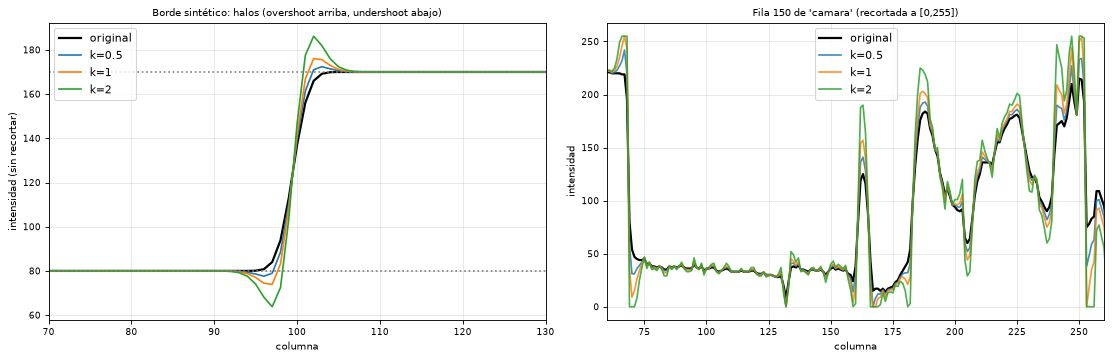

,sobreimpulso (máx − 170),subimpulso (80 − mín),relativo al salto (90)
k,,,
0.500000,2.39,2.39,0.03
1.000000,6.08,6.08,0.07
2.000000,16.19,16.19,0.18


In [24]:
# ---- Perfiles de intensidad: halos (overshoot / undershoot) ----
# (a) Borde sintético suave: escalón 80 -> 170 emborronado con σ=1.5, para ver el efecto sin recorte
x = np.arange(200)
borde = np.tile(np.where(x < 100, 80.0, 170.0), (50, 1))
borde = cv2.GaussianBlur(borde, (0, 0), 1.5)
fila = 25
fig, ejes = plt.subplots(1, 2, figsize=(14, 4.6))
ejes[0].plot(x, borde[fila], "k", lw=2, label="original")
filas = []
for k in (0.5, 1, 2):
    g = unsharp_formula(borde, SIG_U, k)
    ejes[0].plot(x, g[fila], label=f"k={k}")
    filas.append({"k": k, "sobreimpulso (máx − 170)": g[fila].max() - 170, "subimpulso (80 − mín)": 80 - g[fila].min(), "relativo al salto (90)": (g[fila].max() - 170) / 90})
ejes[0].axhline(170, color="gray", ls=":"); ejes[0].axhline(80, color="gray", ls=":")
ejes[0].set_xlim(70, 130); ejes[0].set_xlabel("columna"); ejes[0].set_ylabel("intensidad (sin recortar)")
ejes[0].set_title("Borde sintético: halos (overshoot arriba, undershoot abajo)"); ejes[0].legend(loc="upper left"); ejes[0].grid(alpha=.3)

# (b) Una fila real de 'camara' (tras recortar a [0,255])
fila_r = 150
ejes[1].plot(IMG["camara"][fila_r], "k", lw=2, label="original")
for k in (0.5, 1, 2):
    ejes[1].plot(a_u8(res_unsharp[k])[fila_r].astype(float), label=f"k={k}", alpha=.85)
ejes[1].set_xlim(60, 260); ejes[1].set_xlabel("columna"); ejes[1].set_ylabel("intensidad"); ejes[1].set_title(f"Fila {fila_r} de 'camara' (recortada a [0,255])"); ejes[1].legend(); ejes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
display(pd.DataFrame(filas).set_index("k").style.format("{:.2f}"))

# **Observaciones (B.4).**
# * La fórmula directa y `cv2.addWeighted` coinciden (error máximo 5.7·10⁻¹⁴ para k=0.5 y 0 para k=1 y 2: solo redondeo en coma flotante).
# * **Halos.** El perfil del borde sintético (escalón 80→170, salto de 90 niveles) muestra que el realce *se pasa* de los valores originales: sobreimpulso (overshoot) en el lado claro y subimpulso (undershoot) en el oscuro, de **2.39, 6.08 y 16.19 niveles** para k=0.5, 1, 2 (3 %, 7 % y 18 % del salto). El efecto es simétrico y su ancho es del orden de σ del suavizado.
# * **Por qué aparecen.** $f-f_{\text{suav}}$ (el "detalle") en un borde tiene perfil de segunda derivada: positivo en el lado claro (ahí la imagen supera a su versión suavizada) y negativo en el oscuro. Al sumarlo multiplicado por k, empuja el lado claro hacia arriba y el oscuro hacia abajo, más allá del rango original; el resultado es un contorno más "marcado", pero con una franja clara y otra oscura a cada lado (los halos). Crecen **linealmente con k** y con el contraste del borde.
# * **Recorte.** Con σ=2 se recortan 0.95 %, 2.52 % y 5.88 % de los píxeles (k=0.5, 1, 2): en la fila real de `camara` se ve cómo el resultado satura en 0 y 255 con k=2, perdiendo detalle. Por eso se trabaja en `float64` y se recorta solo al final.
# * **Recomendación:** k≈0.5–1 con σ pequeña (1–2) realza sin halos molestos; k=2 ya muestra artefactos. (Como el realce amplifica el ruido, conviene aplicarlo después de un suavizado/denoising.)

# ## Preguntas del Módulo B
#
# ### Evidencia para la pregunta 1.4 (derivadas y ruido)
# Se miden dos cosas: (i) la **respuesta en frecuencia** de cada operador (sobre el eje $\omega_x$, $\omega_y=0$), y (ii) el efecto sobre una imagen con ruido gaussiano σ=10.

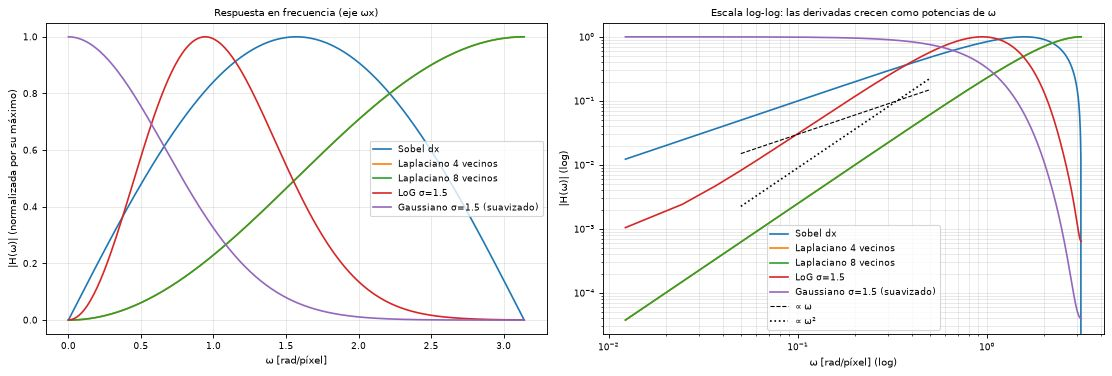

Pendiente log-log de |H| a bajas frecuencias (0.05 < ω < 0.5):
   Sobel dx                :  0.98
   Laplaciano 4 vecinos    :  1.99
   Laplaciano 8 vecinos    :  1.99
   LoG σ=1.5               :  1.86


In [25]:
from skimage.morphology import skeletonize

def respuesta_frecuencia(kernel, N=512):
    """|H(ω)| a lo largo de ωx (ωy=0) para ω ∈ [0, π] rad/píxel, a partir de la FFT del kernel."""
    H = np.fft.fft2(kernel, s=(N, N))
    return np.linspace(0, np.pi, N // 2 + 1), np.abs(H[0, :N // 2 + 1])


impulso = np.zeros((65, 65)); impulso[32, 32] = 1
k_log = ndi.gaussian_laplace(impulso, 1.5)                          # kernel LoG σ=1.5 (por respuesta al impulso)
k_sobel = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], float)
kernels = {"Sobel dx": k_sobel, "Laplaciano 4 vecinos": K_LAP4, "Laplaciano 8 vecinos": K_LAP8, "LoG σ=1.5": k_log,
           "Gaussiano σ=1.5 (suavizado)": cv2.getGaussianKernel(13, 1.5) @ cv2.getGaussianKernel(13, 1.5).T}

fig, ejes = plt.subplots(1, 2, figsize=(14, 4.8))
pendientes = {}
for n, k in kernels.items():
    w, H = respuesta_frecuencia(k)
    ejes[0].plot(w, H / H.max(), label=n)
    m = (w > 0.05) & (w < 0.5)                                        # pendiente log-log a bajas frecuencias
    if n != "Gaussiano σ=1.5 (suavizado)":
        pendientes[n] = np.polyfit(np.log(w[m]), np.log(H[m]), 1)[0]
    ejes[1].loglog(w[1:], H[1:] / H.max(), label=n)
w = np.linspace(0.05, 0.5, 20)
ejes[1].loglog(w, 0.3 * w, "k--", lw=1, label="∝ ω"); ejes[1].loglog(w, 0.9 * w ** 2, "k:", lw=1.5, label="∝ ω²")
ejes[0].set_xlabel("ω [rad/píxel]"); ejes[0].set_ylabel("|H(ω)| (normalizada por su máximo)"); ejes[0].set_title("Respuesta en frecuencia (eje ωx)"); ejes[0].legend(fontsize=8); ejes[0].grid(alpha=.3)
ejes[1].set_xlabel("ω [rad/píxel] (log)"); ejes[1].set_ylabel("|H(ω)| (log)"); ejes[1].set_title("Escala log-log: las derivadas crecen como potencias de ω"); ejes[1].legend(fontsize=8); ejes[1].grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()
print("Pendiente log-log de |H| a bajas frecuencias (0.05 < ω < 0.5):")
for n, p in pendientes.items():
    print(f"   {n:24s}: {p:5.2f}")

,ganancia de ruido blanco (σ_sal/σ_ent),‖R(ruidosa) − R(limpia)‖ / ‖R(limpia)‖,correlación R(limpia) vs R(ruidosa)
Sobel |Gx|+|Gy|,2.964,0.474,0.932
Laplaciano 4,4.475,1.312,0.606
Laplaciano 8,8.496,1.084,0.679
LoG σ=2,0.048,0.193,0.982


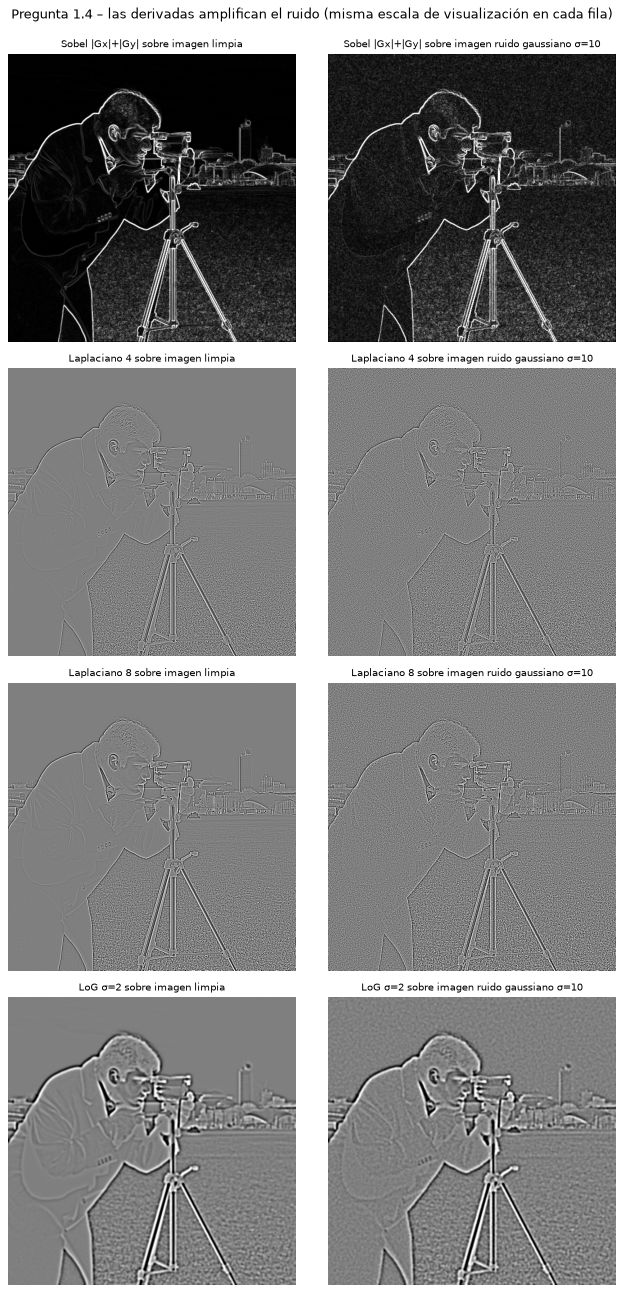

In [26]:
ruido10 = ruidos_camara["Gauss σ=10"]
fl, fr = IMG["camara"].astype(np.float64), ruido10.astype(np.float64)

def resp(f, operador):
    if operador == "Sobel |Gx|+|Gy|": return np.abs(cv2.Sobel(f, cv2.CV_64F, 1, 0)) + np.abs(cv2.Sobel(f, cv2.CV_64F, 0, 1))
    if operador == "Laplaciano 4": return cv2.filter2D(f, cv2.CV_64F, K_LAP4)
    if operador == "Laplaciano 8": return cv2.filter2D(f, cv2.CV_64F, K_LAP8)
    if operador == "LoG σ=2": return cv2.filter2D(cv2.GaussianBlur(f, (0, 0), 2.0), cv2.CV_64F, K_LAP4)

ops = ["Sobel |Gx|+|Gy|", "Laplaciano 4", "Laplaciano 8", "LoG σ=2"]
ruido_blanco = np.random.default_rng(SEMILLA).normal(0, 10, (512, 512))
filas = {}
for op in ops:
    r_l, r_r = resp(fl, op), resp(fr, op)
    sig_ruido = (resp(ruido_blanco, op) if op.startswith(("Lap", "LoG")) else resp(ruido_blanco, op)).std() / 10
    comp = np.linalg.norm((r_r - r_l)) / np.linalg.norm(r_l - r_l.mean())
    filas[op] = {"ganancia de ruido blanco (σ_sal/σ_ent)": sig_ruido, "‖R(ruidosa) − R(limpia)‖ / ‖R(limpia)‖": comp,
                 "correlación R(limpia) vs R(ruidosa)": corr(r_l, r_r)}
display(pd.DataFrame(filas).T.style.format("{:.3f}"))

fig, ejes = plt.subplots(4, 2, figsize=(8.4, 16.2))
for i, op in enumerate(ops):
    for j, (n, f_) in enumerate((("limpia", fl), ("ruido gaussiano σ=10", fr))):
        r = resp(f_, op)
        if op.startswith("Sobel"):
            ejes[i, j].imshow(r, cmap="gray", vmin=0, vmax=np.percentile(resp(fl, op), 99))
        else:
            lim = np.percentile(np.abs(resp(fl, op)), 99); ejes[i, j].imshow(r, cmap="gray", vmin=-lim, vmax=lim)
        ejes[i, j].set_title(f"{op} sobre imagen {n}"); ejes[i, j].axis("off")
plt.suptitle("Pregunta 1.4 – las derivadas amplifican el ruido (misma escala de visualización en cada fila)", y=0.995); plt.tight_layout(); plt.show()

# ### Pregunta 1.4 – ¿Por qué las derivadas amplifican el ruido? ¿Por qué el Laplaciano es más sensible que Sobel? ¿Cómo lo resuelve el LoG?
#
# **Dominio de la frecuencia.** Derivar es multiplicar el espectro por $j\omega$: $\mathcal F\{\partial f/\partial x\}=j\omega_x F(\omega)$, y derivar dos veces por $-\omega^2$ ($\mathcal F\{\nabla^2 f\}=-(\omega_x^2+\omega_y^2)F$). La respuesta crece **linealmente (primera derivada)** o **cuadráticamente (segunda)** con la frecuencia. Las imágenes naturales tienen espectro que *decae* con $\omega$, pero el ruido es aproximadamente blanco (espectro plano, con energía en todas las frecuencias altas): el derivador deja casi igual lo poco que hay de señal a alta frecuencia y **multiplica por $\omega$ o $\omega^2$ el ruido**, así que la relación señal/ruido empeora justo donde se mide el borde.
#
# **Evidencia.** (i) En la figura log-log, la pendiente ajustada a bajas frecuencias (0.05 < ω < 0.5 rad/píxel) es **0.98 para Sobel** (≈ ω) y **1.99 para ambos Laplacianos** (≈ ω²); el LoG σ=1.5 da 1.86 porque su Gaussiano ya empieza a atenuar dentro de ese rango. Los kernels discretos se aplanan cerca de ω=π porque el muestreo acota la derivada. (ii) Al aplicar los operadores a ruido blanco de σ=10, la desviación de salida es 2.96 veces σ para Sobel, **4.48 para el Laplaciano de 4 vecinos y 8.50 para el de 8 vecinos**, pero solo **0.048 para el LoG σ=2** (≈ 90 veces menos que el Laplaciano 4). (iii) Sobre la imagen `camara` con ruido σ=10, la fracción ruido/señal en la respuesta, ‖R(ruidosa)−R(limpia)‖/‖R(limpia)‖, es **1.31 (Laplaciano 4), 1.08 (Laplaciano 8), 0.47 (Sobel) y 0.19 (LoG σ=2)**; la correlación entre la respuesta limpia y la ruidosa baja a 0.61 (Lap. 4) y 0.68 (Lap. 8) frente a 0.93 de Sobel y 0.98 del LoG. En la figura, el Laplaciano de la imagen ruidosa queda cubierto de "sal y pimienta" que casi oculta los bordes (el ruido supera a la señal: cociente > 1), mientras que Sobel y el LoG conservan los contornos.
#
# **Por qué el Laplaciano es más sensible que Sobel.** (a) Crece como $\omega^2$ en vez de $\omega$. (b) Sobel es en realidad *derivada × suavizado*: $[−1\,0\,1]^T\!\otimes[1\,2\,1]$ incorpora un paso bajo en la dirección ortogonal; el Laplaciano 4/8 vecinos no suaviza nada (su peso central −4/−8 frente a vecinos 1 da una ganancia de ruido blanco de 4.48 y 8.50 frente a 2.96 de Sobel). (c) La señal de una segunda derivada en un borde suave es pequeña (cambia de signo), así que el cociente ruido/señal es peor.
#
# **LoG.** Se resuelve anteponiendo un **suavizado gaussiano**: $\nabla^2(G_\sigma*f)$. En frecuencia, la respuesta es $-\omega^2\,e^{-\sigma^2\omega^2/2}$: sube como $\omega^2$ a bajas frecuencias pero el Gaussiano la **tira a cero** a altas frecuencias, formando un *pasa-banda* (curva "LoG" de la primera figura, con un máximo y luego caída). La banda se controla con σ: más σ → menos ruido pero bordes más gruesos/menos localizados. En la tabla, LoG σ=2 baja el cociente ruido/señal de 1.31 (Laplaciano 4 directo) a 0.19 y la ganancia de ruido blanco de 4.48 a 0.048.

# ### Evidencia para la pregunta 1.5 (Canny: dos umbrales, NMS e histéresis)
# Se compara, sobre la misma imagen suavizada (σ=2) y con los umbrales automáticos de B.3, un umbral único (alto o bajo) frente a la histéresis, y la **supresión de no-máximos** frente a un simple umbral sobre la magnitud del gradiente.

Umbrales automáticos (regla de la mediana, σ=2): lower=101, upper=202


,píxeles de borde,componentes conexas,tamaño medio de componente [px],componente mayor [px],grosor (px / px de esqueleto)
"|∇f| > upper (202) [sin NMS, umbral único alto]",5384,69,78.0,1101,3.38
"|∇f| > lower (101) [sin NMS, umbral único bajo]",18682,87,214.7,7173,4.52
"Canny lower=upper=202 [NMS, umbral único alto]",2211,73,30.3,326,1.34
"Canny lower=upper=101 [NMS, umbral único bajo]",5086,163,31.2,439,1.25
Canny histéresis 101/202 [NMS + 2 umbrales],3861,41,94.2,439,1.26


Píxeles de Canny con |∇f| < upper (salvados por la histéresis al estar conectados a un píxel fuerte): 1623 de 3861 (42.0 %)


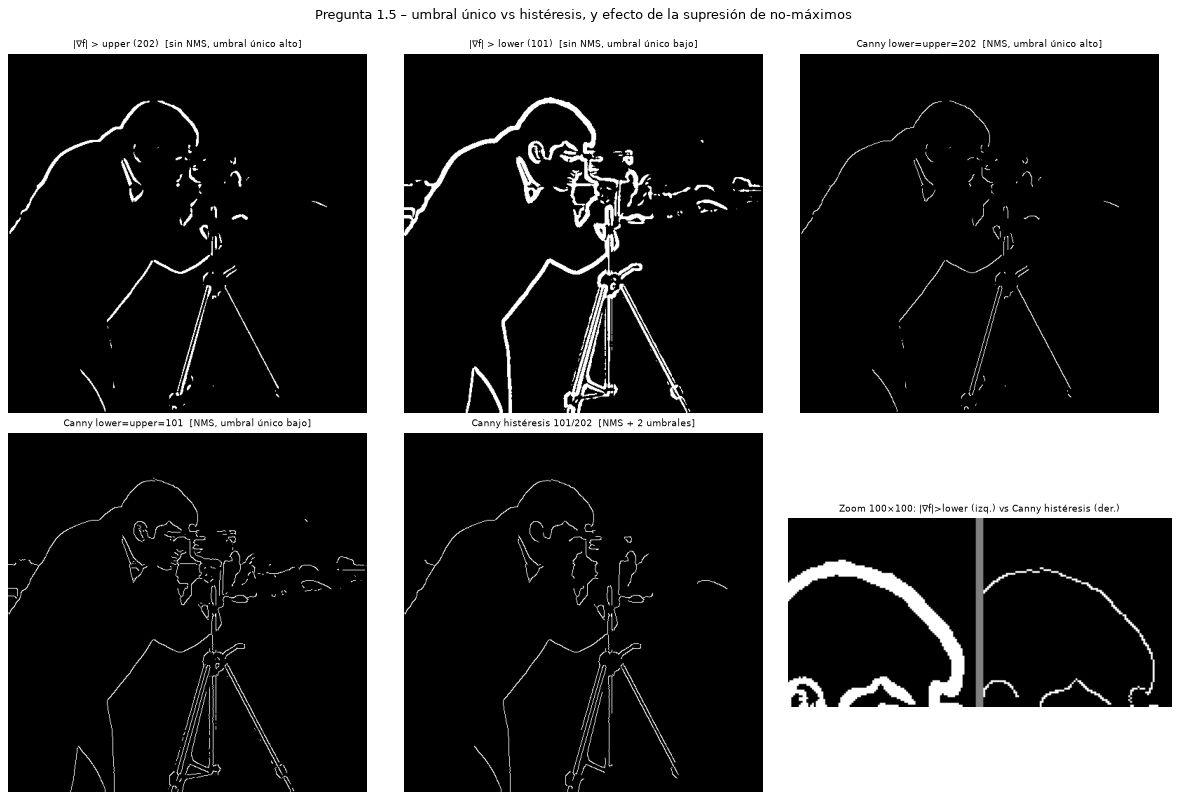

In [27]:
suav = cv2.GaussianBlur(img, (0, 0), 2)
gx_ = cv2.Sobel(suav.astype(np.float64), cv2.CV_64F, 1, 0, ksize=3); gy_ = cv2.Sobel(suav.astype(np.float64), cv2.CV_64F, 0, 1, ksize=3)
mag_l1 = np.abs(gx_) + np.abs(gy_)                                    # misma norma que usa cv2.Canny por defecto (L2gradient=False)
lo, hi = umbrales_mediana(suav)
print(f"Umbrales automáticos (regla de la mediana, σ=2): lower={lo}, upper={hi}")

mapas = {
    f"|∇f| > upper ({hi})  [sin NMS, umbral único alto]": (mag_l1 > hi).astype(np.uint8) * 255,
    f"|∇f| > lower ({lo})  [sin NMS, umbral único bajo]": (mag_l1 > lo).astype(np.uint8) * 255,
    f"Canny lower=upper={hi}  [NMS, umbral único alto]": cv2.Canny(suav, hi, hi),
    f"Canny lower=upper={lo}  [NMS, umbral único bajo]": cv2.Canny(suav, lo, lo),
    f"Canny histéresis {lo}/{hi}  [NMS + 2 umbrales]": cv2.Canny(suav, lo, hi),
}
filas = {}
for n, e in mapas.items():
    b = e > 0
    n_comp, _, stats, _ = cv2.connectedComponentsWithStats(b.astype(np.uint8), connectivity=8)
    tam = stats[1:, cv2.CC_STAT_AREA]
    filas[n] = {"píxeles de borde": int(b.sum()), "componentes conexas": n_comp - 1,
                "tamaño medio de componente [px]": tam.mean(), "componente mayor [px]": tam.max(),
                "grosor (px / px de esqueleto)": b.sum() / max(skeletonize(b).sum(), 1)}
df_can = pd.DataFrame(filas).T
display(df_can.style.format({"píxeles de borde": "{:.0f}", "componentes conexas": "{:.0f}", "tamaño medio de componente [px]": "{:.1f}", "componente mayor [px]": "{:.0f}", "grosor (px / px de esqueleto)": "{:.2f}"}))

e_h = cv2.Canny(suav, lo, hi) > 0
debil = e_h & (mag_l1 < hi)
print(f"Píxeles de Canny con |∇f| < upper (salvados por la histéresis al estar conectados a un píxel fuerte): {debil.sum()} de {e_h.sum()} ({100*debil.sum()/e_h.sum():.1f} %)")

fig, ejes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (n, e) in zip(ejes.ravel(), mapas.items()):
    ax.imshow(e, cmap="gray"); ax.set_title(n, fontsize=8); ax.axis("off")
z = (slice(40, 140), slice(180, 280))
ejes.ravel()[5].imshow(np.hstack([mapas[list(mapas)[1]][z], np.full((100, 4), 128, np.uint8), mapas[list(mapas)[4]][z]]), cmap="gray")
ejes.ravel()[5].set_title("Zoom 100×100: |∇f|>lower (izq.) vs Canny histéresis (der.)", fontsize=8); ejes.ravel()[5].axis("off")
plt.suptitle("Pregunta 1.5 – umbral único vs histéresis, y efecto de la supresión de no-máximos", y=0.995); plt.tight_layout(); plt.show()

# ### Pregunta 1.5 – ¿Por qué Canny usa dos umbrales? ¿Qué aportan la supresión de no-máximos y la histéresis?
#
# **El problema de un solo umbral.** Un umbral alto garantiza que lo detectado son bordes reales, pero un contorno cuya intensidad de gradiente fluctúa a lo largo de su longitud queda **cortado en trozos** (pérdida de continuidad). Un umbral bajo recupera los trozos débiles pero **admite ruido y texturas** (muchos falsos positivos). Con dos umbrales, `upper` decide *dónde hay un borde seguro* y `lower` *hasta dónde se puede prolongar*.
#
# **Seguimiento por histéresis.** Se aceptan los píxeles con gradiente $\ge$ `upper` como semillas y se añaden los píxeles con gradiente entre `lower` y `upper` **solo si están conectados (8-vecindad) a una semilla**; los débiles aislados se descartan. Así se prolongan los contornos por zonas de gradiente débil sin aceptar ruido suelto. Evidencia (tabla de arriba, umbrales automáticos 101/202): con el umbral único alto (`Canny lower=upper=202`) quedan 2211 píxeles repartidos en **73 componentes de 30 px de media** (contornos rotos); con el umbral único bajo (101) se obtienen 5086 píxeles en **163 componentes** (se añade ruido y textura del césped); la histéresis 101/202 da 3861 píxeles en solo **41 componentes de 94 px de media**: menos fragmentos y más largos. Además, **1623 de los 3861 píxeles (42.0 %)** de la salida de Canny tienen un gradiente menor que `upper`: son tramos débiles salvados únicamente por estar conectados a un píxel fuerte.
#
# **Supresión de no-máximos (NMS).** Un borde real produce una "cresta" de varios píxeles de ancho en $|\nabla f|$ (porque el suavizado y la derivada lo ensanchan). La NMS conserva únicamente los píxeles que son máximos locales **a lo largo de la dirección del gradiente** y descarta los demás: el borde queda de **1 píxel de grosor** y bien localizado. Evidencia: el simple umbral sobre $|\nabla f|$ produce bordes de **3.38 px** de grosor medio (umbral alto) y **4.52 px** (umbral bajo) por cada píxel de esqueleto, frente a **1.25–1.34 px** de las filas que usan NMS (los `Canny`). Sin NMS no tiene sentido hablar de *seguimiento* de un contorno, porque la "conectividad" de una banda gruesa no representa a la curva.
#
# **Resumen:** NMS da **localización** (adelgazamiento), histéresis da **continuidad** sin sacrificar la **robustez** al ruido; los tres criterios de Canny (buena detección, buena localización, una única respuesta por borde) se logran con suavizado + NMS + doble umbral.

# ---
# # Módulo C – Transformaciones de intensidad (4 %)
#
# Una transformación de intensidad es una función punto a punto $s=T(r)$. Como solo depende del valor del píxel (no de su vecindad), se implementa de forma eficiente con una **tabla de búsqueda** (*look-up table*, LUT) de 256 entradas aplicada con `cv2.LUT`. Con $L=256$ y $r$ normalizado a $[0,1]$ cuando hace falta:
# * Negativo: $s=(L-1)-r$.
# * Logarítmica: $s=c\,\log(1+r)$, con $c=255/\log(256)$ (así $s(255)=255$).
# * Gamma: $s=255\,(r/255)^{\gamma}$ (γ=0.3, 0.5, 1.5, 2.5). γ<1 aclara (expande oscuros), γ>1 oscurece (expande claros).
# * Estiramiento de contraste lineal con percentiles 2 %–98 %.
#
# ## C.1 Curvas de transferencia y su efecto
#
# Las LUT ya están definidas en las funciones auxiliares (`lut_negativo`, `lut_log`, `lut_gamma`, `lut_estiramiento`).

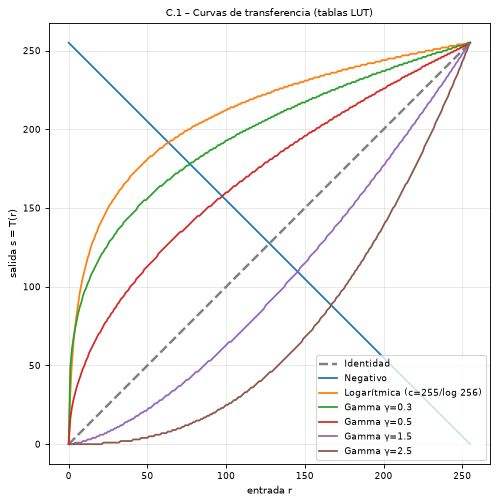

Error máx LUT vs fórmula (en niveles; el redondeo a uint8 da ≤ 0.5): negativo=0.00, log=0.50, gamma 0.5=0.50


In [28]:
curvas = {"Identidad": np.arange(L, dtype=np.uint8), "Negativo": lut_negativo(), "Logarítmica (c=255/log 256)": lut_log()}
for g in (0.3, 0.5, 1.5, 2.5):
    curvas[f"Gamma γ={g}"] = lut_gamma(g)

plt.figure(figsize=(7.2, 6.4))
for n, lut in curvas.items():
    plt.plot(np.arange(L), lut, label=n, lw=2.2 if n == "Identidad" else 1.6, ls="--" if n == "Identidad" else "-", color="gray" if n == "Identidad" else None)
plt.xlabel("entrada r"); plt.ylabel("salida s = T(r)"); plt.title("C.1 – Curvas de transferencia (tablas LUT)")
plt.legend(fontsize=8); plt.grid(alpha=.3); plt.gca().set_aspect("equal", adjustable="box"); plt.tight_layout(); plt.show()

# Comprobación: las LUT coinciden con la fórmula analítica
r = np.arange(L, dtype=np.float64)
print("Error máx LUT vs fórmula (en niveles; el redondeo a uint8 da ≤ 0.5):",
      f"negativo={np.abs(lut_negativo() - (255 - r)).max():.2f},",
      f"log={np.abs(lut_log() - 255 / np.log(256) * np.log1p(r)).max():.2f},",
      f"gamma 0.5={np.abs(lut_gamma(0.5) - 255 * (r / 255) ** 0.5).max():.2f}")

# **Imágenes sub y sobreexpuestas (sintéticas).** No se dispone de fotografías reales mal expuestas, así que se **generan artificialmente** a partir de `camara` con una corrección gamma: **subexpuesta** con γ=2.5 y **sobreexpuesta** con γ=0.4. Es una simulación, no una captura real, y se declara así a propósito. Sobre cada una se aplican todas las transformaciones (rejilla imagen + histograma) y el estiramiento con percentiles 2–98 %.

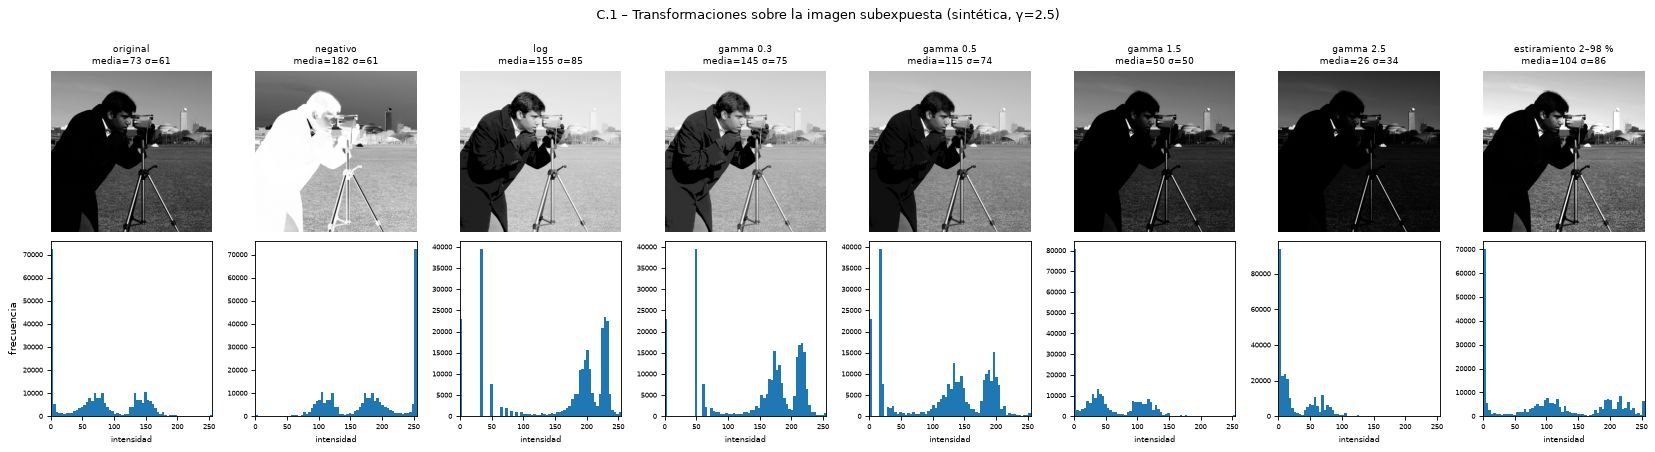

=== subexpuesta (sintética, γ=2.5): percentiles de la entrada p2=0, p98=178 ===


,media,desv. est. (contraste),entropía [bits],p2,p98,% píxeles saturados (0 ó 255)
original,73.15,60.94,6.17,0.00,178.00,8.86
negativo,181.85,60.94,6.17,77.00,255.00,8.86
log,154.91,85.44,5.72,0.00,239.00,8.97
gamma 0.3,144.58,74.94,5.91,0.00,229.00,8.86
gamma 0.5,115.06,73.63,6.06,0.00,213.00,8.86
gamma 1.5,49.98,49.68,5.51,0.00,149.00,27.65
gamma 2.5,25.98,34.32,4.89,0.00,104.00,31.64
estiramiento 2–98 %,103.93,85.67,6.07,0.00,255.00,10.90


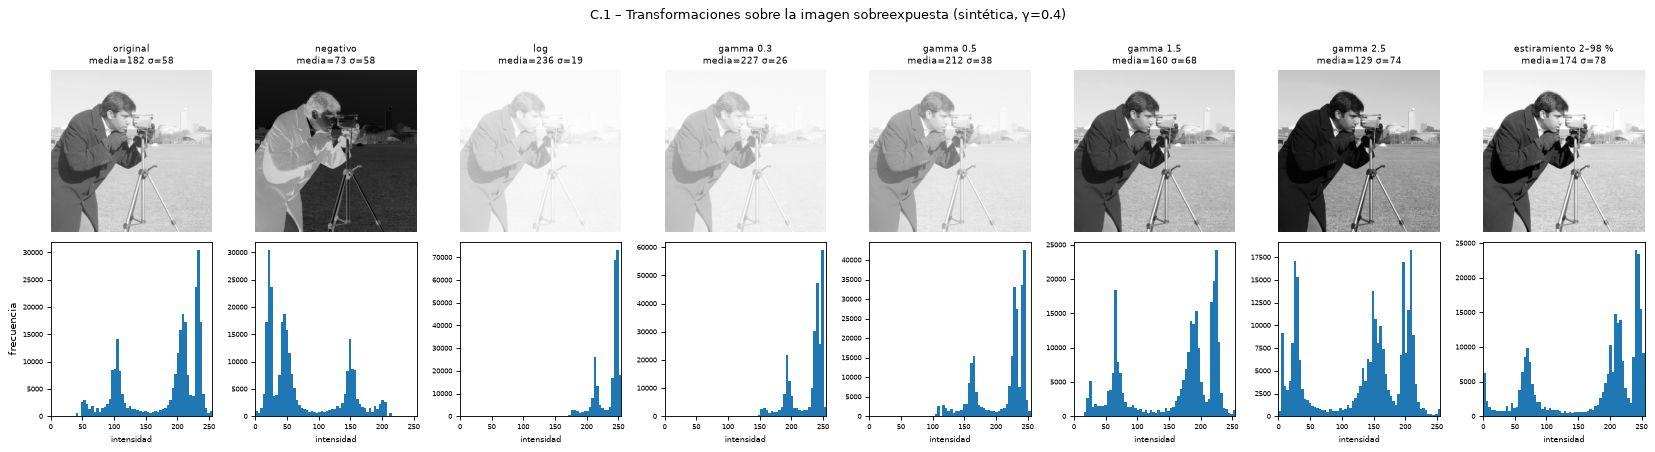

=== sobreexpuesta (sintética, γ=0.4): percentiles de la entrada p2=53, p98=241 ===


,media,desv. est. (contraste),entropía [bits],p2,p98,% píxeles saturados (0 ó 255)
original,181.66,57.96,6.53,53.00,241.00,0.22
negativo,73.34,57.96,6.53,14.00,202.00,0.22
log,236.23,18.76,4.87,183.00,252.00,0.36
gamma 0.3,227.15,25.92,5.33,159.00,251.00,0.29
gamma 0.5,211.80,38.29,5.88,116.00,248.00,0.22
gamma 1.5,159.54,67.81,6.53,24.00,234.00,0.22
gamma 2.5,129.04,73.64,6.53,5.00,221.00,0.22
estiramiento 2–98 %,174.49,78.26,6.42,0.00,255.00,4.52


Estiramiento: cv2.normalize vs LUT, diferencia máxima = 1 nivel(es)


In [29]:
base = IMG["camara"]
EXPO = {"subexpuesta (sintética, γ=2.5)": aplicar_lut(base, lut_gamma(2.5)),
        "sobreexpuesta (sintética, γ=0.4)": aplicar_lut(base, lut_gamma(0.4))}


def entropia(im):
    return measure.shannon_entropy(im)          # entropía de Shannon del histograma (bits/píxel)


def variantes_intensidad(im):
    """Todas las transformaciones del módulo aplicadas a im (dict nombre -> imagen uint8)."""
    v = {"original": im, "negativo": aplicar_lut(im, lut_negativo()), "log": aplicar_lut(im, lut_log())}
    for g in (0.3, 0.5, 1.5, 2.5):
        v[f"gamma {g}"] = aplicar_lut(im, lut_gamma(g))
    v["estiramiento 2–98 %"] = aplicar_lut(im, lut_estiramiento(im, 2, 98))
    return v


TABLAS_C = {}
for nombre, im in EXPO.items():
    vs = variantes_intensidad(im)
    fig, ejes = plt.subplots(2, len(vs), figsize=(2.6 * len(vs), 5.6))
    for j, (n, v) in enumerate(vs.items()):
        ejes[0, j].imshow(v, cmap="gray", vmin=0, vmax=255); ejes[0, j].set_title(f"{n}\nmedia={v.mean():.0f} σ={v.std():.0f}", fontsize=8); ejes[0, j].axis("off")
        ejes[1, j].hist(v.ravel(), bins=64, range=(0, 255), color="tab:blue"); ejes[1, j].set_xlim(0, 255); ejes[1, j].set_xlabel("intensidad", fontsize=7)
        ejes[1, j].tick_params(labelsize=6)
    ejes[1, 0].set_ylabel("frecuencia")
    plt.suptitle(f"C.1 – Transformaciones sobre la imagen {nombre}", y=1.0); plt.tight_layout(); plt.show()
    p2, p98 = np.percentile(im, [2, 98])
    TABLAS_C[nombre] = pd.DataFrame({n: {"media": v.mean(), "desv. est. (contraste)": v.std(), "entropía [bits]": entropia(v),
                                         "p2": np.percentile(v, 2), "p98": np.percentile(v, 98),
                                         "% píxeles saturados (0 ó 255)": 100 * ((v == 0) | (v == 255)).mean()} for n, v in vs.items()}).T
    print(f"=== {nombre}: percentiles de la entrada p2={p2:.0f}, p98={p98:.0f} ===")
    display(TABLAS_C[nombre].style.format("{:.2f}").highlight_max(subset=["desv. est. (contraste)", "entropía [bits]"], color="#b7e4c7"))

# Estiramiento con cv2.normalize equivale a la LUT lineal (se recorta antes a [p2, p98])
im = EXPO["subexpuesta (sintética, γ=2.5)"]
p2, p98 = np.percentile(im, [2, 98])
est_cv = cv2.normalize(np.clip(im, p2, p98).astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
print(f"Estiramiento: cv2.normalize vs LUT, diferencia máxima = {np.abs(est_cv.astype(int) - aplicar_lut(im, lut_estiramiento(im)).astype(int)).max()} nivel(es)")

# **Observaciones (C.1).** Cifras de las tablas anteriores (`camara` simulada con gamma; el original ya tiene 8.9 % de píxeles en 0 por el abrigo negro).
# * **Subexpuesta** (media 73.2, σ=60.9, p98=178): las transformaciones que *expanden los oscuros* suben el brillo y el contraste: la **log** lleva la media a 154.9 y σ a 85.4; γ=0.5 a 115.1 y σ=73.6; γ=0.3 a 144.6 y σ=74.9. El **estiramiento 2–98 %** logra el mayor contraste (σ=85.7) con media 103.9 y una entropía de 6.07 bits (6.17 el original) sin tener que elegir γ. El negativo mantiene σ y entropía (6.17 bits: es una permutación de niveles) pero invierte la imagen, y γ>1 la empeora (γ=2.5: media 26.0, σ=34.3, **31.6 % de píxeles en 0 ó 255**, entropía 4.89 bits: se pierde información, p. ej. detalles del abrigo).
# * **Sobreexpuesta** (media 181.7, σ=58.0, p2=53): al revés, ayudan γ>1 (γ=1.5: media 159.5, σ=67.8; γ=2.5: media 129.0, σ=73.6) y el estiramiento (σ=78.3, media 174.5), mientras que **log y γ<1 la empeoran**: la log deja σ=18.8 y la media en 236.2 (la imagen casi blanca, entropía 4.87 bits).
# * Las LUT inyectivas (γ>1 en la sobreexpuesta, γ<1 en la subexpuesta) **conservan la entropía** (6.53 bits en la sobreexpuesta con γ=1.5 y 2.5): cambiar la curva reubica los niveles pero no crea información; la entropía solo baja cuando varios niveles se funden (log en la sobreexpuesta, estiramiento con recorte).
# * El estiramiento por percentiles recorta el 2 % inferior y superior (la columna "% saturados" sube de 8.86 % a 10.90 % en la subexpuesta y de 0.22 % a 4.52 % en la sobreexpuesta) a cambio de aprovechar los 256 niveles; es la opción por defecto cuando no se conoce el tipo de error de exposición. `cv2.normalize` (tras recortar a [p2,p98]) produce lo mismo que la LUT con una diferencia máxima de 1 nivel (redondeo).
# * Los histogramas del estiramiento muestran el efecto "peine" (huecos regulares): las transformaciones puntuales no crean niveles nuevos.

# ## C.2 Visualización del espectro: transformación logarítmica
#
# La magnitud de la FFT de una imagen tiene un rango dinámico gigantesco (la componente DC es la suma de todos los píxeles, mientras que las altas frecuencias son varios órdenes de magnitud menores). Mostrada en escala lineal solo se ve un punto en el centro. La función `espectro_log(F)` aplica $\log(1+|F|)$ y normaliza a [0,1]; se reutiliza en el Módulo D.

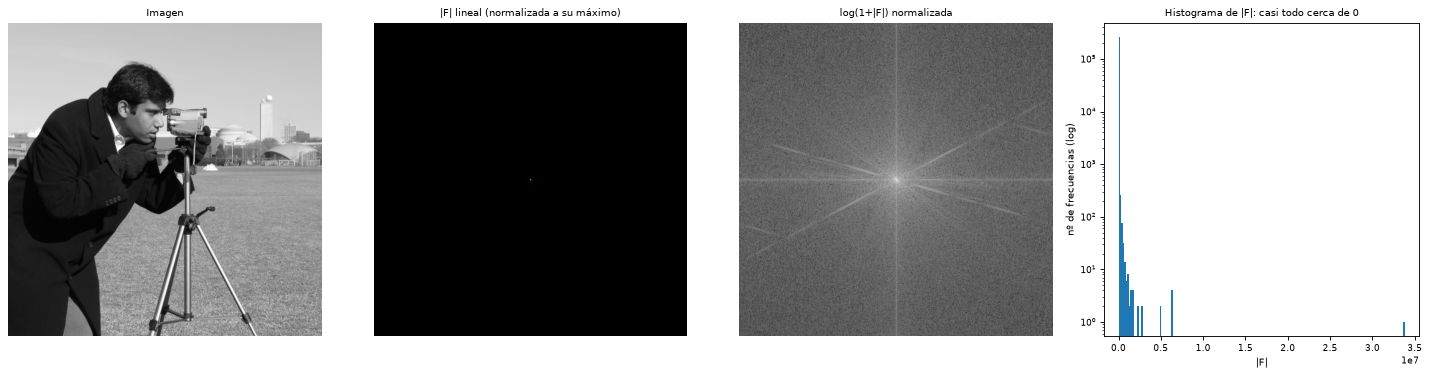

|F| máximo (componente DC) = 3.383e+07 (= suma de píxeles = 3.383e+07)
|F| mediana = 3.695e+03 | cociente máx/mediana = 9156
Rango dinámico de |F|: 130 dB
% de frecuencias con |F| < 1/255 del máximo (se verían NEGRAS en 8 bits, escala lineal): 99.13 %
% de frecuencias que se ven negras (valor 0 en 8 bits) con log(1+|F|):                  0.00 %
% de frecuencias con valor > 50 de 255 (se distinguen del fondo): lineal 0.000 % | log 99.69 %


In [30]:
def espectro_log(F, normalizar=True):
    """Magnitud logarítmica del espectro: log(1+|F|). F es un espectro COMPLEJO ya centrado (np.fft.fftshift).
    Con normalizar=True el resultado se escala a [0,1] para mostrarlo con imshow."""
    M = np.log1p(np.abs(F))
    return norm01(M) if normalizar else M


def fft_centrada(img):
    """FFT 2D (float64) con el origen en el centro del espectro."""
    return np.fft.fftshift(np.fft.fft2(img.astype(np.float64)))


F = fft_centrada(IMG["camara"])
mag = np.abs(F)
lineal = mag / mag.max()                         # visualización sin escalar (solo normalizada)
logv = espectro_log(F)
lineal_u8, log_u8 = a_u8(255 * lineal), a_u8(255 * logv)

fig, ejes = plt.subplots(1, 4, figsize=(18, 4.8))
ejes[0].imshow(IMG["camara"], cmap="gray"); ejes[0].set_title("Imagen"); ejes[0].axis("off")
ejes[1].imshow(lineal, cmap="gray"); ejes[1].set_title("|F| lineal (normalizada a su máximo)"); ejes[1].axis("off")
ejes[2].imshow(logv, cmap="gray"); ejes[2].set_title("log(1+|F|) normalizada"); ejes[2].axis("off")
ejes[3].hist(mag.ravel(), bins=200, log=True, color="tab:blue"); ejes[3].set_xlabel("|F|"); ejes[3].set_ylabel("nº de frecuencias (log)"); ejes[3].set_title("Histograma de |F|: casi todo cerca de 0")
plt.tight_layout(); plt.show()

centro = (mag.shape[0] // 2, mag.shape[1] // 2)
print(f"|F| máximo (componente DC) = {mag.max():.3e} (= suma de píxeles = {IMG['camara'].astype(np.float64).sum():.3e})")
print(f"|F| mediana = {np.median(mag):.3e} | cociente máx/mediana = {mag.max() / np.median(mag):.0f}")
print(f"Rango dinámico de |F|: {20 * np.log10(mag.max() / mag.min()):.0f} dB")
print(f"% de frecuencias con |F| < 1/255 del máximo (se verían NEGRAS en 8 bits, escala lineal): {100 * (lineal_u8 == 0).mean():.2f} %")
print(f"% de frecuencias que se ven negras (valor 0 en 8 bits) con log(1+|F|):                  {100 * (log_u8 == 0).mean():.2f} %")
print(f"% de frecuencias con valor > 50 de 255 (se distinguen del fondo): lineal {100 * (lineal_u8 > 50).mean():.3f} % | log {100 * (log_u8 > 50).mean():.2f} %")

# ### Pregunta 1.6 – ¿Por qué la transformación logarítmica es indispensable para visualizar el espectro?
#
# **Rango dinámico.** El espectro de una imagen natural decae aproximadamente como $1/\omega^{\alpha}$ (con α≈1–2): la energía está concentrada en las bajas frecuencias y la **componente DC** ($F(0,0)=\sum f$) es la mayor con diferencia. En `camara`, con la escala lineal los valores se reparten así (celda anterior): el máximo es la componente DC (3.38·10⁷ = suma de todos los píxeles), el cociente máximo/mediana es de **≈ 9 mil** y el rango dinámico es de **130 dB**. Una pantalla de 8 bits solo representa un cociente de 255:1, así que el **99.13 %** de las frecuencias cae por debajo de 1/255 del máximo y se muestra **negro** (solo 0.000 % de las frecuencias supera el nivel 50 de 255); se ve un punto brillante en el centro y nada más. Con $\log(1+|F|)$ ninguna frecuencia queda en 0 y el 99.69 % supera el nivel 50: el patrón es visible en todo el plano. La información de las frecuencias medias y altas (bordes, texturas, ruido periódico) queda invisible, aunque es justo la que interesa para filtrar.
#
# **Qué hace el logaritmo.** $\log(1+|F|)$ es una compresión que *expande* los valores bajos y *comprime* los altos: transforma un rango de varios órdenes de magnitud en uno de un par de décimas y hace visibles los patrones de las frecuencias medias y altas (estructura en cruz de los bordes horizontales/verticales, picos del ruido periódico, simetría hermitiana). El "+1" evita $\log 0$ y mantiene $s\ge0$. Es una transformación **solo de visualización** (monótona): nunca se usa el espectro logarítmico para filtrar, solo para mirarlo.
#
# **Tipos de imagen que se benefician** de la compresión logarítmica (todas con un rango dinámico enorme): *espectros de Fourier* (como aquí), **imágenes astronómicas** (estrellas muy brillantes junto a nebulosas tenues), **imágenes médicas** (radiografías, TAC, resonancia magnética y ultrasonido: escalas HU o intensidades con gran dispersión), **imágenes de radar SAR** (intensidad con distribución muy asimétrica) e imágenes de **microscopía de fluorescencia** o difracción de rayos X. En todas, la respuesta del ojo a la luz ya es aproximadamente logarítmica (ley de Weber–Fechner), lo que hace natural este mapeo.

# ---
# # Módulo D – Filtrado en el dominio de la frecuencia (7 %)
#
# **Teorema de convolución:** la convolución en el espacio es un producto en frecuencia, $g=h*f\;\Leftrightarrow\;G(u,v)=H(u,v)\,F(u,v)$. Procedimiento: `fft2` → `fftshift` (DC al centro) → multiplicar por $H$ → `ifftshift` → `ifft2` → parte real.
#
# Filtros pasa-bajo con $D(u,v)$ = distancia al centro del espectro desplazado y $D_0$ = frecuencia de corte:
# * **Ideal:** $H=1$ si $D\le D_0$, $0$ si no.
# * **Butterworth:** $H=1/\big(1+(D/D_0)^{2n}\big)$ (n controla la pendiente).
# * **Gaussiano:** $H=\exp\!\big(-D^2/(2D_0^2)\big)$.
# * **Pasa-alto:** $H_{PA}=1-H_{PB}$.
#
# **Convención de $D_0$:** se mide en "ciclos por imagen" de la imagen original (512×512), es decir, en las mismas unidades con o sin *padding*. Se usa `fftshift`, así que el DC está en el índice $(M/2,N/2)$.
#
# **Padding.** La FFT supone que la imagen es **periódica** (se repite en mosaico): los bordes opuestos "se tocan", y el filtrado puede arrastrar intensidad de un borde al otro (*wrap-around*). Para evitarlo se extiende la imagen (aquí con reflexión simétrica hasta 2M×2N) antes de filtrar y se recorta el centro. En D.2 se usa `pad=True`; en D.3 y D.4 se usa `pad=False` a propósito (ruido periódico exacto y comparación con la hipótesis de periodicidad).

In [31]:
def distancias(forma, ref=None):
    """D(u,v): distancia al centro del espectro desplazado, en 'ciclos por imagen' de una imagen ref (por defecto la misma forma)."""
    M, N = forma
    rM, rN = ref or forma
    u = (np.arange(M) - M // 2) * (rM / M)
    v = (np.arange(N) - N // 2) * (rN / N)
    V, U = np.meshgrid(v, u)
    return np.hypot(U, V)


def H_pasa_bajo(tipo, D, D0, n=2):
    """Máscara pasa-bajo: 'ideal', 'butterworth' (orden n) o 'gauss'."""
    if tipo == "ideal":
        return (D <= D0).astype(np.float64)
    if tipo == "butterworth":
        return 1.0 / (1.0 + (D / D0) ** (2 * n))
    if tipo == "gauss":
        return np.exp(-(D ** 2) / (2 * D0 ** 2))
    raise ValueError(tipo)


def H_filtro(tipo, forma, D0, n=2, pasa="bajo", ref=None):
    D = distancias(forma, ref)
    H = H_pasa_bajo(tipo, D, D0, n)
    return H if pasa == "bajo" else 1.0 - H           # pasa-alto = 1 − pasa-bajo


def aplicar_H(img, H_de_forma, pad=True):
    """Filtra img en frecuencia. H_de_forma(forma) debe devolver la máscara H centrada para esa forma.
    Con pad=True se extiende la imagen (reflexión) a 2M×2N, se filtra y se recorta el centro.
    Devuelve (imagen filtrada float64 SIN recortar, H usada, espectro filtrado centrado G=H·F)."""
    f = img.astype(np.float64)
    M, N = f.shape
    if pad:
        f = np.pad(f, ((M // 2, M // 2), (N // 2, N // 2)), mode="symmetric")
    H = H_de_forma(f.shape)
    F = np.fft.fftshift(np.fft.fft2(f))
    G = H * F                                                       # teorema de convolución: G = H·F
    g = np.real(np.fft.ifft2(np.fft.ifftshift(G)))
    if pad:
        g = g[M // 2:M // 2 + M, N // 2:N // 2 + N]
    return g, H, G


def filtrar_pb(img, tipo, D0, n=2, pasa="bajo", pad=True):
    M, N = img.shape
    return aplicar_H(img, lambda forma: H_filtro(tipo, forma, D0, n, pasa, ref=(M, N)), pad=pad)


# Verificación rápida: a D0 muy grande el filtro pasa-bajo no cambia la imagen
g_test, _, _ = filtrar_pb(IMG["camara"], "gauss", 1e6, pad=False)
print(f"Prueba de cordura (Gauss D0→∞ debe ser la identidad): error máx = {np.abs(g_test - IMG['camara']).max():.2e}")

Prueba de cordura (Gauss D0→∞ debe ser la identidad): error máx = 2.23e-06


# ## D.1 Espectro, magnitud, fase y reconstrucción parcial
#
# La FFT es compleja: $F=|F|e^{j\varphi}$. Se reconstruye la imagen (i) **solo con la magnitud** (fase=0) y (ii) **solo con la fase** (magnitud=1). También se **intercambian** magnitud y fase de dos imágenes distintas.

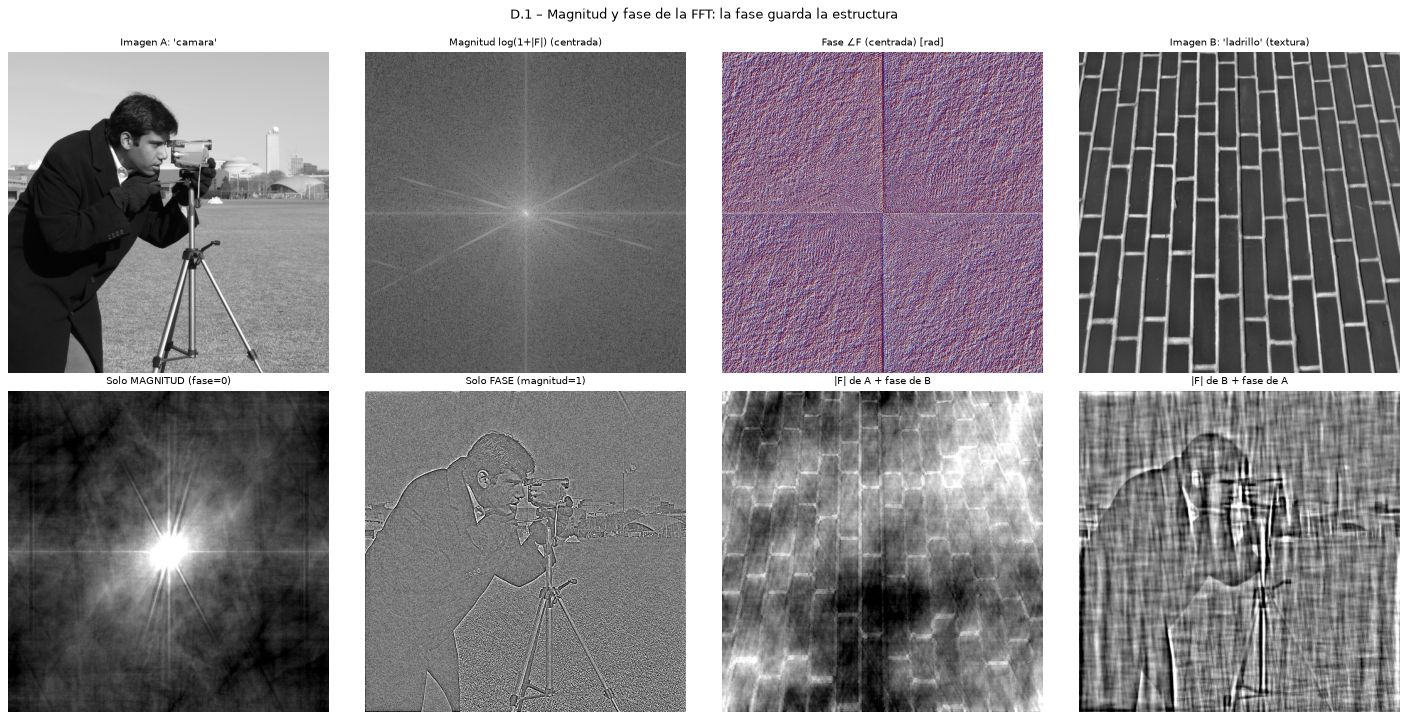

,correlación de píxeles,correlación de mapas de borde
Solo magnitud (fase=0),0.089,-0.028
Solo fase (magnitud=1),0.184,0.703
|F| de A + fase de B → vs A,0.101,-0.022
|F| de A + fase de B → vs B,0.284,0.558
|F| de B + fase de A → vs A,0.284,0.555
|F| de B + fase de A → vs B,0.039,-0.003


In [32]:
def reconstruir(mag, fase):
    """Imagen real a partir de magnitud y fase (espectros NO desplazados)."""
    return np.real(np.fft.ifft2(mag * np.exp(1j * fase)))


def estirar(x, p=(1, 99)):
    """Normalización robusta (percentiles) a [0,1] para mostrar."""
    lo, hi = np.percentile(x, p)
    return np.clip((x - lo) / (hi - lo + 1e-12), 0, 1)


def grad_mag(x):
    return np.hypot(cv2.Sobel(x, cv2.CV_64F, 1, 0), cv2.Sobel(x, cv2.CV_64F, 0, 1))


A, B = IMG["camara"].astype(np.float64), IMG["ladrillo"].astype(np.float64)
FA, FB = np.fft.fft2(A), np.fft.fft2(B)
magA, faseA, magB, faseB = np.abs(FA), np.angle(FA), np.abs(FB), np.angle(FB)

solo_mag = np.fft.fftshift(reconstruir(magA, np.zeros_like(faseA)))          # fase = 0 (se centra con fftshift para verla)
solo_fase = reconstruir(np.ones_like(magA), faseA)                            # magnitud = 1
mag_A_fase_B = reconstruir(magA, faseB)
mag_B_fase_A = reconstruir(magB, faseA)

fig, ejes = plt.subplots(2, 4, figsize=(18, 9))
ejes[0, 0].imshow(A, cmap="gray"); ejes[0, 0].set_title("Imagen A: 'camara'")
ejes[0, 1].imshow(espectro_log(np.fft.fftshift(FA)), cmap="gray"); ejes[0, 1].set_title("Magnitud log(1+|F|) (centrada)")
ejes[0, 2].imshow(np.fft.fftshift(faseA), cmap="twilight", vmin=-np.pi, vmax=np.pi); ejes[0, 2].set_title("Fase ∠F (centrada) [rad]")
ejes[0, 3].imshow(B, cmap="gray"); ejes[0, 3].set_title("Imagen B: 'ladrillo' (textura)")
ejes[1, 0].imshow(estirar(solo_mag), cmap="gray"); ejes[1, 0].set_title("Solo MAGNITUD (fase=0)")
ejes[1, 1].imshow(estirar(solo_fase), cmap="gray"); ejes[1, 1].set_title("Solo FASE (magnitud=1)")
ejes[1, 2].imshow(estirar(mag_A_fase_B), cmap="gray"); ejes[1, 2].set_title("|F| de A + fase de B")
ejes[1, 3].imshow(estirar(mag_B_fase_A), cmap="gray"); ejes[1, 3].set_title("|F| de B + fase de A")
for ax in ejes.ravel():
    ax.axis("off")
plt.suptitle("D.1 – Magnitud y fase de la FFT: la fase guarda la estructura", y=0.995); plt.tight_layout(); plt.show()

filas = {
    "Solo magnitud (fase=0)": (np.fft.ifftshift(solo_mag), A), "Solo fase (magnitud=1)": (solo_fase, A),
    "|F| de A + fase de B → vs A": (mag_A_fase_B, A), "|F| de A + fase de B → vs B": (mag_A_fase_B, B),
    "|F| de B + fase de A → vs A": (mag_B_fase_A, A), "|F| de B + fase de A → vs B": (mag_B_fase_A, B)}
tabla = {n: {"correlación de píxeles": corr(r, ref), "correlación de mapas de borde": corr(grad_mag(r), grad_mag(ref))} for n, (r, ref) in filas.items()}
display(pd.DataFrame(tabla).T.style.format("{:.3f}"))

# **Observación (D.1).** La reconstrucción con **solo la magnitud** no se parece a la escena (una nube simétrica centrada en un punto con "estrellas" de rayos: la magnitud dice *cuánta* energía hay en cada frecuencia, no *dónde* está en la imagen): la correlación de sus mapas de borde con los de `camara` es −0.028. Con **solo la fase** se reconocen el camarógrafo, el trípode y los contornos (aunque sin tonos de gris: los niveles medios viven en la magnitud): correlación de bordes **0.703**. En el intercambio, la imagen resultante se parece a **aquella de la que se tomó la fase**: |F| de A + fase de B se correlaciona con los bordes de B en 0.558 y con los de A en −0.022; |F| de B + fase de A se correlaciona con A en 0.555 y con B en −0.003 (en la figura se ven los ladrillos o el camarógrafo, según la fase usada). **Conclusión:** la **fase conserva la información estructural** (posición de bordes y objetos); la magnitud aporta el contenido de frecuencias global (textura, contraste), pero sin fase no hay estructura.

# ## D.2 Filtros pasa-bajo y pasa-alto: Ideal, Butterworth (n=1,2,4) y Gaussiano
#
# Para cada familia y cada $D_0\in\{10,30,60\}$ se muestra la **máscara** $H(u,v)$ (centrada, blanco = 1), el **espectro filtrado** $\log(1+|HF|)$ y la **imagen resultante**.

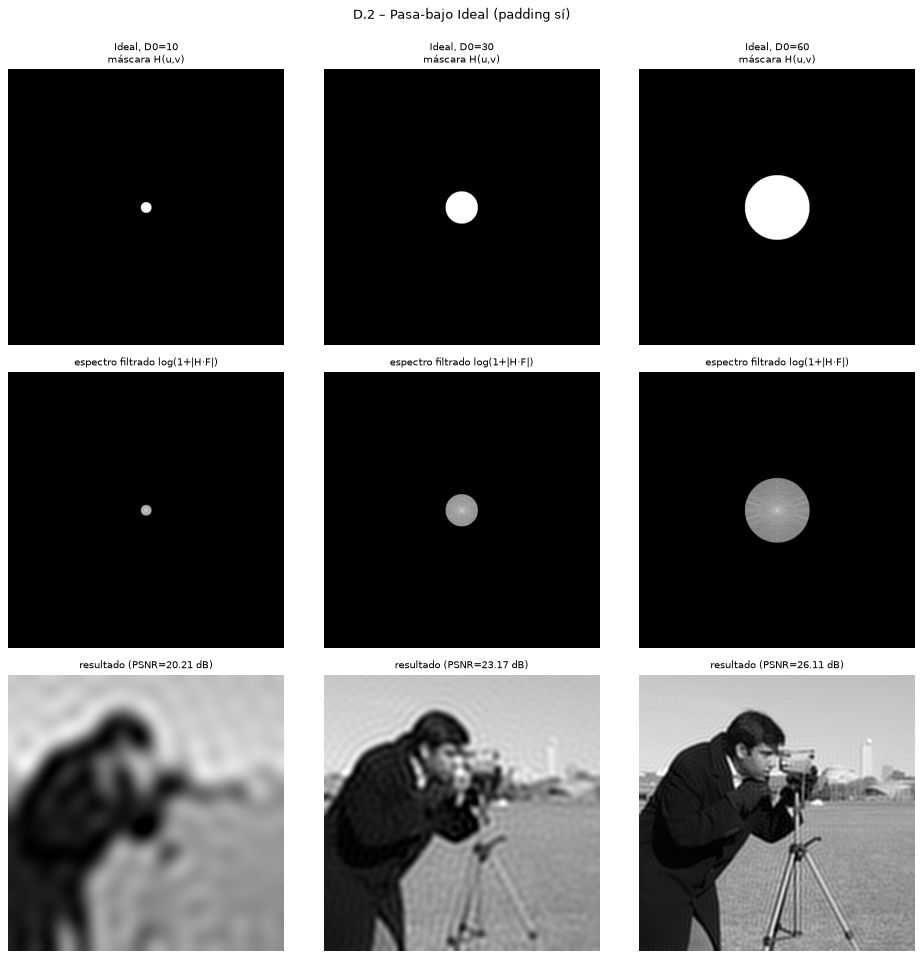

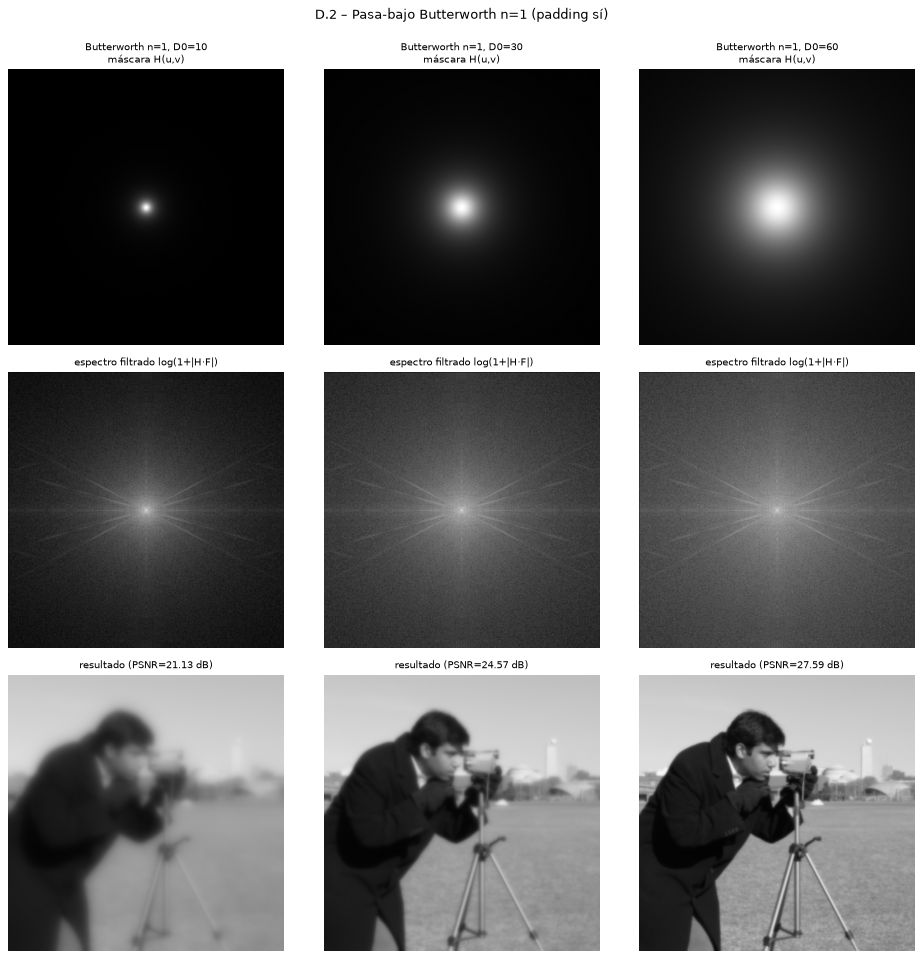

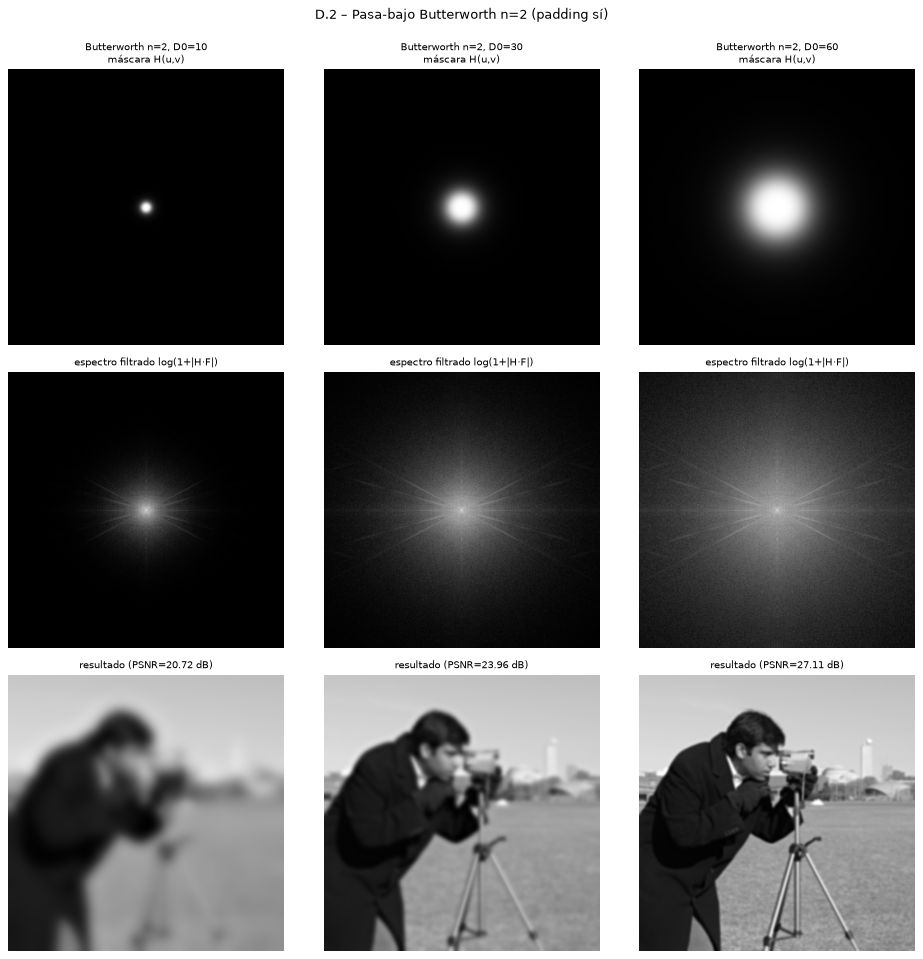

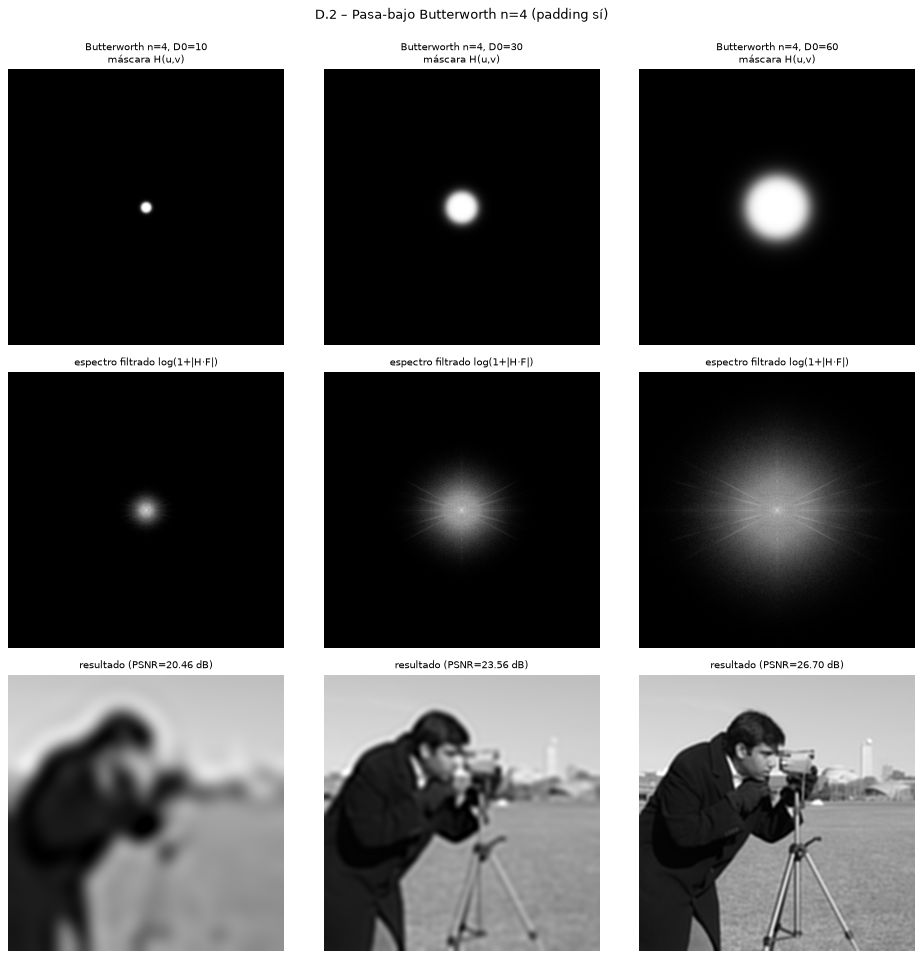

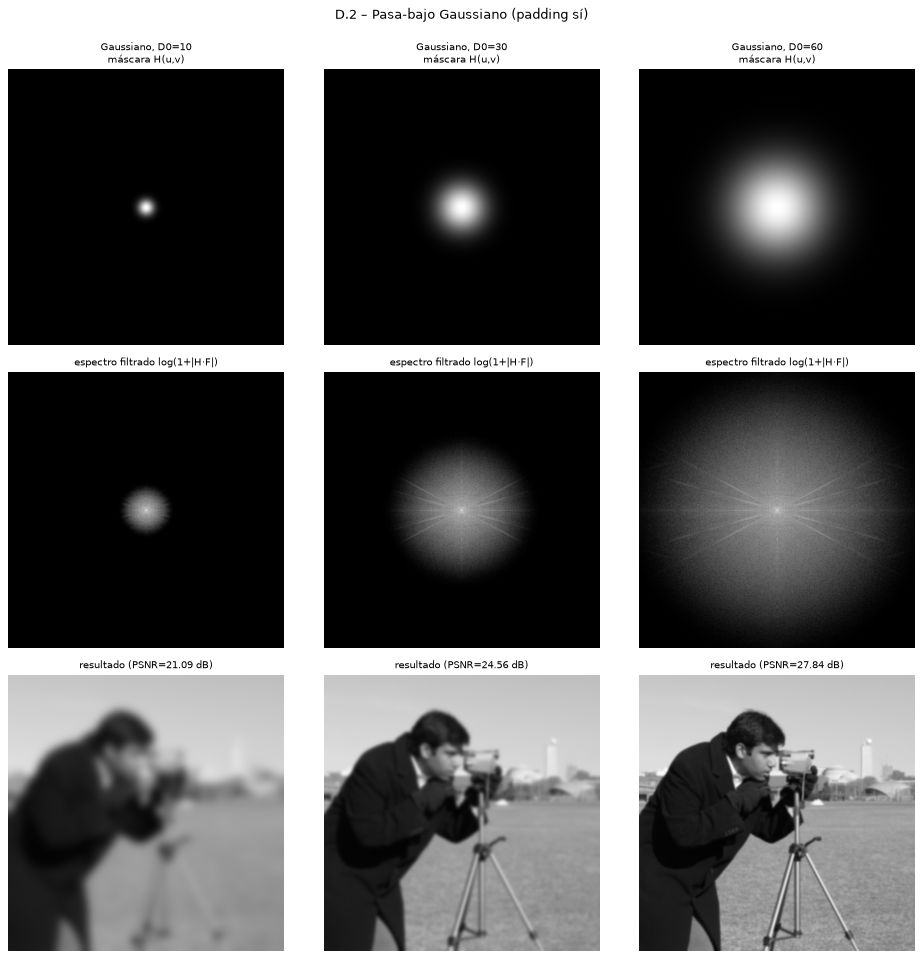

In [33]:
IMG_D = IMG["camara"]
D0S = (10, 30, 60)
RES_PB = {}              # (tipo, n, D0) -> imagen filtrada float64 sin recortar


def rejilla_pb(tipo, n=2, pad=True):
    """Figura 3×3: filas = máscara, espectro filtrado, resultado; columnas = D0."""
    fig, ejes = plt.subplots(3, len(D0S), figsize=(4.0 * len(D0S), 12))
    etiqueta = {"ideal": "Ideal", "butterworth": f"Butterworth n={n}", "gauss": "Gaussiano"}[tipo]
    for j, D0 in enumerate(D0S):
        g, H, G = filtrar_pb(IMG_D, tipo, D0, n, pad=pad)
        RES_PB[(tipo, n, D0)] = g
        ejes[0, j].imshow(H, cmap="gray", vmin=0, vmax=1); ejes[0, j].set_title(f"{etiqueta}, D0={D0}\nmáscara H(u,v)")
        ejes[1, j].imshow(espectro_log(G), cmap="gray"); ejes[1, j].set_title("espectro filtrado log(1+|H·F|)")
        ejes[2, j].imshow(np.clip(g, 0, 255), cmap="gray", vmin=0, vmax=255)
        ejes[2, j].set_title(f"resultado (PSNR={psnr(IMG_D, a_u8(g)):.2f} dB)")
        for ax in ejes[:, j]:
            ax.axis("off")
    plt.suptitle(f"D.2 – Pasa-bajo {etiqueta} (padding {'sí' if pad else 'no'})", y=0.995); plt.tight_layout(); plt.show()


rejilla_pb("ideal")
for n in (1, 2, 4):
    rejilla_pb("butterworth", n)
rejilla_pb("gauss")

In [34]:
# Tabla resumen: nivel de desenfoque (PSNR) y ringing (valores fuera de [0,255] antes de recortar)
filas = []
for (tipo, n, D0), g in RES_PB.items():
    fuera = (g < 0) | (g > 255)
    filas.append({"filtro": {"ideal": "Ideal", "butterworth": f"Butterworth n={n}", "gauss": "Gaussiano"}[tipo], "D0": D0,
                  "PSNR vs original [dB]": psnr(IMG_D, a_u8(g)), "valor mín (sin recortar)": g.min(), "valor máx (sin recortar)": g.max(),
                  "% píxeles fuera de [0,255]": 100 * fuera.mean(), "exceso máx fuera de rango": max(-g.min(), g.max() - 255, 0)})
df_pb = pd.DataFrame(filas).set_index(["filtro", "D0"])
display(df_pb.style.format({"PSNR vs original [dB]": "{:.2f}", "valor mín (sin recortar)": "{:.1f}", "valor máx (sin recortar)": "{:.1f}",
                            "% píxeles fuera de [0,255]": "{:.2f}", "exceso máx fuera de rango": "{:.1f}"}))

# **Observaciones (D.2).**
# * **Efecto de D0:** a mayor D0, más frecuencias pasan y la imagen se parece más a la original (PSNR vs original, Gaussiano: 21.09 dB con D0=10, 24.56 dB con D0=30 y 27.84 dB con D0=60). Con D0=10 desaparecen casi todos los detalles (queda un borroso de bajas frecuencias); la máscara pasa-bajo "deja pasar" un disco de radio D0 alrededor del DC.
# * **Ringing (tabla):** a D0=30 el filtro **ideal** produce valores sin recortar entre **−27.7 y 271.4** (0.55 % de los píxeles fuera de [0,255]), mientras que **Butterworth n=1** (mín 3.8, máx 235.7) y el **Gaussiano** (mín 3.5, máx 243.6) **nunca salen del rango** (0.00 %): sus máscaras son suaves y los kernels equivalentes positivos o casi (ver 1.7). El ringing aparece al subir el orden: Butterworth n=2 solo se pasa levemente (D0=60: máx 260.2, 0.02 %), y **n=4** ya se parece al ideal (mín −10.1, máx 263.6, 0.23 % fuera de rango a D0=30).
# * Con el mismo D0 el filtro ideal da el **menor PSNR** (23.17 dB frente a 24.56 del Gaussiano, D0=30): su corte abrupto no solo desenfoca, también añade oscilaciones espurias. En la figura de zoom (128×128 y perfil de una fila) se ven anillos paralelos a los bordes con el ideal y ninguno con el Gaussiano.
# * **Pasa-alto = 1 − pasa-bajo:** queda solo la parte de alta frecuencia (contornos y textura; el nivel medio desaparece, por eso se muestra con +128). El pasa-alto ideal reproduce el mismo ringing; el Gaussiano da bordes limpios. Sumar el pasa-alto Gaussiano (D0=30) al original nitidiza la imagen (equivale al *unsharp* de B.4, hecho en frecuencia).

In [35]:
# Efecto del padding: Gaussiano D0=10 con y sin extensión de la imagen (la FFT sin padding "enrolla" los bordes)
g_sin, _, _ = filtrar_pb(IMG_D, "gauss", 10, pad=False)
dif_pad = np.abs(g_sin - RES_PB[("gauss", 2, 10)])
print(f"Gaussiano D0=10, sin padding vs con padding: dif. máx = {dif_pad.max():.1f} niveles | media en franja de 15 px del borde = {np.mean(np.r_[dif_pad[:15].ravel(), dif_pad[-15:].ravel(), dif_pad[:, :15].ravel(), dif_pad[:, -15:].ravel()]):.2f} | media en el interior = {dif_pad[40:-40, 40:-40].mean():.3f}")

Gaussiano D0=10, sin padding vs con padding: dif. máx = 111.4 niveles | media en franja de 15 px del borde = 15.41 | media en el interior = 0.000


# **Padding (cifra de la celda anterior):** con Gaussiano D0=10, filtrar sin extender la imagen difiere hasta **111.4 niveles** de filtrar con extensión simétrica, con una diferencia media de **15.4** en la franja de 15 px del borde y de **0.000** en el interior (>40 px del borde): el *wrap-around* solo contamina los bordes (el desenfoque mezcla el cielo claro de un lado con el césped oscuro del otro), pero ahí el error es grande. Por eso se usa padding por defecto para filtrar imágenes naturales.

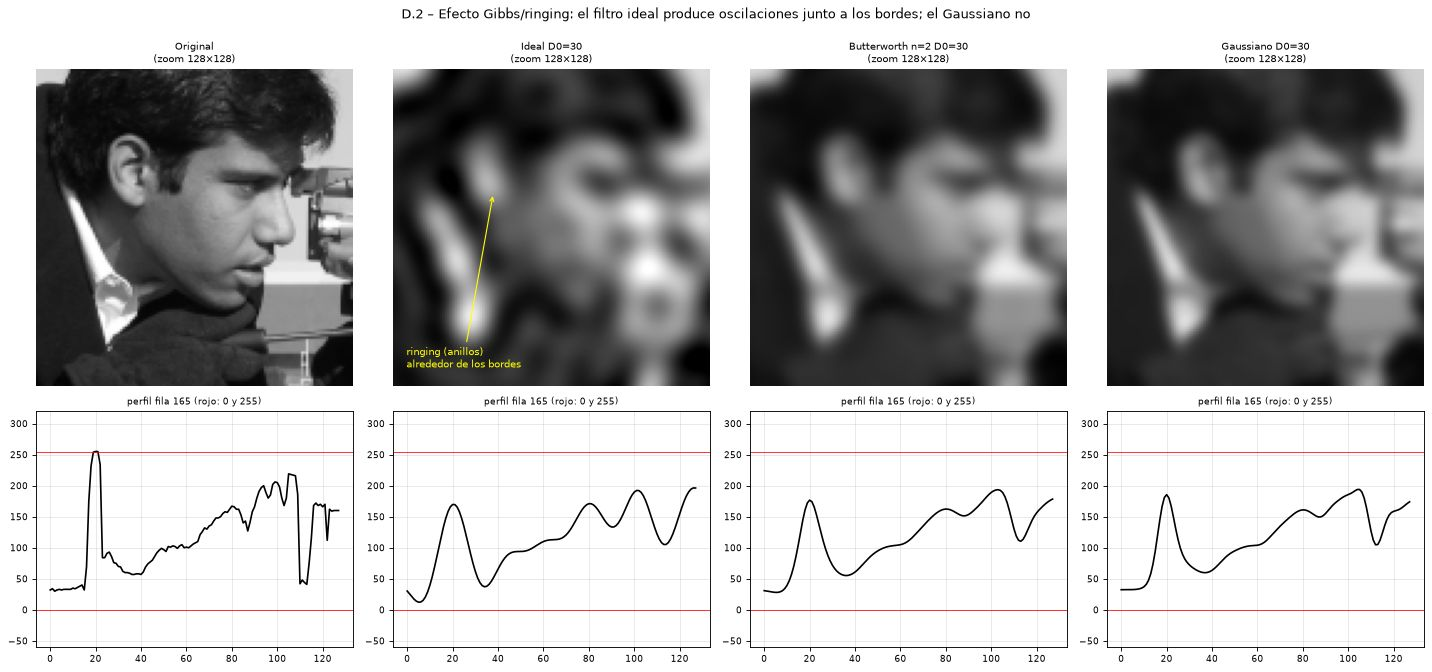

In [36]:
# ---- Ringing (efecto Gibbs): zoom en un borde y perfil de una fila, Ideal vs Butterworth vs Gaussiano (D0=30) ----
zoom = (slice(100, 228), slice(150, 278))
cas = [("Original", IMG_D.astype(float)), ("Ideal D0=30", RES_PB[("ideal", 2, 30)]), ("Butterworth n=2 D0=30", RES_PB[("butterworth", 2, 30)]),
       ("Gaussiano D0=30", RES_PB[("gauss", 2, 30)])]
fig, ejes = plt.subplots(2, 4, figsize=(18, 8.4), gridspec_kw={"height_ratios": [3, 2]})
fila_p = 165
for j, (n, im) in enumerate(cas):
    ejes[0, j].imshow(np.clip(im[zoom], 0, 255), cmap="gray", vmin=0, vmax=255); ejes[0, j].set_title(f"{n}\n(zoom 128×128)"); ejes[0, j].axis("off")
    ejes[1, j].plot(im[fila_p, 150:278], "k"); ejes[1, j].axhline(0, c="r", lw=.7); ejes[1, j].axhline(255, c="r", lw=.7)
    ejes[1, j].set_ylim(-60, 320); ejes[1, j].set_title(f"perfil fila {fila_p} (rojo: 0 y 255)", fontsize=8); ejes[1, j].grid(alpha=.3)
ejes[0, 1].annotate("ringing (anillos)\nalrededor de los bordes", xy=(40, 50), xytext=(5, 120), color="yellow", fontsize=9,
                    arrowprops=dict(arrowstyle="->", color="yellow"))
plt.suptitle("D.2 – Efecto Gibbs/ringing: el filtro ideal produce oscilaciones junto a los bordes; el Gaussiano no", y=0.995); plt.tight_layout(); plt.show()

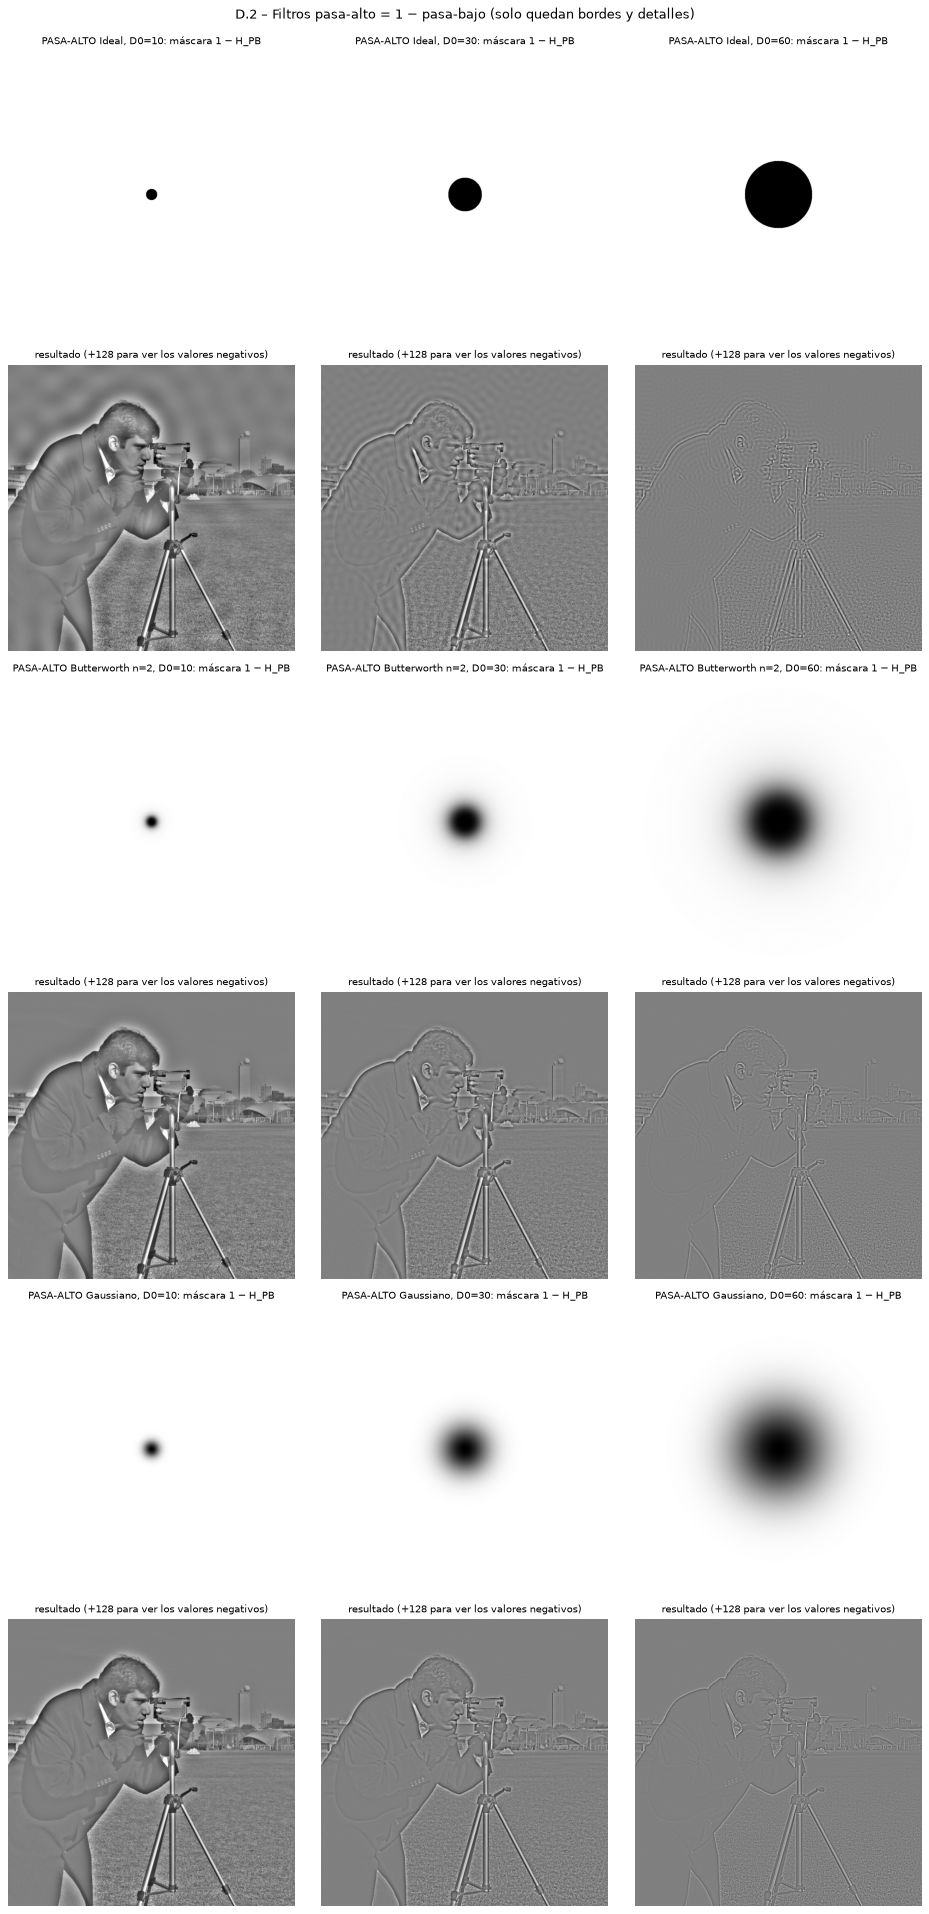

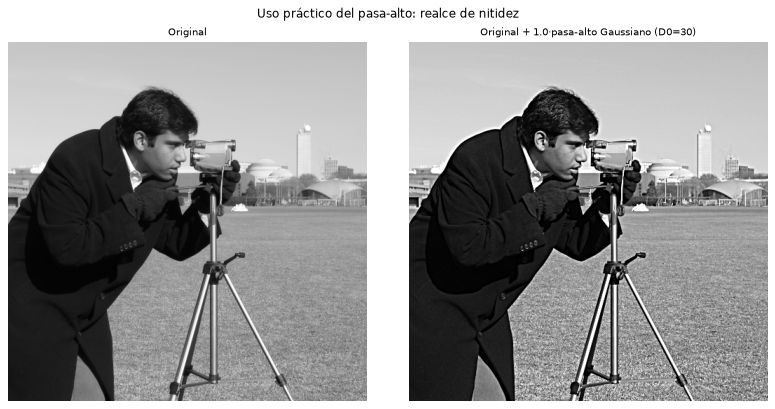

In [37]:
# ---- Versión pasa-alto: máscaras y resultados (Ideal, Butterworth n=2, Gaussiano) ----
fig, ejes = plt.subplots(6, len(D0S), figsize=(4.0 * len(D0S), 24))
for i, (tipo, n, nom) in enumerate([("ideal", 2, "Ideal"), ("butterworth", 2, "Butterworth n=2"), ("gauss", 2, "Gaussiano")]):
    for j, D0 in enumerate(D0S):
        g, H, G = filtrar_pb(IMG_D, tipo, D0, n, pasa="alto", pad=True)
        ejes[2 * i, j].imshow(H, cmap="gray", vmin=0, vmax=1); ejes[2 * i, j].set_title(f"PASA-ALTO {nom}, D0={D0}: máscara 1 − H_PB")
        ejes[2 * i + 1, j].imshow(np.clip(g + 128, 0, 255), cmap="gray", vmin=0, vmax=255); ejes[2 * i + 1, j].set_title("resultado (+128 para ver los valores negativos)")
        ejes[2 * i, j].axis("off"); ejes[2 * i + 1, j].axis("off")
plt.suptitle("D.2 – Filtros pasa-alto = 1 − pasa-bajo (solo quedan bordes y detalles)", y=0.995); plt.tight_layout(); plt.show()

# Realce por frecuencia: original + pasa-alto (equivale a un unsharp en frecuencia)
g_pa, _, _ = filtrar_pb(IMG_D, "gauss", 30, pasa="alto")
cuadricula([IMG_D, a_u8(IMG_D + 1.0 * g_pa)], ["Original", "Original + 1.0·pasa-alto Gaussiano (D0=30)"], ncols=2, celda=(5, 5), suptitulo="Uso práctico del pasa-alto: realce de nitidez")

# ## D.3 Ruido periódico y filtro notch
#
# Se suma a `camara` una sinusoide $20\,\sin(2\pi\cdot0.1\cdot x)$ ($x$ = columna). Una sinusoide pura es **dos deltas** en el espectro, simétricas respecto del DC, en $\pm(0,\;0.1N)$ ($N$=512: ±51.2 ciclos por imagen, que no cae exactamente en un bin entero y por eso se "derrama" un poco, *leakage*). Se localizan los picos (máximos fuera del DC), se marcan, y se eliminan con filtros **notch** (rechaza-banda puntual) en cada pico y en su simétrico. Se prueban las versiones Butterworth y Gaussiana (suaves, sin ringing) con distintos radios.

In [38]:
x = np.arange(TAM)[None, :].repeat(TAM, axis=0)
ruido_per = 20.0 * np.sin(2 * np.pi * 0.1 * x)
img_per = a_u8(IMG["camara"].astype(np.float64) + ruido_per)           # imagen con ruido periódico (float -> uint8 al final)
print(f"PSNR de la imagen con ruido periódico = {psnr(IMG['camara'], img_per):.2f} dB | SSIM = {ssim(IMG['camara'], img_per):.4f}")

F_per = np.fft.fftshift(np.fft.fft2(img_per.astype(np.float64)))
mag_per = np.abs(F_per)
M, N = mag_per.shape
cy, cx = M // 2, N // 2
D_centro = distancias(mag_per.shape)

# 1) Pico principal: máximo fuera de una vecindad del DC (radio 15)
busq = mag_per.copy(); busq[D_centro < 15] = 0
p1 = tuple(int(i) for i in np.unravel_index(np.argmax(busq), busq.shape))
# 2) El segundo pico (simétrico): máximo tras borrar la vecindad del primero
busq2 = busq.copy(); busq2[np.hypot(np.arange(M)[:, None] - p1[0], np.arange(N)[None, :] - p1[1]) < 10] = 0
p2 = tuple(int(i) for i in np.unravel_index(np.argmax(busq2), busq2.shape))
sim = (2 * cy - p1[0], 2 * cx - p1[1])                                   # simétrico teórico respecto del centro (cy, cx)
print(f"Centro del espectro (DC) = ({cy},{cx})")
print(f"Pico 1 en (fila,col) = {p1}  -> desplazamiento respecto del DC (Δu,Δv) = ({p1[0]-cy:+d},{p1[1]-cx:+d})")
print(f"Pico 2 en (fila,col) = {p2}  -> desplazamiento respecto del DC (Δu,Δv) = ({p2[0]-cy:+d},{p2[1]-cx:+d})")
print(f"Simétrico teórico del pico 1 = {sim}  (coincide con el pico 2: {p2 == sim})")
print(f"Frecuencia esperada = 0.1·N = {0.1 * N:.1f} ciclos/imagen en el eje horizontal; la encontrada es {abs(p1[1]-cx)}")
dv0 = (p1[0] - cy, p1[1] - cx)             # (Δu, Δv) del pico 1; el simétrico es (−Δu, −Δv)


def H_notch(forma, centros, r, tipo="gauss", n=2):
    """Notch (rechaza) en cada centro (Δu,Δv) y en su simétrico (−Δu,−Δv). Producto de máscaras de rechazo."""
    M_, N_ = forma
    u = (np.arange(M_) - M_ // 2)[:, None]; v = (np.arange(N_) - N_ // 2)[None, :]
    H = np.ones(forma)
    for (du, dv) in centros:
        for s in (+1, -1):
            D = np.hypot(u - s * du, v - s * dv)
            if tipo == "gauss":
                H *= 1.0 - np.exp(-(D ** 2) / (2 * r ** 2))
            elif tipo == "butterworth":
                H *= 1.0 / (1.0 + (r / np.maximum(D, 1e-9)) ** (2 * n))
            elif tipo == "ideal":
                H *= (D > r).astype(float)
    return H


# Variantes de notch (radio r en bins; sin padding porque el ruido es exactamente periódico)
NOTCH = {f"notch Gauss r={r}": (lambda forma, r=r: H_notch(forma, [dv0], r, "gauss")) for r in (3, 6, 10)}
NOTCH |= {f"notch Butterworth n=2 r={r}": (lambda forma, r=r: H_notch(forma, [dv0], r, "butterworth", 2)) for r in (3, 6, 10)}
NOTCH["notch ideal r=6 (ringing)"] = lambda forma: H_notch(forma, [dv0], 6, "ideal")
res_notch = {n: aplicar_H(img_per, h, pad=False) for n, h in NOTCH.items()}

PSNR de la imagen con ruido periódico = 25.20 dB | SSIM = 0.5009
Centro del espectro (DC) = (256,256)
Pico 1 en (fila,col) = (256, 205)  -> desplazamiento respecto del DC (Δu,Δv) = (+0,-51)
Pico 2 en (fila,col) = (256, 307)  -> desplazamiento respecto del DC (Δu,Δv) = (+0,+51)
Simétrico teórico del pico 1 = (256, 307)  (coincide con el pico 2: True)
Frecuencia esperada = 0.1·N = 51.2 ciclos/imagen en el eje horizontal; la encontrada es 51


Candidatos espaciales (top 5 por PSNR):


,PSNR (dB),SSIM
Bilateral d=9 σc=25 σs=75,27.92,0.6096
NLM h=20,27.54,0.5909
Bilateral d=9 σc=75 σs=75,26.88,0.5924
Gaussiano σ=1,25.04,0.4550
Gaussiano σ=2,24.98,0.5472


Comparación final (referencia: imagen limpia):


,PSNR (dB),SSIM
notch Gauss r=3,38.31,0.9552
notch Butterworth n=2 r=3,38.23,0.9518
notch Butterworth n=2 r=6,37.03,0.9585
notch Gauss r=6,36.79,0.9608
notch ideal r=6 (ringing),36.18,0.9408
notch Butterworth n=2 r=10,34.84,0.9575
notch Gauss r=10,34.15,0.9595
Espacial (mejor de A): Bilateral d=9 σc=25 σs=75,27.92,0.6096
Con ruido periódico (sin filtrar),25.20,0.5009


Mejor notch: 'notch Gauss r=3'


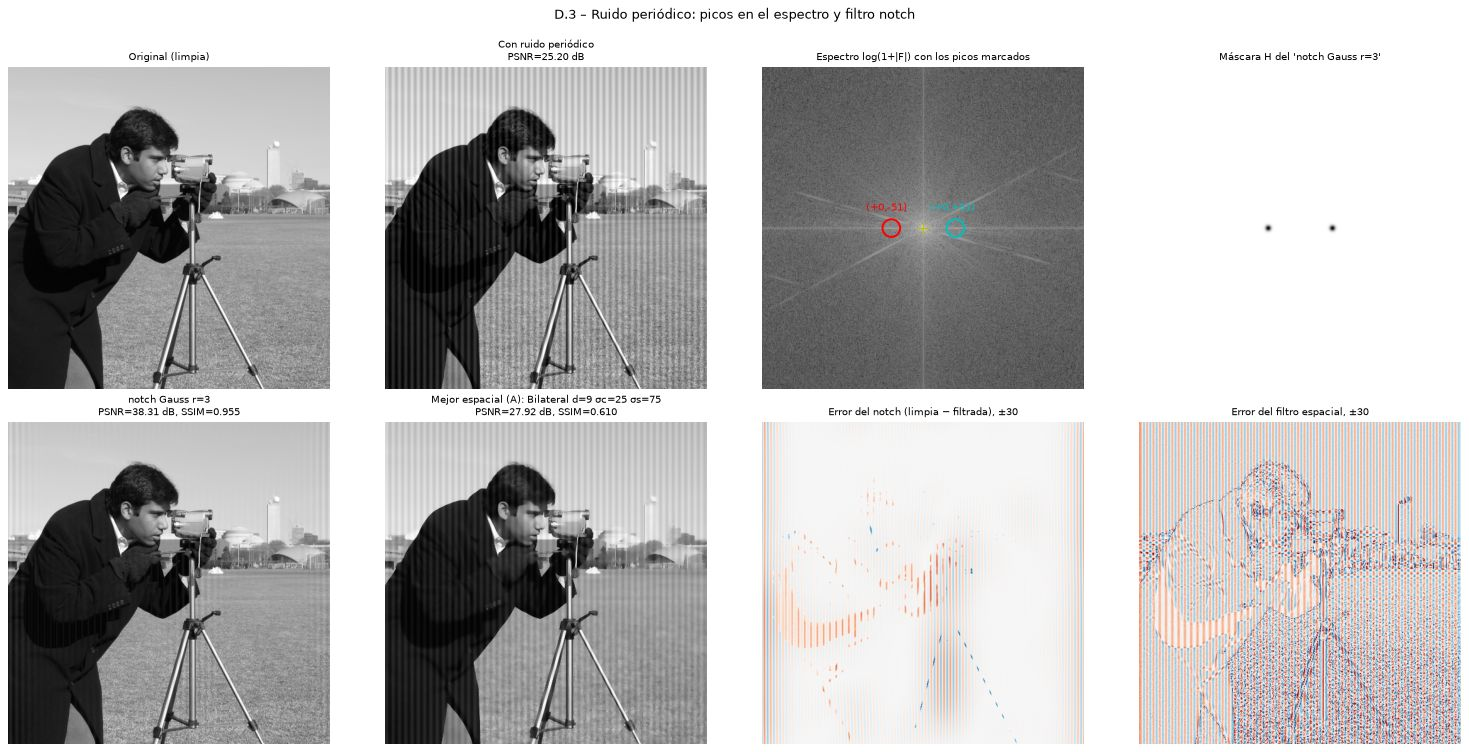

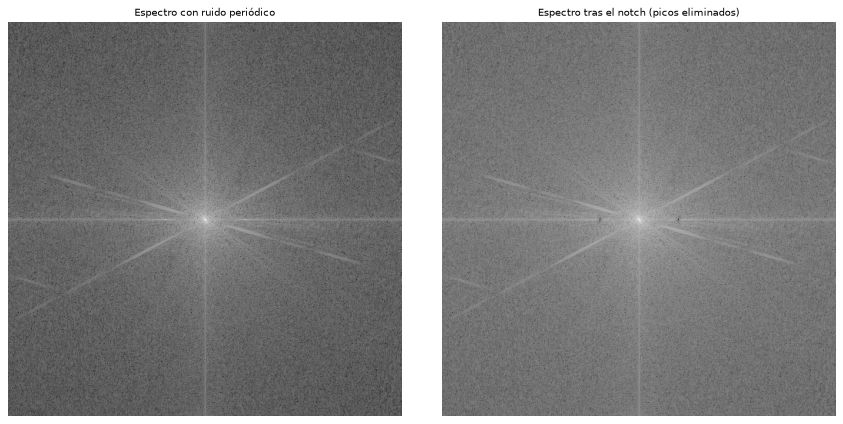

In [39]:
# ---- Mejor filtro espacial del Módulo A para este ruido (barrido por PSNR) ----
cand_esp = {}
for s in (1, 2, 3, 5): cand_esp[f"Gaussiano σ={s}"] = cv2.GaussianBlur(img_per, (tam_kernel_gauss(s),) * 2, s)
for k in (3, 5, 9, 15): cand_esp[f"Media {k}×{k}"] = cv2.blur(img_per, (k, k))
for k in (3, 5, 9): cand_esp[f"Mediana {k}×{k}"] = cv2.medianBlur(img_per, k)
for sc in (25, 75): cand_esp[f"Bilateral d=9 σc={sc} σs=75"] = cv2.bilateralFilter(img_per, 9, sc, 75)
cand_esp["NLM h=20"] = cv2.fastNlMeansDenoising(img_per, None, 20, 7, 21)
df_esp = tablas_metricas(IMG["camara"], cand_esp).sort_values("PSNR (dB)", ascending=False)
mejor_esp = df_esp.index[0]

resultados_D3 = {"Con ruido periódico (sin filtrar)": img_per}
resultados_D3 |= {f"Espacial (mejor de A): {mejor_esp}": cand_esp[mejor_esp]}
resultados_D3 |= {n: a_u8(g) for n, (g, _, _) in res_notch.items()}
df_d3 = tablas_metricas(IMG["camara"], resultados_D3)
print("Candidatos espaciales (top 5 por PSNR):"); display(df_esp.head(5).style.format({"PSNR (dB)": "{:.2f}", "SSIM": "{:.4f}"}))
print("Comparación final (referencia: imagen limpia):")
display(df_d3.sort_values("PSNR (dB)", ascending=False).style.format({"PSNR (dB)": "{:.2f}", "SSIM": "{:.4f}"}).highlight_max(color="#b7e4c7"))
mejor_notch = df_d3.drop(index=["Con ruido periódico (sin filtrar)", f"Espacial (mejor de A): {mejor_esp}"]).sort_values("PSNR (dB)", ascending=False).index[0]
print(f"Mejor notch: '{mejor_notch}'")

fig, ejes = plt.subplots(2, 4, figsize=(19, 9.4))
ejes[0, 0].imshow(IMG["camara"], cmap="gray"); ejes[0, 0].set_title("Original (limpia)")
ejes[0, 1].imshow(img_per, cmap="gray"); ejes[0, 1].set_title(f"Con ruido periódico\nPSNR={psnr(IMG['camara'], img_per):.2f} dB")
ejes[0, 2].imshow(espectro_log(F_per), cmap="gray"); ejes[0, 2].set_title("Espectro log(1+|F|) con los picos marcados")
for (py, px_), c in ((p1, "r"), (p2, "c")):
    ejes[0, 2].add_patch(plt.Circle((px_, py), 14, color=c, fill=False, lw=1.8))
    ejes[0, 2].annotate(f"({py - cy:+d},{px_ - cx:+d})", (px_, py), xytext=(px_ - 40, py - 28), color=c, fontsize=9)
ejes[0, 2].plot(cx, cy, "y+", ms=10)
ejes[0, 3].imshow(res_notch[mejor_notch][1], cmap="gray", vmin=0, vmax=1); ejes[0, 3].set_title(f"Máscara H del '{mejor_notch}'")
ejes[1, 0].imshow(res_notch[mejor_notch][0].clip(0, 255), cmap="gray", vmin=0, vmax=255); ejes[1, 0].set_title(f"{mejor_notch}\nPSNR={df_d3.loc[mejor_notch, 'PSNR (dB)']:.2f} dB, SSIM={df_d3.loc[mejor_notch, 'SSIM']:.3f}")
ejes[1, 1].imshow(cand_esp[mejor_esp], cmap="gray", vmin=0, vmax=255); ejes[1, 1].set_title(f"Mejor espacial (A): {mejor_esp}\nPSNR={df_d3.loc[f'Espacial (mejor de A): {mejor_esp}', 'PSNR (dB)']:.2f} dB, SSIM={df_d3.loc[f'Espacial (mejor de A): {mejor_esp}', 'SSIM']:.3f}")
ejes[1, 2].imshow(IMG["camara"].astype(float) - res_notch[mejor_notch][0], cmap="RdBu", vmin=-30, vmax=30); ejes[1, 2].set_title("Error del notch (limpia − filtrada), ±30")
ejes[1, 3].imshow(IMG["camara"].astype(float) - cand_esp[mejor_esp], cmap="RdBu", vmin=-30, vmax=30); ejes[1, 3].set_title("Error del filtro espacial, ±30")
for ax in ejes.ravel():
    ax.axis("off")
plt.suptitle("D.3 – Ruido periódico: picos en el espectro y filtro notch", y=0.995); plt.tight_layout(); plt.show()

# Espectro después del notch
fig, ejes = plt.subplots(1, 2, figsize=(11, 5.3))
ejes[0].imshow(espectro_log(F_per), cmap="gray"); ejes[0].set_title("Espectro con ruido periódico")
ejes[1].imshow(espectro_log(np.fft.fftshift(np.fft.fft2(res_notch[mejor_notch][0]))), cmap="gray"); ejes[1].set_title("Espectro tras el notch (picos eliminados)")
for ax in ejes:
    ax.axis("off")
plt.tight_layout(); plt.show()

# **Observaciones (D.3).**
# * **Localización de los picos:** el espectro de la imagen con ruido periódico (PSNR 25.20 dB, SSIM 0.501) muestra dos picos fuera del DC en **(Δu,Δv) = (0, −51) y (0, +51)** (fila 256, columnas 205 y 307), exactamente simétricos respecto del centro (256,256), como corresponde a una señal real. La frecuencia esperada era 0.1·512 = 51.2 ciclos/imagen; el pico cae en el bin 51 y el resto de la energía se reparte en los bins vecinos (*leakage*, porque 51.2 no es entero). Como el ruido varía solo con la columna $x$, los picos están sobre el eje horizontal ($\Delta u=0$), y en la imagen se ven bandas verticales.
# * **Notch:** quita el ruido casi por completo con un radio pequeño: **notch Gauss r=3 → 38.31 dB (SSIM 0.955)** y notch Butterworth n=2 r=3 → 38.23 dB (SSIM 0.952). A mayor radio el PSNR *baja* (Gauss r=6: 36.79 dB; r=10: 34.15 dB) porque se eliminan también frecuencias de la imagen; en SSIM el óptimo está en r=6 (Gauss: **0.961**). El notch **ideal** r=6 (36.18 dB, SSIM 0.941) es peor que los suaves del mismo radio (Gauss r=6: 36.79 dB / 0.961; Butterworth r=6: 37.03 dB / 0.959): el corte abrupto vuelve a producir ringing.
# * **Comparación con el mejor filtro espacial del Módulo A** (barrido de 14 candidatos; el mejor es el bilateral d=9, σc=25, σs=75): **27.92 dB / SSIM 0.610** frente a **38.31 dB / 0.955** del notch: **+10.4 dB y +0.345 de SSIM**. Un filtro espacial pasa-bajo no sabe distinguir el patrón periódico de 51 ciclos/imagen (≈ 10 px de periodo) de la textura de la propia imagen: o no lo quita o desenfoca todo (ver el mapa de error: queda un patrón de rayas más los bordes del camarógrafo). El notch actúa sobre **solo 2 puntos** del espectro y no toca el resto.
# * **Limitaciones:** en el mapa de error del notch persiste algo de rayado cerca de las zonas saturadas (0 y 255): al sumar el ruido y recortar a uint8 se generó una pequeña distorsión no lineal (armónicos) que el notch en la fundamental no elimina.
# * **Conclusión:** para ruido periódico, el filtrado en frecuencia (notch suave) es la herramienta correcta; con los datos: +10.4 dB sobre el mejor filtro espacial.

# ## D.4 Equivalencia espacio–frecuencia
#
# Un Gaussiano en frecuencia $H=\exp(-D^2/2D_0^2)$ (con $D$ en ciclos por imagen) corresponde a un Gaussiano en el espacio con $\sigma_{esp}=\dfrac{N}{2\pi D_0}$ píxeles (la transformada de un Gaussiano de desviación σ es otro Gaussiano de desviación $1/(2\pi\sigma)$ en ciclos/píxel; con $f=D/N$: $e^{-2\pi^2\sigma^2 D^2/N^2}=e^{-D^2/2D_0^2}\Rightarrow \sigma=N/(2\pi D_0)$). Se comprueba numéricamente con $D_0=30$ en `camara` (float64).

σ espacial equivalente = N/(2π·D0) = 512/(2π·30) = 2.7162 px


,error abs máx,error abs medio,error rel máx (/255),error rel respecto al valor (mediana),PSNR [dB],error medio en interior,error medio en borde (20 px)
comparación,,,,,,,
FFT vs cv2.GaussianBlur (REFLECT_101),1.023e+02,5.832e-01,4.010e-01,1.681e-06,35.43,3.980e-04,3.882e+00
"FFT vs gaussian_filter wrap, truncado 4σ",6.728e-03,4.151e-04,2.638e-05,1.449e-06,110.40,3.980e-04,5.117e-04
"FFT vs gaussian_filter wrap, truncado 8σ",1.990e-13,3.238e-14,7.802e-16,2.511e-16,315.66,3.198e-14,3.468e-14


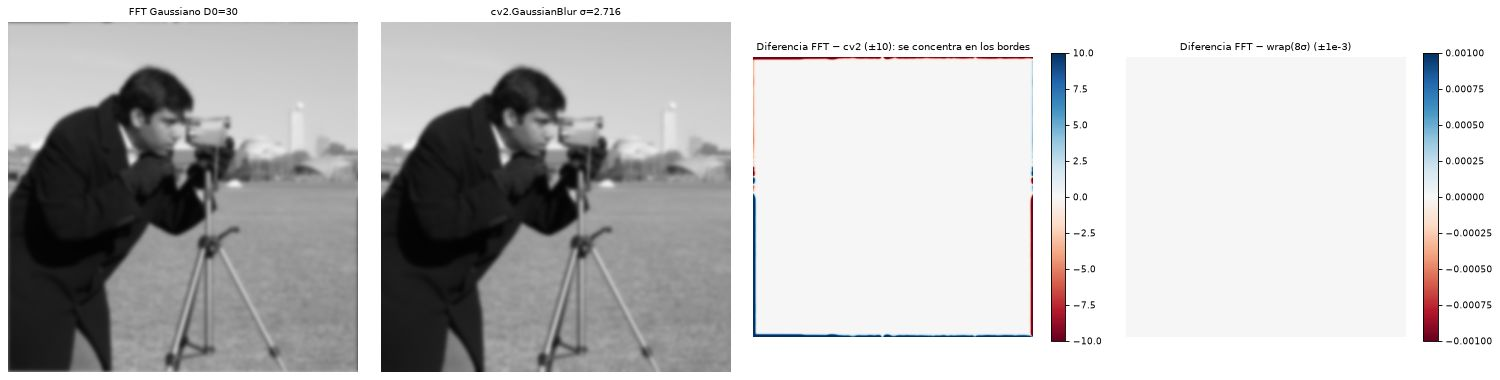

In [40]:
D0_eq = 30
sigma_esp = TAM / (2 * np.pi * D0_eq)
print(f"σ espacial equivalente = N/(2π·D0) = {TAM}/(2π·{D0_eq}) = {sigma_esp:.4f} px")

f64 = IMG["camara"].astype(np.float64)
g_fft, H_eq, _ = filtrar_pb(f64, "gauss", D0_eq, pad=False)                           # FFT sin padding (supone periodicidad)
g_cv = cv2.GaussianBlur(f64, (0, 0), sigma_esp)                                       # borde por defecto: REFLECT_101
g_wrap4 = ndi.gaussian_filter(f64, sigma_esp, mode="wrap", truncate=4.0)              # periódico, kernel truncado a 4σ
g_wrap8 = ndi.gaussian_filter(f64, sigma_esp, mode="wrap", truncate=8.0)              # periódico, truncado a 8σ (casi sin truncar)


def comparar(a, b, nombre):
    d = np.abs(a - b)
    borde = np.zeros_like(d, bool); borde[:20, :] = borde[-20:, :] = borde[:, :20] = borde[:, -20:] = True
    return {"comparación": nombre, "error abs máx": d.max(), "error abs medio": d.mean(),
            "error rel máx (/255)": d.max() / 255, "error rel respecto al valor (mediana)": np.median(d / np.maximum(np.abs(b), 1)),
            "PSNR [dB]": sk_psnr(b, a, data_range=255), "error medio en interior": d[~borde].mean(), "error medio en borde (20 px)": d[borde].mean()}


df_eq = pd.DataFrame([comparar(g_fft, g_cv, "FFT vs cv2.GaussianBlur (REFLECT_101)"),
                      comparar(g_fft, g_wrap4, "FFT vs gaussian_filter wrap, truncado 4σ"),
                      comparar(g_fft, g_wrap8, "FFT vs gaussian_filter wrap, truncado 8σ")]).set_index("comparación")
display(df_eq.style.format("{:.3e}", subset=[c for c in df_eq.columns if c != "PSNR [dB]"]).format("{:.2f}", subset=["PSNR [dB]"]))

fig, ejes = plt.subplots(1, 4, figsize=(19, 4.8))
ejes[0].imshow(np.clip(g_fft, 0, 255), cmap="gray", vmin=0, vmax=255); ejes[0].set_title(f"FFT Gaussiano D0={D0_eq}")
ejes[1].imshow(np.clip(g_cv, 0, 255), cmap="gray", vmin=0, vmax=255); ejes[1].set_title(f"cv2.GaussianBlur σ={sigma_esp:.3f}")
im1 = ejes[2].imshow(g_fft - g_cv, cmap="RdBu", vmin=-10, vmax=10); ejes[2].set_title("Diferencia FFT − cv2 (±10): se concentra en los bordes")
im2 = ejes[3].imshow(g_fft - g_wrap8, cmap="RdBu", vmin=-1e-3, vmax=1e-3); ejes[3].set_title("Diferencia FFT − wrap(8σ) (±1e-3)")
for ax in ejes:
    ax.axis("off")
fig.colorbar(im1, ax=ejes[2], shrink=.8); fig.colorbar(im2, ax=ejes[3], shrink=.8)
plt.tight_layout(); plt.show()

# **Observaciones (D.4).** σ espacial equivalente = 512/(2π·30) = **2.716 px**.
# * **FFT vs `gaussian_filter` periódico (modo `wrap`) con el kernel casi sin truncar (8σ):** el error máximo absoluto es **2.0·10⁻¹³** niveles (error relativo ≈ 10⁻¹⁵ del rango, PSNR > 300 dB): las dos operaciones son **la misma** (a precisión de máquina) cuando se respeta la hipótesis de la FFT (periodicidad) y no se trunca el kernel.
# * **Truncando el kernel a 4σ** (lo habitual): error máximo 6.7·10⁻³ niveles (PSNR 110.4 dB), error medio 4.2·10⁻⁴: es el efecto de **truncar la cola del Gaussiano** (el kernel espacial se corta a ±4σ).
# * **FFT vs `cv2.GaussianBlur`** (borde por defecto `REFLECT_101`): error máximo **102.3 niveles** (0.40 del rango) y PSNR 35.43 dB; pero el error medio en el **interior** es solo **4.0·10⁻⁴** (igual que con el kernel truncado a 4σ) y en la franja de 20 px del **borde** sube a **3.88**. La mediana del error relativo es 1.7·10⁻⁶. O sea: en el interior la equivalencia es casi exacta; las diferencias son **de borde**: la FFT supone una imagen periódica (el borde derecho se une al izquierdo), mientras que OpenCV refleja la imagen en el borde.
# * **Resumen de las diferencias:** (1) *condiciones de borde* (periódicas en la FFT, reflexión en OpenCV): dominan y solo afectan a una franja de unos 4σ ≈ 11 px; (2) *truncamiento del kernel espacial* (≈ 4σ en OpenCV): error de ~10⁻³ niveles; (3) *muestreo*: la máscara es un Gaussiano exacto en frecuencia y su transformada inversa es un Gaussiano periodizado y muestreado (diferencia despreciable para σ=2.7 px).

# ## Preguntas del Módulo D
#
# ### Evidencia para la pregunta 1.7: el kernel espacial equivalente (`ifft2` de la máscara)
# Se calcula la respuesta al impulso espacial $h(x,y)=\mathcal F^{-1}\{H\}$ de cada máscara pasa-bajo con $D_0=30$ y se muestra el centro y un perfil.

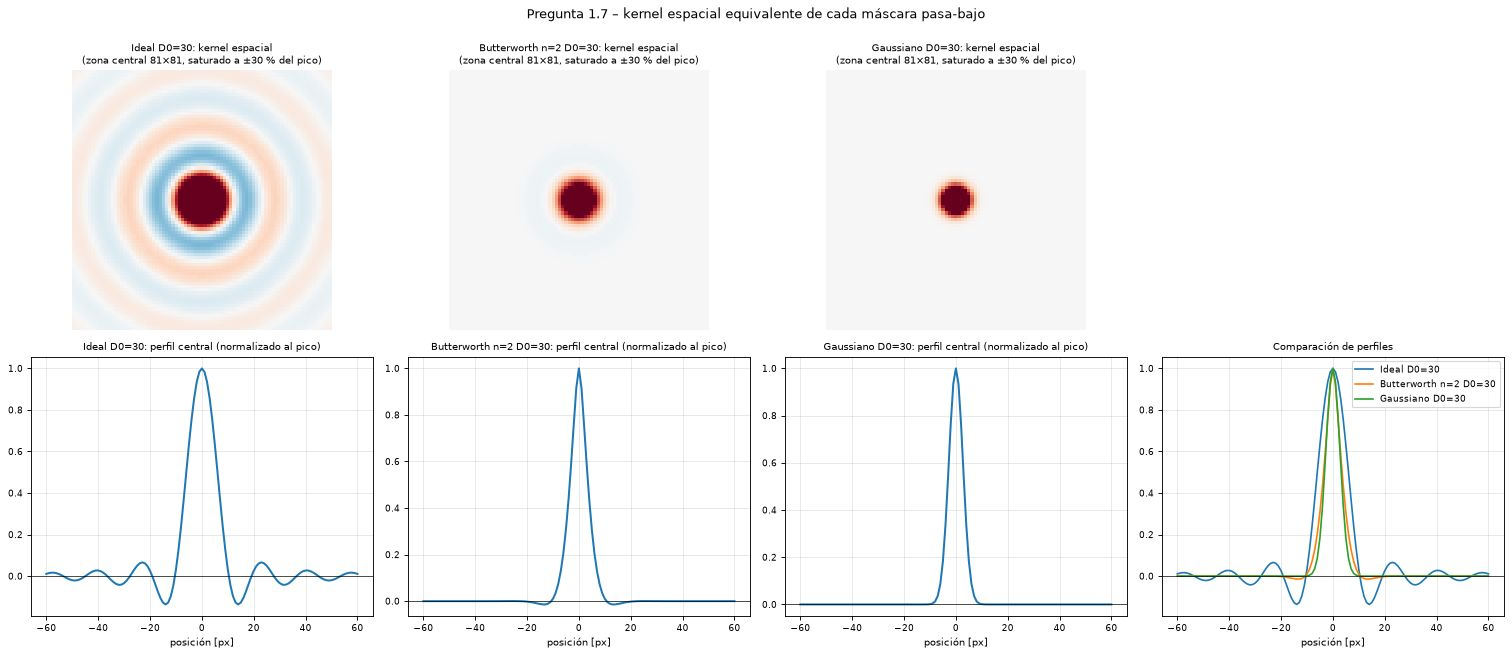

,valor mínimo / pico,energía en valores negativos [%],cambios de signo en el perfil central
Ideal D0=30,-0.1363,10.79,58
Butterworth n=2 D0=30,-0.0144,0.27,8
Gaussiano D0=30,-0.0000,0.00,0


In [41]:
def kernel_espacial(H):
    """Respuesta al impulso espacial h = ifft2(H) (real, centrada) de una máscara H centrada."""
    return np.fft.fftshift(np.real(np.fft.ifft2(np.fft.ifftshift(H))))


MASCARAS = {"Ideal D0=30": H_filtro("ideal", (512, 512), 30), "Butterworth n=2 D0=30": H_filtro("butterworth", (512, 512), 30, 2),
            "Gaussiano D0=30": H_filtro("gauss", (512, 512), 30)}
KERN = {n: kernel_espacial(H) for n, H in MASCARAS.items()}
c = 256
fig, ejes = plt.subplots(2, 4, figsize=(19, 8.2))
for j, (n, h) in enumerate(KERN.items()):
    lim = np.abs(h).max()
    ejes[0, j].imshow(h[c - 40:c + 41, c - 40:c + 41], cmap="RdBu_r", vmin=-lim * .3, vmax=lim * .3); ejes[0, j].set_title(f"{n}: kernel espacial\n(zona central 81×81, saturado a ±30 % del pico)"); ejes[0, j].axis("off")
    ejes[1, j].plot(np.arange(-60, 61), h[c, c - 60:c + 61] / h.max(), lw=1.8); ejes[1, j].axhline(0, c="k", lw=.6)
    ejes[1, j].set_title(f"{n}: perfil central (normalizado al pico)"); ejes[1, j].set_xlabel("posición [px]"); ejes[1, j].grid(alpha=.3)
for n, h in KERN.items():
    ejes[1, 3].plot(np.arange(-60, 61), h[c, c - 60:c + 61] / h.max(), label=n)
ejes[1, 3].axhline(0, c="k", lw=.6); ejes[1, 3].legend(fontsize=8); ejes[1, 3].set_title("Comparación de perfiles"); ejes[1, 3].grid(alpha=.3); ejes[1, 3].set_xlabel("posición [px]")
ejes[0, 3].axis("off")
plt.suptitle("Pregunta 1.7 – kernel espacial equivalente de cada máscara pasa-bajo", y=0.995); plt.tight_layout(); plt.show()

filas = {}
for n, h in KERN.items():
    prof = h[c, :] / h.max()
    cambios = int(np.sum(np.diff(np.sign(prof[np.abs(prof) > 1e-6])) != 0))        # cruces de signo del perfil central
    filas[n] = {"valor mínimo / pico": h.min() / h.max(), "energía en valores negativos [%]": 100 * np.sum(h[h < 0] ** 2) / np.sum(h ** 2),
                "cambios de signo en el perfil central": cambios}
display(pd.DataFrame(filas).T.style.format({"valor mínimo / pico": "{:.4f}", "energía en valores negativos [%]": "{:.2f}", "cambios de signo en el perfil central": "{:.0f}"}))

# ### Pregunta 1.7 – ¿Por qué el filtro ideal produce anillos (ringing) y el Gaussiano no?
#
# **Por el teorema de convolución**, filtrar en frecuencia con $H$ equivale a convolucionar en el espacio con $h=\mathcal F^{-1}\{H\}$. Los anillos de la imagen filtrada son la convolución de los bordes con los **lóbulos laterales de $h$**.
#
# * **Ideal:** $H$ es un disco (función indicadora con una discontinuidad brusca en $D_0$). Su transformada inversa es una función tipo **sinc/Bessel** ($J_1(2\pi D_0 r/N)/r$ en 2D): un lóbulo central y **lóbulos laterales que oscilan y decaen lentamente** (∝ $r^{-3/2}$), con valores **negativos**. Convolucionar un borde con ese kernel produce un perfil que oscila (Gibbs) alrededor del salto: sobreimpulso, subimpulso y oscilaciones decrecientes.
# * **Gaussiano:** la transformada de un Gaussiano es otro Gaussiano, **positivo y monótono** (sin lóbulos laterales), así que cada píxel de salida es un promedio ponderado con pesos positivos y **no puede salirse del rango de la entrada** (no hay overshoot).
# * **Butterworth:** su transición es suave, y por eso tiene ringing intermedio (poco con n pequeño, creciente con n; el límite n→∞ es el ideal).
#
# **Evidencia en este cuaderno.**
# * Perfil del kernel (figura y tabla, D0=30): el kernel del **ideal** tiene un mínimo de **−0.136 veces su pico** (primer lóbulo lateral negativo), **58 cambios de signo** a lo largo del perfil central (una oscilación cada ≈ 8.8 px, coherente con N/(2·D0) = 8.5 px) y **10.8 % de su energía en valores negativos**; el del **Butterworth n=2** es intermedio (mínimo −0.014, 0.27 % de energía negativa, 8 cambios de signo); el del **Gaussiano** no tiene lóbulos: mínimo/pico ≈ 0, **0 cambios de signo y 0 % de energía negativa**. La figura muestra los anillos concéntricos del ideal (azul y rojo alternados) y el kernel Gaussiano compacto.
# * Imagen filtrada (tabla de D.2, D0=30): el resultado del filtro ideal sale de [0,255] (valores sin recortar entre **−27.7 y 271.4**, 0.55 % de píxeles fuera de rango), mientras que el Butterworth n=1 y el Gaussiano **no exceden el rango** (0.00 %). La figura de ringing muestra anillos paralelos a los bordes con el filtro ideal y ninguno con el Gaussiano.
# * **Efecto de D0:** el espaciado de los anillos es ≈ N/(2·D0): 25.6 px con D0=10 y 8.5 px con D0=30. A menor D0, anillos más anchos y más visibles; a mayor D0 son más finos pero igualmente presentes (mientras el corte sea abrupto, el kernel tiene lóbulos de la misma amplitud relativa).
# * **Qué hacer:** si hace falta un corte pronunciado, usar Butterworth de orden bajo (n=1–2) o un Gaussiano; el ideal solo sirve como referencia teórica.

# ### Evidencia para la pregunta 1.8: tiempos espacio vs frecuencia según el tamaño del kernel
# Se compara en una imagen de 256×256 (con kernels aleatorios de tamaño K×K, para que no haya ventajas especiales):
# 1. **Convolución directa** en el espacio: `scipy.ndimage.correlate` (coste $O(N^2K^2)$);
# 2. **`cv2.filter2D`** (OpenCV decide internamente si usa convolución directa o DFT según el tamaño);
# 3. **FFT**: producto de espectros con `scipy.fft` (incluye la FFT del kernel y la FFT inversa), coste $O(N^2\log N)$ independiente de K.
#
# Se usan 256×256 y K hasta 127 para que la medición directa no tarde demasiado.

,directa ndimage [ms],cv2.filter2D [ms],FFT [ms],directa / FFT (×),operaciones directas N²K² (×10⁶),operaciones FFT ≈ 3·N²·log₂N² (×10⁶)
K,,,,,,
3,0.328,0.121,0.861,0.381,0.590,3.146
7,1.060,0.536,0.600,1.766,3.211,3.146
15,6.110,1.511,0.643,9.504,14.746,3.146
31,34.089,1.524,0.623,54.738,62.980,3.146
63,209.461,0.887,0.740,283.086,260.112,3.146
127,2068.490,2.076,0.888,2328.804,1057.030,3.146


Punto de cruce medido: la FFT supera a la convolución directa (ndimage) a partir de K = 7
Frente a cv2.filter2D (que ya usa DFT internamente para kernels grandes), la FFT manual gana desde K = 15


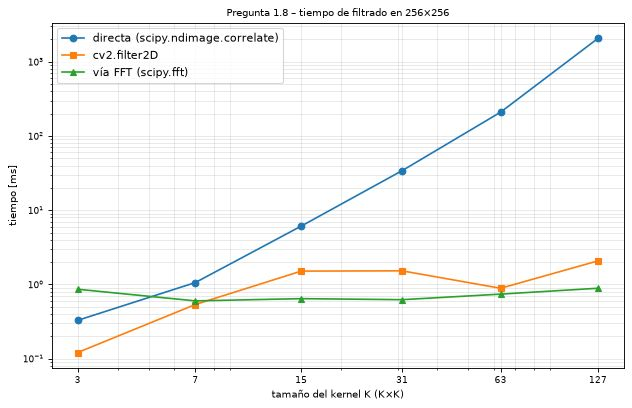

In [42]:
from scipy import fft as sfft

Nimg = 256
imgt = IMG["camara"][:Nimg, :Nimg].astype(np.float64)
rng_k = np.random.default_rng(SEMILLA)
Ks = [3, 7, 15, 31, 63, 127]
filas = []
for K in Ks:
    ker = rng_k.random((K, K)); ker /= ker.sum()
    n_rep = 5 if K <= 31 else 2
    t_dir = medir(lambda: ndi.correlate(imgt, ker, mode="wrap"), n=n_rep, calentamiento=1)
    t_cv = medir(lambda: cv2.filter2D(imgt, -1, ker), n=n_rep, calentamiento=1)
    def via_fft():
        Fk = sfft.rfft2(ker, s=imgt.shape)                               # FFT del kernel (con relleno de ceros hasta Nimg×Nimg)
        return sfft.irfft2(sfft.rfft2(imgt) * Fk, s=imgt.shape)
    t_fft = medir(via_fft, n=10, calentamiento=1)
    filas.append({"K": K, "directa ndimage [ms]": t_dir * 1e3, "cv2.filter2D [ms]": t_cv * 1e3, "FFT [ms]": t_fft * 1e3,
                  "directa / FFT (×)": t_dir / t_fft, "operaciones directas N²K² (×10⁶)": Nimg ** 2 * K ** 2 / 1e6,
                  "operaciones FFT ≈ 3·N²·log₂N² (×10⁶)": 3 * Nimg ** 2 * np.log2(Nimg ** 2) / 1e6})
df_t = pd.DataFrame(filas).set_index("K")
display(df_t.style.format("{:.3f}").highlight_min(axis=1, subset=["directa ndimage [ms]", "FFT [ms]"], color="#b7e4c7"))
cruce = next((K for K in Ks if df_t.loc[K, "FFT [ms]"] < df_t.loc[K, "directa ndimage [ms]"]), None)
print(f"Punto de cruce medido: la FFT supera a la convolución directa (ndimage) a partir de K = {cruce}")
cruce_cv = next((K for K in Ks if df_t.loc[K, "FFT [ms]"] < df_t.loc[K, "cv2.filter2D [ms]"]), None)
print(f"Frente a cv2.filter2D (que ya usa DFT internamente para kernels grandes), la FFT manual gana desde K = {cruce_cv}")

plt.figure(figsize=(8, 5.2))
plt.loglog(Ks, df_t["directa ndimage [ms]"], "o-", label="directa (scipy.ndimage.correlate)")
plt.loglog(Ks, df_t["cv2.filter2D [ms]"], "s-", label="cv2.filter2D")
plt.loglog(Ks, df_t["FFT [ms]"], "^-", label="vía FFT (scipy.fft)")
plt.xlabel("tamaño del kernel K (K×K)"); plt.ylabel("tiempo [ms]"); plt.title(f"Pregunta 1.8 – tiempo de filtrado en {Nimg}×{Nimg}")
plt.grid(alpha=.3, which="both"); plt.legend(); plt.xticks(Ks, [str(k) for k in Ks]); plt.tight_layout(); plt.show()

# ### Pregunta 1.8 – ¿Cuándo conviene filtrar en frecuencia en lugar de convolucionar en el espacio?
#
# **Costes.** La convolución directa de una imagen $N\times N$ con un kernel $K\times K$ cuesta $O(N^2K^2)$ operaciones: crece **con el cuadrado del tamaño del kernel**. La vía frecuencial cuesta dos FFT directas y una inversa más un producto: $O(N^2\log N)$, **independiente de K** (el kernel solo se rellena con ceros al tamaño de la imagen). Con N=256, la FFT necesita ≈ 3·10⁶ operaciones, y la convolución directa K²·N² = 0.6·10⁶ (K=3), 3.2·10⁶ (K=7), 14.7·10⁶ (K=15), 63·10⁶ (K=31) o 1057·10⁶ (K=127), lo que sitúa el **punto de cruce teórico en K ≈ 7**.
#
# **Evidencia medida** (tabla anterior, 256×256; los milisegundos varían algo entre máquinas y ejecuciones, el orden de magnitud no):
# * **Kernels pequeños favorecen el espacio:** con K=3 la convolución directa (≈ 0.3–0.4 ms) es más rápida que la vía FFT (≈ 0.6–0.8 ms) y `cv2.filter2D` (≈ 0.1 ms) las supera con holgura; el coste fijo de las FFT no compensa.
# * **Punto de cruce medido:** la FFT supera a la convolución directa de `ndimage` a partir de **K=7** (≈ 0.6 ms frente a ≈ 1.06 ms), de acuerdo con la estimación teórica K≈7.
# * **Kernels grandes favorecen la FFT:** el tiempo de la FFT es prácticamente constante (≈ 0.6–1.0 ms para cualquier K), mientras que el de la convolución directa crece como K²: ≈ 34 ms con K=31 (≈ 55–60× más lenta que la FFT), ≈ 210 ms con K=63 (≈ 300–350×) y ≈ 2.1–2.4 s con K=127 (≈ 2000–3000×).
# * **Ojo con OpenCV:** `cv2.filter2D` conmuta internamente a un algoritmo basado en DFT para kernels grandes (su tiempo se aplana en ≈ 1–2 ms desde K≈15), así que en la práctica no hace falta pasar a mano a frecuencia con OpenCV; la FFT manual solo gana por un factor de ~2–3 en esta medición.
#
# **Cuándo conviene filtrar en frecuencia:** (1) kernels grandes (K > ~7–15 con una implementación directa); (2) filtros que se **diseñan** naturalmente en frecuencia (notch, pasa-banda, Butterworth, homomórfico), aunque su kernel espacial sea enorme o no esté acotado; (3) cuando se aplican muchos filtros a la misma imagen (se reutiliza la FFT de la imagen); (4) deconvolución. **Cuándo conviene el espacio:** kernels pequeños (3×3, 5×5), filtros no lineales (mediana, bilateral, morfología: no tienen respuesta en frecuencia), filtros locales de soporte compacto y casos donde el coste fijo y la periodicidad implícita de la FFT sean un problema.

# ---
# # Módulo E – Filtros direccionales y de textura: Gabor (3 %)
#
# Un filtro de Gabor es una sinusoide modulada por una envolvente gaussiana: $g(x,y)=\exp\!\big(-\tfrac{x'^2+\gamma^2 y'^2}{2\sigma^2}\big)\cos\!\big(2\pi x'/\lambda+\psi\big)$, con $x'=x\cos\theta+y\sin\theta$. Responde a **franjas de una longitud de onda λ y una orientación θ** concretas: es el modelo clásico de las células simples de la corteza visual y un buen descriptor de **textura**.
#
# **Parámetros elegidos y documentados** (en `gabor_utils.py`):
# * θ ∈ {0°, 45°, 90°, 135°} (4 orientaciones) y λ ∈ {4, 8, 16} píxeles (3 escalas) → **12 filtros**.
# * σ = 0.56·λ (ancho de banda ≈ 1 octava: cada kernel contiene el mismo nº de ciclos dentro de la envolvente), γ = 0.5 (envolvente elíptica), ψ = 0 (kernel par) y tamaño de kernel $2\lceil3\sigma\rceil+1$.
# * Cada kernel se **centra** (media 0, para ignorar el brillo medio) y se **normaliza por su norma L1** (energías comparables entre escalas).
# * Las respuestas se calculan con `cv2.filter2D` sobre la imagen en [0,1] con borde reflejado.
#
# La función `vector_gabor` se define en `gabor_utils.py` (se reutilizará en la Parte 2) y aquí se importa y se muestra su código.

In [43]:
import inspect
import importlib
import gabor_utils
importlib.reload(gabor_utils)
from gabor_utils import (construir_banco, respuestas_gabor, vector_gabor, vector_gabor_invariante,
                         nombres_caracteristicas, LONGITUDES_ONDA, ORIENTACIONES_GRADOS)

print(inspect.getsource(vector_gabor))
BANCO = construir_banco()
print(f"Banco de {len(BANCO)} filtros:", [(lam, th) for lam, th, _ in BANCO][:4], "...")
print("Tamaños de kernel por λ:", {lam: BANCO[i * 4][2].shape for i, lam in enumerate(LONGITUDES_ONDA)})

def vector_gabor(img, banco=None):
    """Vector de textura de Gabor: media y desviación estándar de la energía (respuesta²) de cada filtro.

    Parameters
    ----------
    img : ndarray
        Imagen en gris (uint8 o float). Si es uint8 se normaliza a [0,1].
    banco : list, optional
        Banco de ``construir_banco`` (por defecto 3 longitudes de onda × 4 orientaciones).

    Returns
    -------
    ndarray de longitud 2·len(banco) (24 con el banco por defecto), ordenado por
    (lambda, theta, [media, desviación]) y aplanado: es decir,
    ``v.reshape(n_lambdas, n_thetas, 2)[i, j] = (media, std)`` de la energía del kernel (lambda_i, theta_j).
    """
    banco = banco or construir_banco()
    caracteristicas = []
    for r in respuestas_gabor(img, banco):
        energia = r ** 2
        caracteristicas.extend([energia.mean(), energia.std()])
    return np.asarray(caracteristicas, dtype=np.float64)

Banco de 12 filtros: [(4, 0), (4, 45), (4, 90), (4, 135)] ...
Tamaños de kerne

# ## E.1 Banco de Gabor: kernels y respuestas

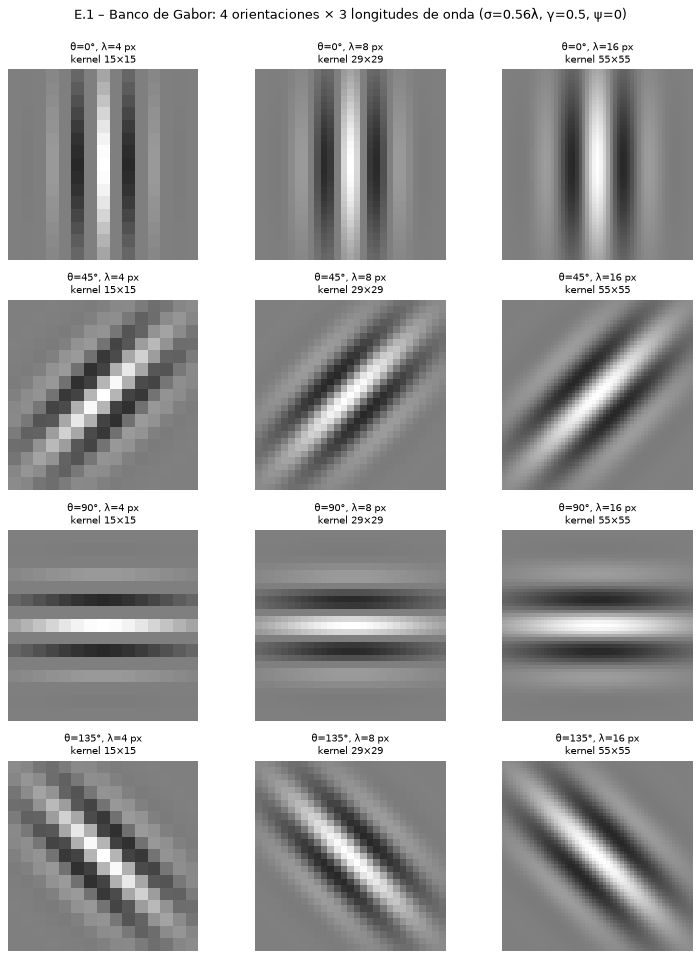

In [44]:
# ---- 12 kernels en una cuadrícula 4×3 (filas = θ, columnas = λ) ----
fig, ejes = plt.subplots(len(ORIENTACIONES_GRADOS), len(LONGITUDES_ONDA), figsize=(9.6, 12))
for idx, (lam, th, k) in enumerate(BANCO):
    i, j = ORIENTACIONES_GRADOS.index(th), LONGITUDES_ONDA.index(lam)
    lim = np.abs(k).max()
    ejes[i, j].imshow(k, cmap="gray", vmin=-lim, vmax=lim)
    ejes[i, j].set_title(f"θ={th}°, λ={lam} px\nkernel {k.shape[0]}×{k.shape[1]}", fontsize=9); ejes[i, j].axis("off")
plt.suptitle("E.1 – Banco de Gabor: 4 orientaciones × 3 longitudes de onda (σ=0.56λ, γ=0.5, ψ=0)", y=0.995); plt.tight_layout(); plt.show()

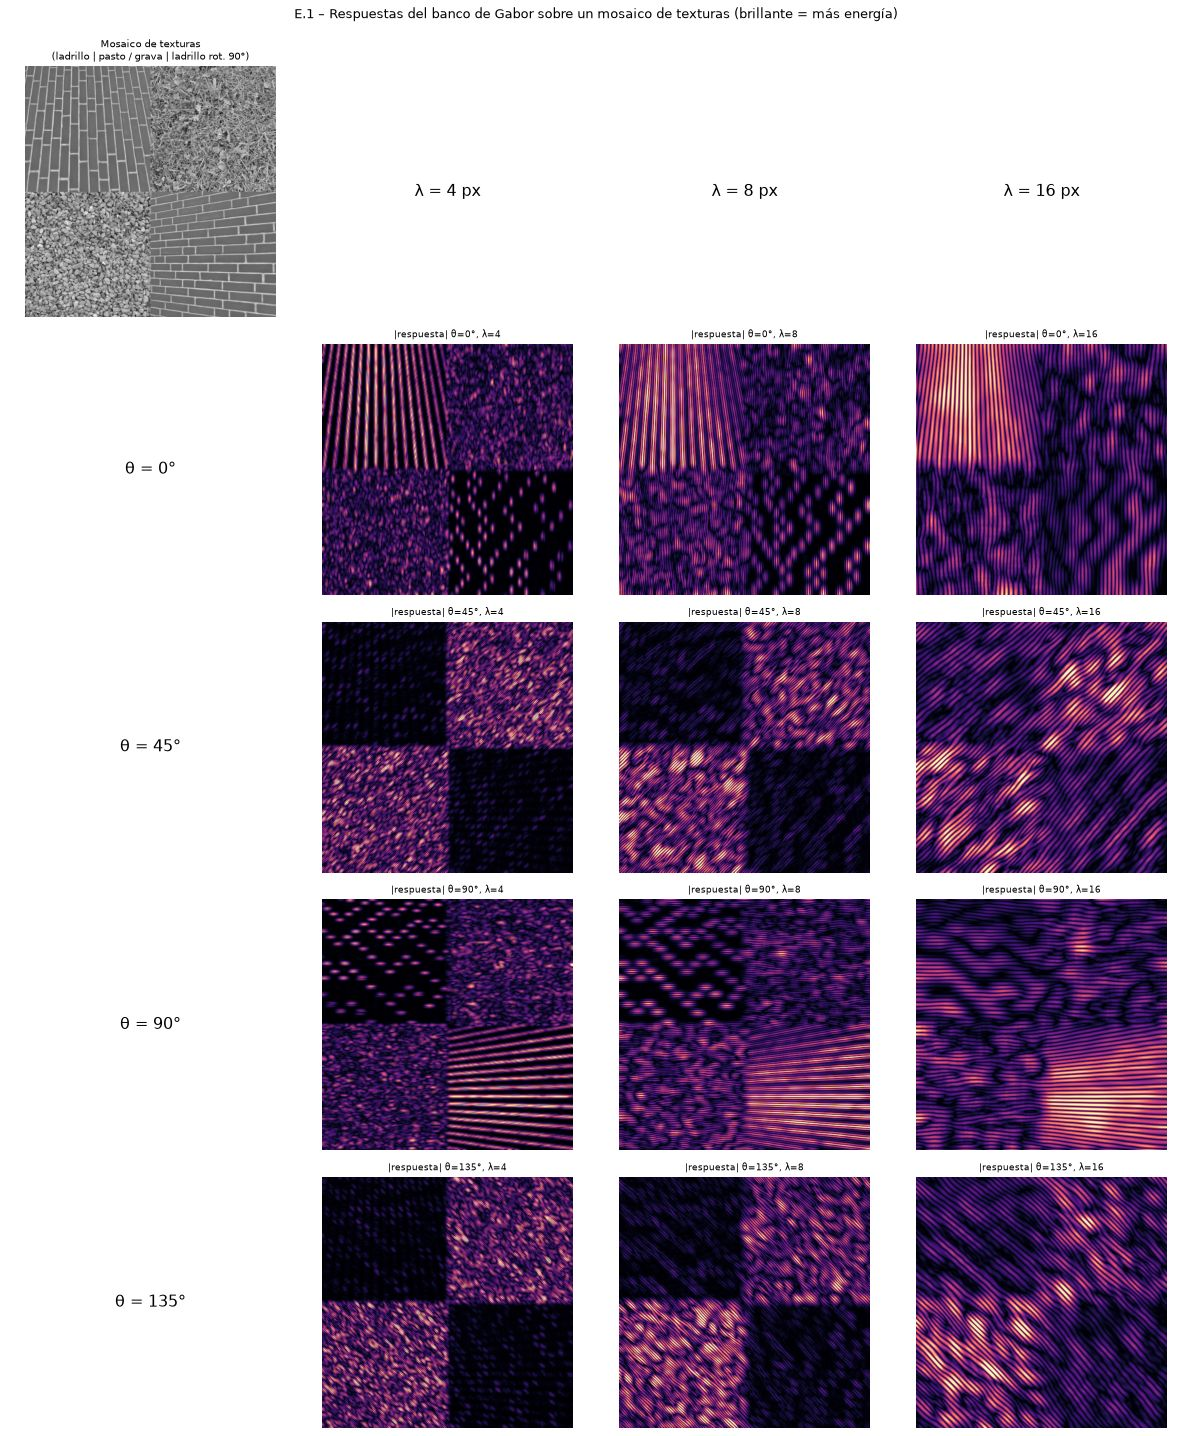

,ladrillo,pasto,grava,ladrillo rot. 90°
λ=4 θ=0°,1.15e-03,4.21e-04,4.16e-04,2.01e-04
λ=4 θ=45°,7.41e-06,2.24e-04,2.13e-04,6.75e-06
λ=4 θ=90°,2.02e-04,4.41e-04,4.33e-04,1.14e-03
λ=4 θ=135°,6.55e-06,2.24e-04,2.66e-04,7.25e-06
λ=8 θ=0°,1.18e-03,2.51e-04,3.91e-04,2.29e-04
λ=8 θ=45°,1.39e-05,1.97e-04,2.97e-04,1.46e-05
λ=8 θ=90°,2.28e-04,2.44e-04,4.26e-04,1.18e-03
λ=8 θ=135°,1.51e-05,1.94e-04,3.74e-04,1.56e-05
λ=16 θ=0°,9.31e-04,1.54e-04,1.86e-04,1.49e-04
λ=16 θ=45°,3.60e-05,1.28e-04,1.34e-04,3.98e-05


In [45]:
# ---- Imagen con texturas: mosaico de cuatro cuadrantes (ladrillo, pasto, grava, ladrillo rotado 90°) ----
q = TAM // 2
mosaico = np.zeros((TAM, TAM), np.uint8)
mosaico[:q, :q] = cv2.resize(IMG["ladrillo"], (q, q), interpolation=cv2.INTER_AREA)
mosaico[:q, q:] = cv2.resize(IMG["pasto"], (q, q), interpolation=cv2.INTER_AREA)
mosaico[q:, :q] = cv2.resize(IMG["grava"], (q, q), interpolation=cv2.INTER_AREA)
mosaico[q:, q:] = np.rot90(cv2.resize(IMG["ladrillo"], (q, q), interpolation=cv2.INTER_AREA))

resp = respuestas_gabor(mosaico, BANCO)
fig, ejes = plt.subplots(len(ORIENTACIONES_GRADOS) + 1, len(LONGITUDES_ONDA) + 1, figsize=(15, 18))
for ax in ejes.ravel():
    ax.axis("off")
ejes[0, 0].imshow(mosaico, cmap="gray"); ejes[0, 0].set_title("Mosaico de texturas\n(ladrillo | pasto / grava | ladrillo rot. 90°)", fontsize=9)
for j, lam in enumerate(LONGITUDES_ONDA):
    ejes[0, j + 1].text(0.5, 0.5, f"λ = {lam} px", ha="center", va="center", fontsize=14);
for i, th in enumerate(ORIENTACIONES_GRADOS):
    ejes[i + 1, 0].text(0.5, 0.5, f"θ = {th}°", ha="center", va="center", fontsize=14)
for (lam, th, _), r in zip(BANCO, resp):
    i, j = ORIENTACIONES_GRADOS.index(th), LONGITUDES_ONDA.index(lam)
    e = np.abs(r)
    ejes[i + 1, j + 1].imshow(e, cmap="magma", vmin=0, vmax=np.percentile(e, 99.5))
    ejes[i + 1, j + 1].set_title(f"|respuesta| θ={th}°, λ={lam}", fontsize=8)
plt.suptitle("E.1 – Respuestas del banco de Gabor sobre un mosaico de texturas (brillante = más energía)", y=0.995); plt.tight_layout(); plt.show()

# Energía media por cuadrante y filtro: qué filtros "ven" cada textura
nombres_cuad = {"ladrillo": (slice(0, q), slice(0, q)), "pasto": (slice(0, q), slice(q, TAM)), "grava": (slice(q, TAM), slice(0, q)), "ladrillo rot. 90°": (slice(q, TAM), slice(q, TAM))}
filas = {n: {f"λ={lam} θ={th}°": (r[sl] ** 2).mean() for (lam, th, _), r in zip(BANCO, resp)} for n, sl in nombres_cuad.items()}
df_cuad = pd.DataFrame(filas)
display(df_cuad.style.format("{:.2e}").background_gradient(axis=0, cmap="Blues"))

# ## E.2 Vector de textura (24 características) y comparación entre texturas
#
# Para cada una de las 12 respuestas se calcula la **media** y la **desviación estándar** de la energía (respuesta²): 12×2 = **24 características**. Se compara `ladrillo`, `pasto` y `grava` (texturas de `skimage`): gráfica de barras, distancias entre vectores y una prueba de separabilidad (parches de 256×256 de la misma textura frente a texturas distintas).

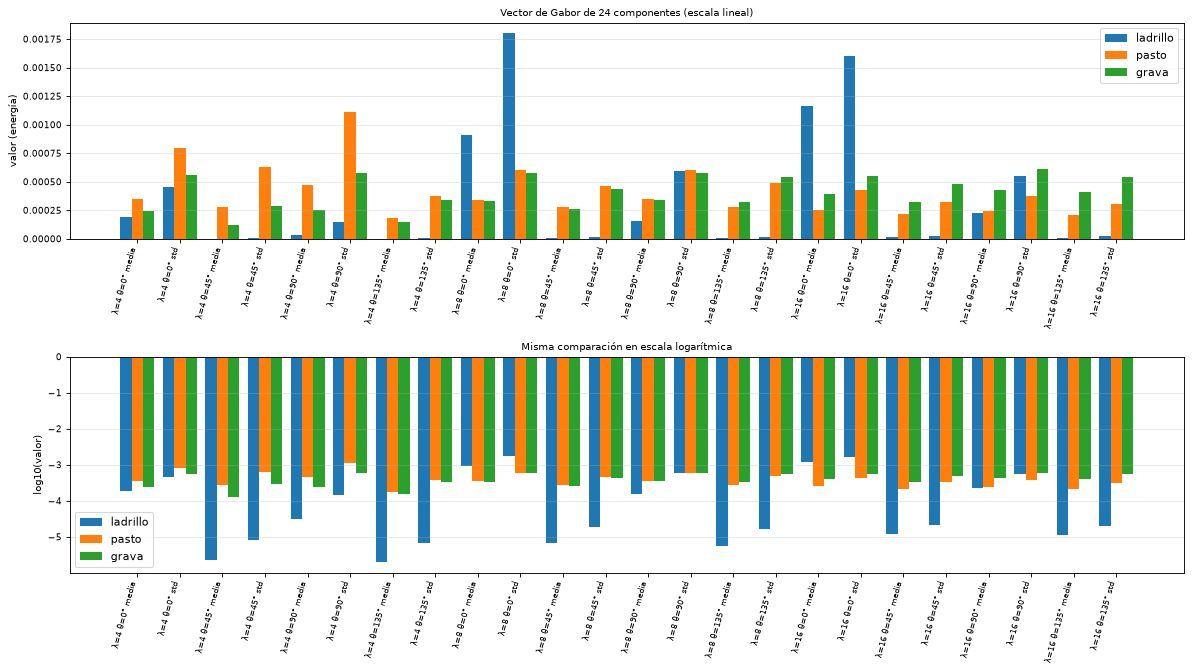

,ladrillo,pasto,grava
ladrillo,0.000,5.833,5.690
pasto,5.833,0.000,0.902
grava,5.690,0.902,0.000


,distancia media intra-clase,inter-clase vs pasto,inter-clase vs grava,inter/intra (mínimo),inter-clase vs ladrillo
ladrillo,0.758,5.863,5.714,7.536,nan
pasto,0.416,nan,0.950,2.285,5.863
grava,0.309,0.950,nan,3.072,5.714


In [46]:
TEXTURAS = {n: IMG[n] for n in ("ladrillo", "pasto", "grava") + (("textura_propia",) if "textura_propia" in IMG else ())}
V = {n: vector_gabor(im) for n, im in TEXTURAS.items()}
etiquetas = nombres_caracteristicas()

fig, ejes = plt.subplots(2, 1, figsize=(15, 8.5))
ancho = 0.8 / len(V)
x = np.arange(24)
for k, (n, v) in enumerate(V.items()):
    ejes[0].bar(x + k * ancho, v, ancho, label=n)
    ejes[1].bar(x + k * ancho, np.log10(v), ancho, label=n)
ejes[0].set_ylabel("valor (energía)"); ejes[0].set_title("Vector de Gabor de 24 componentes (escala lineal)")
ejes[1].set_ylabel("log10(valor)"); ejes[1].set_title("Misma comparación en escala logarítmica")
for ax in ejes:
    ax.set_xticks(x + ancho * (len(V) - 1) / 2); ax.set_xticklabels(etiquetas, rotation=75, ha="right", fontsize=7); ax.legend(); ax.grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()


def dist_rel(a, b):
    """Distancia euclídea entre vectores de Gabor en escala log10, que compara energías relativas."""
    return np.linalg.norm(np.log10(a) - np.log10(b))


nom = list(V)
display(pd.DataFrame([[dist_rel(V[a], V[b]) for b in nom] for a in nom], index=nom, columns=nom).style.format("{:.3f}").set_caption("Distancia euclídea entre vectores (log10) de texturas completas"))

# Separabilidad: 4 parches de 256×256 por textura (intra-clase) frente a otras texturas (inter-clase)
parches = {n: [vector_gabor(im[i:i + 256, j:j + 256]) for i in (0, 256) for j in (0, 256)] for n, im in TEXTURAS.items()}
filas = []
for a in nom:
    intra = np.mean([dist_rel(p, r) for ia, p in enumerate(parches[a]) for ib, r in enumerate(parches[a]) if ia < ib])
    inter = {b: np.mean([dist_rel(p, r) for p in parches[a] for r in parches[b]]) for b in nom if b != a}
    fila = {"distancia media intra-clase": intra}
    fila |= {f"inter-clase vs {b}": d for b, d in inter.items()}
    fila["inter/intra (mínimo)"] = min(inter.values()) / intra
    filas.append(pd.Series(fila, name=a))
display(pd.DataFrame(filas).style.format("{:.3f}"))

# **Observaciones (E.1–E.2).**
# * **Respuestas por cuadrante** (figura y tabla de energía media): el **ladrillo** (juntas verticales largas) excita sobre todo θ=0° (franjas verticales): 1.15·10⁻³ con λ=4, 1.18·10⁻³ con λ=8 y 9.3·10⁻⁴ con λ=16, frente a 2.0–2.3·10⁻⁴ en θ=90° y solo 0.7–4.6·10⁻⁵ en las diagonales. El **ladrillo rotado 90°** *intercambia* esas energías (θ=90° pasa a 1.14·10⁻³ y θ=0° a 2.0·10⁻⁴): es la base de la pregunta 1.9. El **pasto** y la **grava** son texturas casi isótropas: reparten la energía entre las cuatro orientaciones (entre 1.2·10⁻⁴ y 4.4·10⁻⁴ en el pasto; entre 1.3·10⁻⁴ y 4.3·10⁻⁴ en la grava, es decir, dentro de un factor ≈ 2–4).
# * **Distancias** (log10, textura completa): ladrillo–pasto **5.83** y ladrillo–grava **5.69**, mientras que pasto–grava es solo **0.90**: el ladrillo (muy direccional) se separa claramente de las texturas naturales isótropas, que son más parecidas entre sí. Con parches de 256×256, la distancia media **intra-clase** es 0.758 (ladrillo), 0.416 (pasto) y 0.309 (grava), y la inter-clase más cercana es 5.71 (ladrillo, a la grava), 0.950 (pasto–grava) y 0.950: cociente inter/intra de **7.5 (ladrillo), 2.3 (pasto) y 3.1 (grava)**; es decir, aun las dos texturas más parecidas (pasto y grava) quedan separadas por un margen de ≈ 2–3 veces la variación interna.
# * Para clasificar (Parte 2) conviene **estandarizar** las 24 características o usar log10: las energías son muy pequeñas (10⁻⁶–10⁻³) y cambian en órdenes de magnitud entre filtros.

# ## Pregunta 1.9 – Rotación de 90° y descriptor invariante a rotación
#
# **Prueba:** se rota la textura 90° (`np.rot90`) y se compara el vector antes/después, con el descriptor original (24 componentes) y con las dos versiones invariantes de `gabor_utils` (`promedio`: media/desviación **a través de θ** por λ → 12 componentes; `alineado`: se desplaza circularmente el vector hasta alinear la orientación dominante → 24 componentes).

Distancia relativa ‖v(textura) − v(textura rotada 90°)‖ / ‖v(textura)‖ (0 = invariante):


,estándar (24),invariante 'promedio' (12),invariante 'alineado' (24)
ladrillo,9.590e-01,1.258e-16,8.763e-17
pasto,2.726e-01,1.584e-16,1.853e-16
grava,1.261e-01,1.005e-16,2.175e-16


Ladrillo: ‖v_rot − permutación de v (θ → θ+90°)‖/‖v‖ = 8.76e-17
Energía media por orientación (suma sobre λ), antes -> después de rotar:
           antes  después (rot90)
θ=0°   2.265e-03        4.095e-04
θ=45°  2.073e-05        1.876e-05
θ=90°  4.095e-04        2.265e-03
θ=135° 1.876e-05        2.073e-05


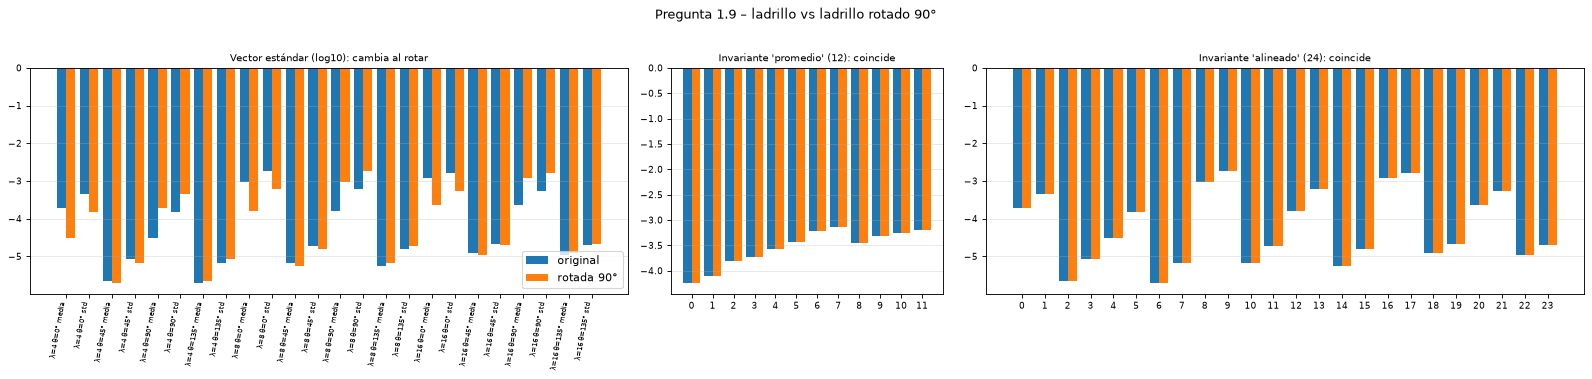

Distancia relativa con ladrillo como referencia (en escala lineal):


,rot. 90° (misma textura),rot. 45° (misma textura),"otras texturas (pasto, grava)"
estándar,9.590e-01,1.368e+00,8.215e-01
promedio,1.258e-16,7.656e-02,7.890e-01
alineado,8.763e-17,8.046e-02,8.093e-01


In [47]:
def dist_relativa(a, b):
    """‖a − b‖ / ‖a‖ (distancia relativa en escala lineal)."""
    return np.linalg.norm(a - b) / np.linalg.norm(a)


def informe_rotacion(img_textura):
    rot = np.rot90(img_textura)
    v, vr = vector_gabor(img_textura), vector_gabor(rot)
    vp, vpr = vector_gabor_invariante(img_textura, modo="promedio"), vector_gabor_invariante(rot, modo="promedio")
    va, var_ = vector_gabor_invariante(img_textura, modo="alineado"), vector_gabor_invariante(rot, modo="alineado")
    return {"estándar (24)": dist_relativa(v, vr), "invariante 'promedio' (12)": dist_relativa(vp, vpr), "invariante 'alineado' (24)": dist_relativa(va, var_)}


filas = {n: informe_rotacion(im) for n, im in TEXTURAS.items()}
df_rot = pd.DataFrame(filas).T
print("Distancia relativa ‖v(textura) − v(textura rotada 90°)‖ / ‖v(textura)‖ (0 = invariante):")
display(df_rot.style.format("{:.3e}"))

# Las respuestas se PERMUTAN: v_rot[λ, θ] = v[λ, θ+90°]. Comprobación explícita en el ladrillo
tex = IMG["ladrillo"]
v = vector_gabor(tex).reshape(3, 4, 2)
vr = vector_gabor(np.rot90(tex)).reshape(3, 4, 2)
perm = np.roll(v, -2, axis=1)                      # desplazar 2 posiciones en θ (= 90°): 0°↔90°, 45°↔135°
print(f"Ladrillo: ‖v_rot − permutación de v (θ → θ+90°)‖/‖v‖ = {np.linalg.norm(vr - perm) / np.linalg.norm(v):.2e}")
print("Energía media por orientación (suma sobre λ), antes -> después de rotar:")
print(pd.DataFrame({"antes": v[:, :, 0].sum(axis=0), "después (rot90)": vr[:, :, 0].sum(axis=0)}, index=[f"θ={t}°" for t in ORIENTACIONES_GRADOS]).to_string(float_format=lambda x: f"{x:.3e}"))

# Figura: vectores antes/después y las versiones invariantes
fig, ejes = plt.subplots(1, 3, figsize=(20, 4.6), gridspec_kw={"width_ratios": [2.2, 1, 2.2]})
x = np.arange(24)
ejes[0].bar(x - .2, np.log10(vector_gabor(tex)), .4, label="original"); ejes[0].bar(x + .2, np.log10(vector_gabor(np.rot90(tex))), .4, label="rotada 90°")
ejes[0].set_xticks(x); ejes[0].set_xticklabels(etiquetas, rotation=80, ha="right", fontsize=6); ejes[0].set_title("Vector estándar (log10): cambia al rotar"); ejes[0].legend()
xi = np.arange(12)
ejes[1].bar(xi - .2, np.log10(vector_gabor_invariante(tex)), .4); ejes[1].bar(xi + .2, np.log10(vector_gabor_invariante(np.rot90(tex))), .4)
ejes[1].set_title("Invariante 'promedio' (12): coincide"); ejes[1].set_xticks(xi)
ejes[2].bar(x - .2, np.log10(vector_gabor_invariante(tex, modo="alineado")), .4); ejes[2].bar(x + .2, np.log10(vector_gabor_invariante(np.rot90(tex), modo="alineado")), .4)
ejes[2].set_title("Invariante 'alineado' (24): coincide"); ejes[2].set_xticks(x)
for ax in ejes:
    ax.grid(alpha=.3, axis="y")
plt.suptitle("Pregunta 1.9 – ladrillo vs ladrillo rotado 90°", y=1.02); plt.tight_layout(); plt.show()

# Límite: rotación de 45° (el banco de 4 orientaciones no es cerrado bajo 45° y hay interpolación) y poder discriminante de los invariantes
rot45 = ndi.rotate(tex, 45, reshape=False, mode="reflect")
sep = {}
for modo in ("estándar", "promedio", "alineado"):
    f = (lambda im: vector_gabor(im)) if modo == "estándar" else (lambda im, m=modo: vector_gabor_invariante(im, modo=m))
    d_rot90 = dist_relativa(f(tex), f(np.rot90(tex)))
    d_rot45 = dist_relativa(f(tex), f(rot45))
    d_otras = np.mean([dist_relativa(f(tex), f(IMG[o])) for o in ("pasto", "grava")])
    sep[modo] = {"rot. 90° (misma textura)": d_rot90, "rot. 45° (misma textura)": d_rot45, "otras texturas (pasto, grava)": d_otras}
print("Distancia relativa con ladrillo como referencia (en escala lineal):")
display(pd.DataFrame(sep).T.style.format("{:.3e}"))

# ### Pregunta 1.9 – ¿Qué ocurre con la respuesta del banco si se rota el objeto 90°? ¿Cómo lograr un descriptor invariante a rotación?
#
# **Qué pasa.** Un filtro de Gabor está sintonizado a una orientación θ. Si se rota la imagen 90°, las franjas que antes estaban a θ aparecen ahora a θ+90°, así que **la respuesta del filtro θ pasa al filtro θ+90°** (y la de λ no cambia): las 12 respuestas **se permutan entre orientaciones** (0°↔90°, 45°↔135°) y se mantienen las escalas. Para un banco de 4 orientaciones equiespaciadas esto es una **permutación circular de 2 posiciones** del eje θ (por simetría del kernel par, θ y θ+180° son el mismo filtro). Como el vector estándar concatena las componentes en un orden fijo, la permutación **cambia el vector aunque la textura sea la misma**: un clasificador entrenado con una orientación fallaría con otra.
#
# **Evidencia (celdas anteriores).**
# * Con `np.rot90` el vector estándar del ladrillo cambia mucho; con el reordenamiento θ → θ+90° coincide con el original con un error relativo de 8.8·10⁻¹⁷ (salida "‖v_rot − permutación de v‖"): la rotación es *exactamente* una permutación (el kernel rotado 90° es el kernel de otra orientación, y la imagen rotada 90° se muestrea en la misma rejilla). Fíjate también en la energía por orientación: la energía de 0° pasa a 90° y viceversa.
# * Distancia relativa antes/después de rotar (tabla `df_rot`): el vector estándar cambia **0.959** en el ladrillo (muy direccional: su energía en θ=0° pasa de 2.27·10⁻³ a 4.1·10⁻⁴, y la de θ=90° al revés), **0.273** en el pasto y **0.126** en la grava (más isótropos, pero aun así distintos); los dos descriptores invariantes dan **≈ 1e-16 (precisión de máquina) en las tres texturas**: son exactamente invariantes a rotaciones de 90°.
#
# **Cómo construir un descriptor invariante.**
# 1. **Agrupar por λ y resumir a través de θ** (modo `promedio`): para cada escala, la media y la desviación estándar de las energías a lo largo de las orientaciones (4 números por λ → 12 en total). Una permutación de θ no cambia ninguna media ni desviación. Invariante a cualquier permutación de las orientaciones; pierde información sobre *qué* orientación domina (conserva cuánta anisotropía hay a través de la desviación a través de θ).
# 2. **Alinear a la orientación dominante** (modo `alineado`): se desplaza circularmente el vector en θ hasta que la orientación de mayor energía (suma sobre λ) quede en la primera posición; conserva las 24 componentes (la estructura relativa entre orientaciones). Es invariante a rotaciones de 90° si la orientación dominante es única (con empates la elección no es estable).
# 3. (No implementado aquí) Usar más orientaciones y alinear en cada escala; o magnitud de la DFT sobre el eje θ (invariante a desplazamientos circulares); o aumentar los datos de entrenamiento con rotaciones.
#
# **Límites (tabla `sep`, referencia: ladrillo).** Estos descriptores son exactos para múltiplos de 90° (el banco es cerrado bajo esa rotación). Para otros ángulos la invariancia es solo aproximada: con una rotación de **45°** (interpolada con `scipy.ndimage.rotate`, que además introduce bordes) el vector estándar se aleja **1.37** (relativo) de su original, *más* que la distancia a otras texturas (0.82 en promedio con pasto y grava), es decir, deja de servir para reconocer la textura; los invariantes cambian solo **0.077** (`promedio`) y **0.080** (`alineado`), unas 10 veces menos que la distancia a otras texturas (0.789 y 0.809): la discriminación se mantiene. A cambio de la invariancia, el descriptor `promedio` pierde la información de orientación, así que dos texturas que solo se diferencian por su orientación (franjas verticales frente a horizontales) pasan a ser indistinguibles, lo que es deseable o no según el problema.

# ---
# # Extras (opcionales, suman bonificación)
#
# ## X.1 Filtro homomórfico
#
# Una imagen se modela como $f(x,y)=i(x,y)\,r(x,y)$: **iluminación** $i$ (varía lentamente → bajas frecuencias) por **reflectancia** $r$ (detalles y bordes → altas frecuencias). El producto se vuelve suma con el logaritmo: $\ln f=\ln i+\ln r$. Se filtra $\ln f$ con un filtro que **atenúa las bajas frecuencias (γ_L<1)** y deja o **refuerza las altas (γ_H≥1)**:
#
# $$H(u,v)=(\gamma_H-\gamma_L)\Big[1-e^{-c\,D^2(u,v)/D_0^2}\Big]+\gamma_L$$
#
# Cadena completa: $\ln(1+f)\to$ FFT $\to H\cdot F\to$ IFFT $\to\exp(\cdot)-1$. Para probarlo se **simula** una iluminación desigual multiplicando `camara` por un campo suave (viñeteado + degradado); como se conoce la imagen original, se puede medir la recuperación.

,CV de la media local (64×64),PSNR vs original (tras ajuste lineal),SSIM vs original (tras ajuste lineal)
original (referencia),0.496,nan,1.000
con iluminación desigual,0.616,15.161,0.769
"homomórfico (γL=0.5, γH=1.0, D0=4)",0.415,14.796,0.789
ecualización de histograma,0.484,16.864,0.844


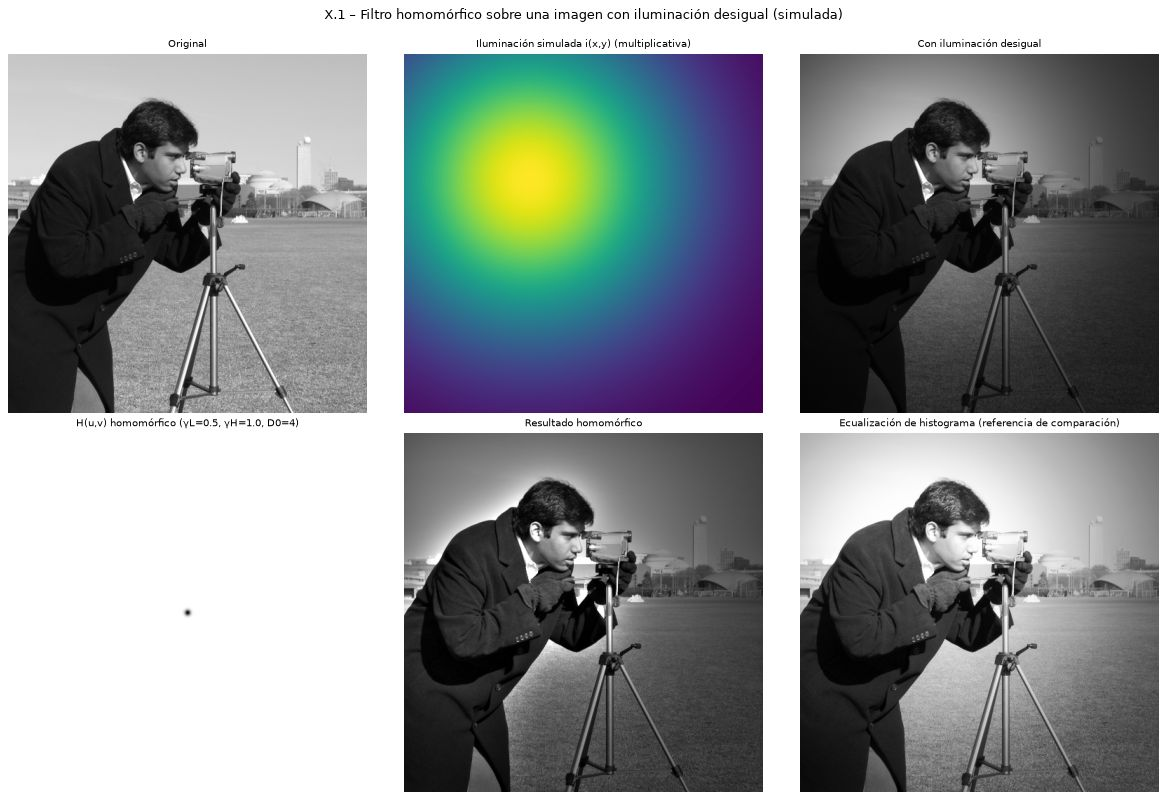

In [48]:
def filtro_homomorfico(img, gamma_L=0.5, gamma_H=1.5, D0=30, c=1.0, pad=True):
    """Filtrado homomórfico: log(1+f) -> FFT -> H(u,v) -> IFFT -> exp. Devuelve float64 (sin normalizar)."""
    f = img.astype(np.float64)
    M, N = f.shape

    def H_homo(forma):
        D = distancias(forma, ref=(M, N))                     # D en ciclos por imagen original
        return (gamma_H - gamma_L) * (1.0 - np.exp(-c * D ** 2 / D0 ** 2)) + gamma_L

    logf = np.log1p(f)                                        # log(1+f): evita log(0)
    g_log, H, _ = aplicar_H(logf, H_homo, pad=pad)
    return np.expm1(g_log), H


# Iluminación desigual simulada (multiplicativa): vignetting gaussiano + degradado lateral
yy, xx = np.mgrid[0:TAM, 0:TAM] / (TAM - 1.0)
iluminacion = 0.15 + 0.85 * np.exp(-(((xx - 0.3) ** 2 + (yy - 0.35) ** 2) / (2 * 0.3 ** 2))) * (0.6 + 0.4 * xx)
iluminacion /= iluminacion.max()
desigual = a_u8(IMG["camara"].astype(np.float64) * iluminacion)       # imagen mal iluminada (simulada)

homo, H_h = filtro_homomorfico(desigual, gamma_L=0.5, gamma_H=1.0, D0=4)
homo_u8 = a_u8(255 * estirar(homo, (0.5, 99.5)))                       # normalización de contraste para mostrar/evaluar
eq = cv2.equalizeHist(desigual)


def ajuste_lineal(x, ref):
    """Ajusta a·x+b (mínimos cuadrados) para que x tenga la misma escala global que ref antes de PSNR/SSIM."""
    a, b = np.polyfit(x.ravel().astype(float), ref.ravel().astype(float), 1)
    return a_u8(a * x + b)


def uniformidad(im, tam_bloque=64):
    """Coeficiente de variación de la media local (bloques): 0 = iluminación uniforme."""
    m = cv2.resize(im.astype(np.float64), (TAM // tam_bloque, TAM // tam_bloque), interpolation=cv2.INTER_AREA)
    return m.std() / m.mean()


cands = {"original (referencia)": IMG["camara"], "con iluminación desigual": desigual, "homomórfico (γL=0.5, γH=1.0, D0=4)": homo_u8, "ecualización de histograma": eq}
filas = {}
for n, im in cands.items():
    im_aj = ajuste_lineal(im, IMG["camara"])
    es_ref = n.startswith("original")
    filas[n] = {"CV de la media local (64×64)": uniformidad(im), "PSNR vs original (tras ajuste lineal)": np.nan if es_ref else psnr(IMG["camara"], im_aj),
                "SSIM vs original (tras ajuste lineal)": ssim(IMG["camara"], im_aj)}
display(pd.DataFrame(filas).T.style.format("{:.3f}"))

fig, ejes = plt.subplots(2, 3, figsize=(15, 10))
ejes[0, 0].imshow(IMG["camara"], cmap="gray", vmin=0, vmax=255); ejes[0, 0].set_title("Original")
ejes[0, 1].imshow(iluminacion, cmap="viridis"); ejes[0, 1].set_title("Iluminación simulada i(x,y) (multiplicativa)")
ejes[0, 2].imshow(desigual, cmap="gray", vmin=0, vmax=255); ejes[0, 2].set_title("Con iluminación desigual")
ejes[1, 0].imshow(H_h, cmap="gray"); ejes[1, 0].set_title("H(u,v) homomórfico (γL=0.5, γH=1.0, D0=4)")
ejes[1, 1].imshow(homo_u8, cmap="gray", vmin=0, vmax=255); ejes[1, 1].set_title("Resultado homomórfico")
ejes[1, 2].imshow(eq, cmap="gray", vmin=0, vmax=255); ejes[1, 2].set_title("Ecualización de histograma (referencia de comparación)")
for ax in ejes.ravel():
    ax.axis("off")
plt.suptitle("X.1 – Filtro homomórfico sobre una imagen con iluminación desigual (simulada)", y=0.995); plt.tight_layout(); plt.show()

# Pequeño barrido de parámetros (γL, γH, D0) para ver su efecto (última fila: control γL=γH=1, solo normalización de contraste)
filas = []
for gL, gH, D0 in [(0.5, 1.0, 4), (0.5, 1.0, 2), (0.5, 1.0, 8), (0.5, 1.0, 16), (0.3, 1.0, 4), (0.7, 1.0, 4), (0.5, 1.5, 4), (0.5, 1.5, 16), (1.0, 1.0, 4)]:
    g, _ = filtro_homomorfico(desigual, gL, gH, D0)
    gu = a_u8(255 * estirar(g, (0.5, 99.5))); gj = ajuste_lineal(gu, IMG["camara"])
    filas.append({"γL": gL, "γH": gH, "D0": D0, "CV media local": uniformidad(gu), "PSNR": psnr(IMG["camara"], gj), "SSIM": ssim(IMG["camara"], gj)})
display(pd.DataFrame(filas).set_index(["γL", "γH", "D0"]).style.format("{:.3f}"))

# ## X.2 Máscaras de energía de Laws
#
# Las **máscaras de Laws** son productos externos de cuatro vectores 1D de longitud 5: **L5** = nivel `[1 4 6 4 1]`, **E5** = bordes `[-1 -2 0 2 1]`, **S5** = manchas `[-1 0 2 0 -1]` y **R5** = ondas `[1 -4 6 -4 1]`. Los 16 productos (L5E5, E5L5, ...) se aplican a la imagen (tras restar la media local) y la "energía de textura" es el promedio local del valor absoluto de la respuesta en una ventana (aquí 15×15). Los pares simétricos (p. ej. L5E5 y E5L5) se promedian y se obtienen **9 canales** de energía por píxel.

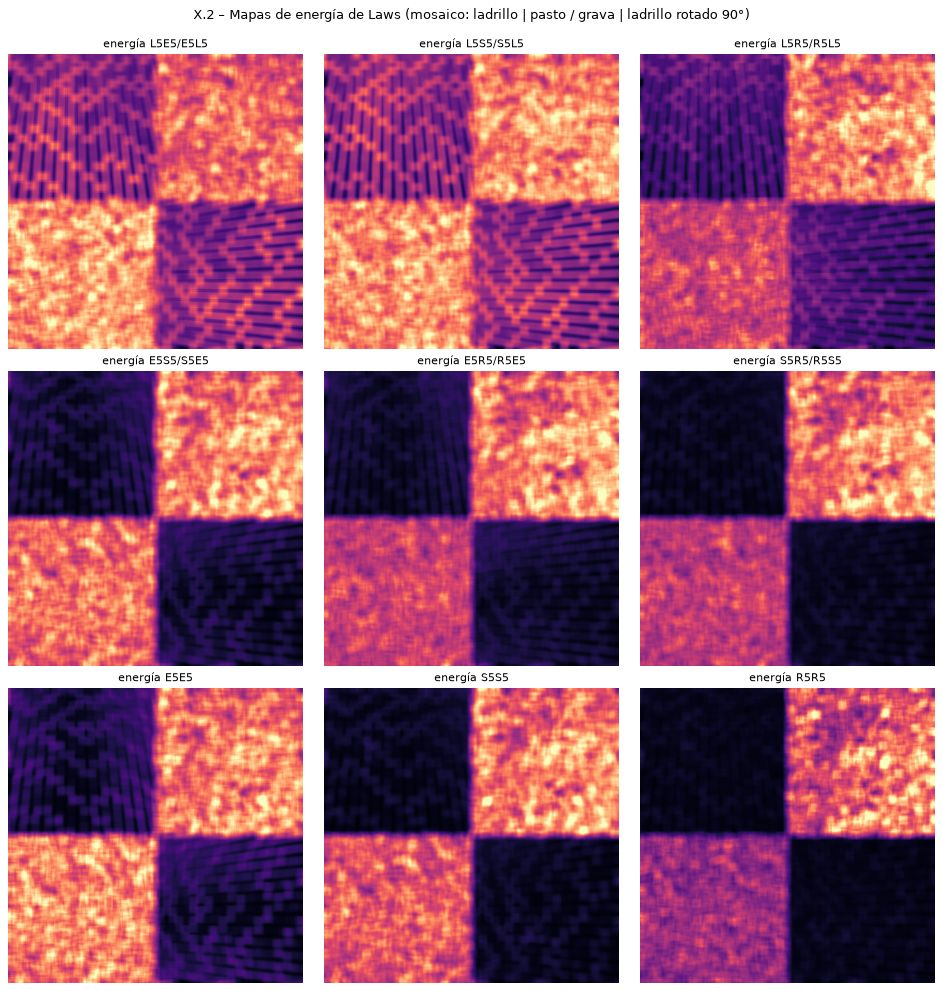

,ladrillo,pasto,grava,ladrillo rot. 90°
L5E5/E5L5,638.3,1036.3,1224.6,638.6
L5S5/S5L5,321.7,581.4,593.7,321.0
L5R5/R5L5,332.9,997.7,780.3,330.6
E5S5/S5E5,29.5,180.6,168.0,29.6
E5R5/R5E5,51.8,353.2,263.5,51.9
S5R5/R5S5,24.9,244.8,177.0,25.1
E5E5,60.5,298.6,310.0,60.6
S5S5,12.3,114.4,98.8,12.4
R5R5,57.1,624.9,410.8,58.0


Diferencia relativa entre ladrillo y ladrillo rotado 90° en los 9 canales (media 4.84e-03, máx 1.52e-02): los pares simétricos combinados son invariantes a rotación de 90°.
Sin combinar los pares, las energías se INTERCAMBIAN al rotar (media por cuadrante, ladrillo | ladrillo rot. 90°):
   L5E5:    910.6 |    365.5
   E5L5:    366.1 |    911.8


,ladrillo,pasto,grava,ladrillo rot. 90°
R5R5 / L5E5,0.089,0.603,0.335,0.091
S5S5 / L5E5,0.019,0.110,0.081,0.019


In [49]:
LAWS_1D = {"L5": np.array([1, 4, 6, 4, 1], float), "E5": np.array([-1, -2, 0, 2, 1], float),
           "S5": np.array([-1, 0, 2, 0, -1], float), "R5": np.array([1, -4, 6, -4, 1], float)}
MASCARAS_LAWS = {a + b: np.outer(LAWS_1D[a], LAWS_1D[b]) for a in LAWS_1D for b in LAWS_1D}   # 16 máscaras 5×5 (fila=a, columna=b)
PARES_LAWS = [("L5E5", "E5L5"), ("L5S5", "S5L5"), ("L5R5", "R5L5"), ("E5S5", "S5E5"), ("E5R5", "R5E5"), ("S5R5", "R5S5"), ("E5E5",), ("S5S5",), ("R5R5",)]


def energias_laws_16(img, ventana=15):
    """Las 16 energías de textura de Laws (dict 'L5E5' -> mapa float64): |respuesta| promediado en una ventana."""
    f = img.astype(np.float64)
    f = f - cv2.blur(f, (ventana, ventana))                                     # quita la iluminación local (media)
    return {n: cv2.blur(np.abs(cv2.filter2D(f, cv2.CV_64F, m)), (ventana, ventana)) for n, m in MASCARAS_LAWS.items()}


def energias_laws(img, ventana=15):
    """9 mapas de energía de Laws: se promedian los pares simétricos (p. ej. L5E5 y E5L5)."""
    E = energias_laws_16(img, ventana)
    return {"/".join(par): np.mean([E[n] for n in par], axis=0) for par in PARES_LAWS}


E_laws = energias_laws(mosaico)
fig, ejes = plt.subplots(3, 3, figsize=(12, 12.4))
for ax, (n, e) in zip(ejes.ravel(), E_laws.items()):
    ax.imshow(e, cmap="magma", vmin=0, vmax=np.percentile(e, 99.5)); ax.set_title(f"energía {n}", fontsize=10); ax.axis("off")
plt.suptitle("X.2 – Mapas de energía de Laws (mosaico: ladrillo | pasto / grava | ladrillo rotado 90°)", y=0.995); plt.tight_layout(); plt.show()

filas = {n: {c: e[sl].mean() for c, e in E_laws.items()} for n, sl in nombres_cuad.items()}
df_laws = pd.DataFrame(filas)
display(df_laws.style.format("{:.1f}").background_gradient(axis=1, cmap="Blues"))
rel = np.abs(df_laws["ladrillo"] - df_laws["ladrillo rot. 90°"]) / df_laws["ladrillo"]
print(f"Diferencia relativa entre ladrillo y ladrillo rotado 90° en los 9 canales (media {rel.mean():.2e}, máx {rel.max():.2e}): los pares simétricos combinados son invariantes a rotación de 90°.")
E16 = energias_laws_16(mosaico)
print("Sin combinar los pares, las energías se INTERCAMBIAN al rotar (media por cuadrante, ladrillo | ladrillo rot. 90°):")
for k in ("L5E5", "E5L5"):
    print(f"   {k}: {E16[k][nombres_cuad['ladrillo']].mean():8.1f} | {E16[k][nombres_cuad['ladrillo rot. 90°']].mean():8.1f}")
razon = pd.DataFrame({n: {"R5R5 / L5E5": df_laws.loc["R5R5", n] / df_laws.loc["L5E5/E5L5", n], "S5S5 / L5E5": df_laws.loc["S5S5", n] / df_laws.loc["L5E5/E5L5", n]} for n in df_laws.columns})
display(razon.style.format("{:.3f}").set_caption("Cocientes de energía (independientes del contraste global): separan las texturas"))

# **Observaciones (extras).**
# * **Homomórfico (X.1), resultado honesto.** Con γL=0.5, γH=1.0 y D0=4, la variación de la media local entre bloques de 64×64 baja de **0.616** (imagen mal iluminada) a **0.415** (la imagen original, que tiene su propio gradiente de luminancia natural —cielo claro, abrigo oscuro—, vale 0.496; la ecualización de histograma, 0.484), y el SSIM sube de 0.769 a **0.789**; sin embargo el PSNR es algo menor (14.80 dB frente a 15.16 dB) y, **en esta prueba, la ecualización de histograma supera al homomórfico en PSNR/SSIM** (16.86 dB, 0.844) porque corrige el contraste global, mientras que el homomórfico solo atenúa lo que varía muy lento y no recupera la escena original. Por tanto, el filtro sí hace su trabajo (más uniformidad), pero la mejora respecto de la referencia es modesta.
# * **Parámetros (tabla del barrido):** γL controla cuánta iluminación se elimina: γL=0.7 → CV 0.509 (SSIM 0.796), 0.5 → 0.415 (0.789), 0.3 → 0.308 (SSIM 0.764): *más uniformidad* pero se aplana también el contenido de bajas frecuencias de la propia escena, y el SSIM baja. **D0** mayor (8 y 16) suaviza la separación y mejora el SSIM (0.798 y 0.805) con CV ≈ 0.40. Con γH=1.5 se realzan los detalles pero PSNR y SSIM empeoran (13.13 dB y 0.735 con D0=4) porque se aleja del original; γH>1 es útil para *realzar*, no para *recuperar*. La fila de control (γL=γH=1) es la identidad salvo la normalización de contraste (15.17 dB, 0.770).
# * **Laws (X.2):** los 9 canales de energía separan las texturas. El **ladrillo** (superficies lisas con juntas aisladas) tiene la menor energía en todos los canales y, sobre todo, en los de alta frecuencia (S5S5 12.3 frente a 114.4 del pasto y 98.8 de la grava); **pasto y grava** son más energéticos y se diferencian por el cociente R5R5/L5E5: **0.603 (pasto), 0.335 (grava) y 0.089 (ladrillo)**, que además no depende del contraste global. Combinando los pares simétricos se obtiene invariancia a rotaciones de 90°: la diferencia relativa entre el ladrillo y su versión rotada es 0.48 % de media (máx 1.5 %, solo por los bordes del cuadrante, donde la ventana de 15×15 mezcla texturas vecinas), mientras que sin combinar L5E5 y E5L5 **se intercambian** al rotar (910.6 | 365.5 y 366.1 | 911.8), idea análoga a la del Módulo E.

# ---
# # 7. Conclusiones finales y recomendación de preprocesamiento para la Parte 2
#
# > *Elegimos el filtro con datos, no a ojo.* Esta sección resume los resultados del taller y, con las tablas de PSNR/SSIM del Módulo A (batalla y barrido de parámetros), recomienda el filtro de suavizado para cada tipo de ruido. Las tablas siguientes se **calculan** a partir de los DataFrames del propio cuaderno (`BARR`), no están escritas a mano.

In [50]:
# ---- Tabla de decisión: mejor familia (Gaussiano / Mediana / Bilateral) por tipo de ruido, con margen sobre la segunda ----
def tabla_decision(barr_df):
    filas = []
    for ruido, g in barr_df.groupby("ruido", sort=False):
        g = g.sort_values("PSNR (dB)", ascending=False).reset_index(drop=True)
        mejor, segundo = g.iloc[0], g.iloc[1]
        filas.append({"ruido": ruido, "mejor familia (PSNR)": mejor["familia"], "configuración": mejor["mejor config"],
                      "PSNR (dB)": mejor["PSNR (dB)"], "SSIM": mejor["SSIM"], "2.º": segundo["familia"],
                      "ventaja sobre el 2.º (dB)": mejor["PSNR (dB)"] - segundo["PSNR (dB)"]})
    return pd.DataFrame(filas).set_index("ruido")


DEC = {n: tabla_decision(BARR[n]) for n in ("camara", "foto")}
for n, d in DEC.items():
    print(f"===== Imagen '{n}': filtro recomendado por tipo de ruido (barrido de parámetros, referencia = imagen limpia) =====")
    display(d.style.format({"PSNR (dB)": "{:.2f}", "SSIM": "{:.4f}", "ventaja sobre el 2.º (dB)": "{:.2f}"}))

consenso = pd.DataFrame({"camara": DEC["camara"]["mejor familia (PSNR)"], "foto": DEC["foto"]["mejor familia (PSNR)"]})
consenso["¿coinciden?"] = consenso["camara"] == consenso["foto"]
print("Coincidencia de la familia ganadora entre las dos imágenes:")
display(consenso)

# ---- Coste computacional de cada filtro candidato (512×512, ms por imagen) ----
ruidosa_t = ruidos_camara["Gauss σ=25"]
costes = {"Gaussiano σ=1": lambda: cv2.GaussianBlur(ruidosa_t, (7, 7), 1), "Mediana 3×3": lambda: cv2.medianBlur(ruidosa_t, 3),
          "Mediana 5×5": lambda: cv2.medianBlur(ruidosa_t, 5), "Bilateral (9,50,5)": lambda: cv2.bilateralFilter(ruidosa_t, 9, 50, 5),
          "Bilateral (9,75,75)": lambda: cv2.bilateralFilter(ruidosa_t, 9, 75, 75),
          "NLM h=10 (7,21)": lambda: cv2.fastNlMeansDenoising(ruidosa_t, None, 10, 7, 21)}
df_costes = pd.Series({n: medir(f, n=5) * 1e3 for n, f in costes.items()}, name="ms / imagen 512×512").to_frame()
display(df_costes.style.format("{:.2f}"))

===== Imagen 'camara': filtro recomendado por tipo de ruido (barrido de parámetros, referencia = imagen limpia) =====


,mejor familia (PSNR),configuración,PSNR (dB),SSIM,2.º,ventaja sobre el 2.º (dB)
ruido,,,,,,
Gauss σ=10,Bilateral,d=9 σc=25 σs=5,32.14,0.8667,Gaussiano,1.14
Gauss σ=25,Bilateral,d=9 σc=50 σs=5,27.89,0.6733,Gaussiano,0.65
S&P 5%,Mediana,k=3,30.14,0.8642,Gaussiano,4.39
S&P 15%,Mediana,k=3,28.62,0.8453,Gaussiano,6.13
Speckle σ=0.2,Bilateral,d=9 σc=75 σs=5,26.75,0.6431,Gaussiano,0.11


===== Imagen 'foto': filtro recomendado por tipo de ruido (barrido de parámetros, referencia = imagen limpia) =====


,mejor familia (PSNR),configuración,PSNR (dB),SSIM,2.º,ventaja sobre el 2.º (dB)
ruido,,,,,,
Gauss σ=10,Bilateral,d=9 σc=25 σs=5,34.69,0.9093,Gaussiano,1.40
Gauss σ=25,Bilateral,d=9 σc=75 σs=5,29.72,0.7922,Gaussiano,0.26
S&P 5%,Mediana,k=3,35.61,0.9575,Gaussiano,7.35
S&P 15%,Mediana,k=3,32.56,0.9373,Gaussiano,7.77
Speckle σ=0.2,Gaussiano,σ=1.5,29.56,0.8132,Bilateral,0.11


Coincidencia de la familia ganadora entre las dos imágenes:


,camara,foto,¿coinciden?
ruido,,,
Gauss σ=10,Bilateral,Bilateral,True
Gauss σ=25,Bilateral,Bilateral,True
S&P 5%,Mediana,Mediana,True
S&P 15%,Mediana,Mediana,True
Speckle σ=0.2,Bilateral,Gaussiano,False


,ms / imagen 512×512
Gaussiano σ=1,0.07
Mediana 3×3,0.06
Mediana 5×5,0.33
"Bilateral (9,50,5)",2.35
"Bilateral (9,75,75)",2.45
"NLM h=10 (7,21)",123.89


# ## Recomendación de preprocesamiento para la Parte 2 (clasificación de objetos con HOG + SVM)
#
# **Contexto.** HOG se basa en gradientes y, según 1.4, **las derivadas amplifican el ruido**: un gradiente calculado sobre una imagen ruidosa degrada los histogramas de orientaciones. Conviene, por tanto, un suavizado previo que **quite el ruido sin borrar los bordes** que HOG necesita. Decisión basada en las tablas del Módulo A (`camara` completa y `foto`):
#
# | Tipo de ruido | Filtro recomendado | Configuración (barrido) | Evidencia numérica (PSNR / SSIM) |
# |---|---|---|---|
# | **Gaussiano** σ=10 | **Bilateral** | d=9, σColor≈25 (≈ 2.5σ), σSpace=5 | `camara`: 32.14 dB / 0.867 frente a Gaussiano 31.00 dB / 0.742 (+1.14 dB, +0.12 SSIM) y mediana 29.27 dB. `foto`: 34.69 dB frente a 33.29 dB (+1.40 dB). |
# | **Gaussiano** σ=25 | **Bilateral** | d=9, σColor≈50–75 (2–3σ), σSpace=5 | `camara`: 27.89 dB / 0.673 frente a Gaussiano σ=1 27.24 dB / 0.644 (+0.65 dB) y mediana 26.30 dB / 0.610. `foto`: ventaja de solo 0.26 dB (29.72 frente a 29.46 dB, mismo SSIM 0.792): **diferencia pequeña**, el Gaussiano σ≈1.5 es casi igual de bueno. |
# | **Sal y pimienta** 5 % y 15 % | **Mediana 3×3** | k=3 | `camara`: 30.14 dB (5 %) y 28.62 dB (15 %), SSIM 0.864 y 0.845, frente a Gaussiano 25.75 y 22.49 dB (**+4.4 y +6.1 dB**) y bilateral 24.70 y 18.97 dB. `foto`: +7.35 y +7.77 dB. **Nunca** usar bilateral (casi no mejora la imagen con 15 %) ni media. |
# | **Speckle** σ=0.2 | **Gaussiano σ≈1–1.5** (o bilateral: empate técnico) | σ=1 | `camara`: bilateral 26.75 dB frente a Gaussiano 26.64 dB (0.11 dB de diferencia; SSIM del Gaussiano 0.649 frente a 0.643); `foto`: gana el Gaussiano (29.56 frente a 29.45 dB). Se elige el Gaussiano por simplicidad y coste. |
# | **Periódico** (franjas) | **Filtro notch** (Gauss/Butterworth, r≈3–6) | picos en el espectro | D.3: 38.31 dB / 0.955 frente a 27.92 dB / 0.610 del mejor filtro espacial (**+10.4 dB**). |
# | **Sin ruido evidente** | **No filtrar** o Gaussiano σ ≤ 1 | — | Con Gauss σ=10, media 5×5 (26.58 dB) y mediana 5×5 (27.66 dB) quedan por debajo de no filtrar (28.22 dB): suavizar de más **destruye** más de lo que arregla. |
#
# **Reglas para el pipeline de la Parte 2.**
# 1. **Diagnosticar el ruido antes de elegir el filtro** (como en A.2): histograma con picos en 0 y 255 → impulsivo → mediana 3×3; picos aislados en el espectro → periódico → notch; ruido de tipo campana → bilateral con σColor ≈ 2–2.5 veces la desviación del ruido y σSpace pequeño; ruido multiplicativo → Gaussiano suave.
# 2. **Usar la ventana mínima** que elimine el ruido: la mediana 3×3 supera a la 5×5 con ruido impulsivo (30.14 frente a 27.87 dB con 5 %), y el Gaussiano σ≈1 supera a σ=2 y σ=4 (27.24, 25.47 y 22.99 dB con ruido σ=25).
# 3. **Coste.** Para imágenes de 512×512 el coste no es un problema (tabla de costes de arriba: Gaussiano y mediana 3×3 < 0.1 ms, bilateral ≈ 2 ms, NLM ≈ 100 ms; las cifras varían con la máquina): se puede usar el bilateral sin preocuparse, y NLM (que con h≈σ fue el mejor para ruido gaussiano leve: 32.81 dB con σ=10 y h=10) solo si hace falta la máxima calidad.
# 4. **Aplicar exactamente el mismo preprocesamiento** a entrenamiento y a prueba (misma función y parámetros).
# 5. **Derivadas en `float64` (`cv2.CV_64F`), no `CV_8U`** (B.1: con `CV_8U` se pierde el 54.1 % de la magnitud del gradiente en x); si se usa Sobel, `ksize=3` o 5 (el cociente ruido/señal baja de 0.394 a 0.239).
# 6. **No usar realce (unsharp/high-boost) antes de denoising**: amplifica el ruido y crea halos (16.19 niveles de sobreimpulso con k=2); si se necesita, aplicar tras el suavizado y con k ≤ 1.
# 7. **Descriptores de textura:** si los objetos pueden aparecer rotados, usar `vector_gabor_invariante` (`gabor_utils.py`), que fue invariante a 90° con error ≈ 10⁻¹⁶ y a 45° cambió solo 0.08 frente a 0.79–0.81 entre texturas distintas; con 24 características, estandarizar o usar log10.
#
# **Limitaciones de esta recomendación.** (i) Se calcula contra una referencia limpia (que en la Parte 2 no existirá): PSNR/SSIM miden fidelidad, no precisión de clasificación; la decisión final debería validarse con la métrica de clasificación (exactitud/F1) sobre un conjunto de validación con el ruido real. (ii) Las diferencias menores de ≈ 0.3 dB (bilateral frente a Gaussiano en σ=25 sobre `foto` y speckle) no son concluyentes entre imágenes. (iii) El ruido de las cámaras reales no es exactamente gaussiano ni sal y pimienta.

# ## Conclusiones finales por módulo
#
# * **Módulo A (suavizado).** La convolución manual (bucles y vectorizada) coincide con `cv2.filter2D` con error 0 al voltear el kernel (con un kernel asimétrico, sin voltear el error llega a ≈1.2·10³), y el modo de borde `BORDER_CONSTANT` oscurece los bordes (141.6 frente a 194.3 de media en las 7 filas superiores). La **elección del filtro depende del ruido**: la mediana es la correcta para impulsivo (27.41 dB frente a 22.15 dB de la media con S&P 15 %), el bilateral para gaussiano (27.55 dB frente a 27.24 dB del Gaussiano con σ=25, fijando parámetros) y los filtros de mínimo/máximo empeoran la imagen (19.69 y 19.48 dB frente a 28.22 sin filtrar). El kernel gaussiano es separable (error 3.5·10⁻¹⁸) y la aceleración medida (≈ 4–5× en K=31) es menor que la teórica (15.5×) porque OpenCV usa DFT con kernels grandes. Preguntas 1.1–1.3 respondidas con evidencia (punto de ruptura 52 %; media ×9.00 con Σk=9; bilateral con borde de ≈0 px frente a 8 px del Gaussiano).
# * **Módulo B (bordes y realce).** Sobel/Prewitt/Scharr dan resultados parecidos; con `CV_8U` se pierde el 54.1 % de |Gx|. El Laplaciano directo es casi puro ruido (correlación 0.224 con el LoG) y el LoG lo resuelve (0.9996); el DoG con razón 1.6 se parece al LoG de σ≈1.25σ1 (correlación 0.9993). En Canny, σ=1→3 reduce los bordes en un 80 % (6802 → 1387 con 100/200); la regla de la mediana funciona bien en exposición media y baja (F1 0.812 frente a 0.779) pero falla en imágenes sobreexpuestas (0.624 frente a 0.860). El realce produce halos proporcionales a k (2.39, 6.08 y 16.19 niveles con k = 0.5, 1, 2).
# * **Módulo C (intensidad).** Con una imagen subexpuesta (simulada, media 73.2) el estiramiento 2–98 % logra el mayor contraste (σ=85.7) y la log (σ=85.4) también; en la sobreexpuesta (media 181.7) son útiles γ>1 y el estiramiento (σ=78.3) y la log la empeora (σ=18.8). Sobre el espectro, el 99.13 % de las frecuencias se vería negro en escala lineal; con log(1+|F|) ninguna (rango de 130 dB).
# * **Módulo D (frecuencia).** La fase conserva la estructura (correlación de bordes 0.703 con solo fase frente a −0.028 con solo magnitud). El filtro ideal produce ringing (valores de −27.7 a 271.4 a D0=30) y el Gaussiano no; su kernel espacial tiene lóbulos negativos (10.8 % de la energía) frente a 0 %. El notch quita el ruido periódico con **+10.4 dB** sobre el mejor filtro espacial (38.31 frente a 27.92 dB). El Gaussiano en frecuencia con σ=N/(2πD0) coincide con el espacial a 2·10⁻¹³ con bordes periódicos y kernel completo; con `cv2.GaussianBlur` la diferencia aparece solo en los bordes (3.88 de error medio en la franja de 20 px frente a 4·10⁻⁴ en el interior). La FFT supera a la convolución directa desde K≈7 (≈ 60× más rápida con K=31 y > 2000× con K=127).
# * **Módulo E (Gabor).** El banco de 12 filtros separa texturas direccionales (ladrillo, distancia log10 5.7–5.8 a las naturales) de las isótropas (pasto–grava 0.90, aún con cociente inter/intra de 2.3–3.1); la rotación de 90° es exactamente una permutación de orientaciones (error 8.8·10⁻¹⁷), y los descriptores invariantes (`promedio`, `alineado`) eliminan la diferencia (10⁻¹⁶ frente a 0.959 del estándar en el ladrillo).
# * **Extras.** El homomórfico reduce la variación de iluminación (CV de 0.616 a 0.415) con una mejora modesta de SSIM (0.769 → 0.789) y es superado por la ecualización de histograma (0.844) en fidelidad global; las energías de Laws separan texturas (cociente R5R5/L5E5 de 0.603, 0.335 y 0.089 para pasto, grava y ladrillo).
#
# **Cierre.** La lección transversal del taller es que no existe un "mejor filtro" universal: cada operador es óptimo para un modelo de ruido o de problema, y la decisión se justifica con métricas (PSNR/SSIM, tiempos, errores numéricos) calculadas con una referencia, como se hizo aquí.